# Application of the Hopfield Network Associative Memory for the Reconstruction and Forecasting of Stock Market Time Series

## Project overview

This notebook contains the full experimental pipeline used in the research project. It studies whether associative memory in a classical binary Hopfield network can be used for two tasks on financial time series:

1. **reconstruction** of corrupted temporal fragments;
2. **one-step directional forecasting** of the next return sign.

The main input representation is a bipolar sequence

$$
x_t \in \{-1,+1\},
$$

where $+1$ denotes a non-negative logarithmic return and $-1$ denotes a negative logarithmic return.

Two additional representations are examined later:

- a binary volatility channel based on the magnitude of the return;
- a concatenated `sign + volatility` representation.

### Central hypothesis

The central hypothesis is that recurring local structure in financial time series may be exploited by associative memory: historical temporal patterns could provide useful attractors for reconstructing corrupted unseen fragments and useful analogues for forecasting the next return sign. Because financial structure may depend on temporal scale, window length is treated as an experimental factor rather than a fixed hyperparameter.

### Data and evaluation

- Assets: `SPY`, `AAPL`, `TSLA`
- Frequency: daily
- Period requested from Yahoo Finance: 2020–2025
- Temporal windows: $L \in \{10,30,50,70,100,200\}$
- Main unseen-data evaluation: chronological 80/20 train/test split performed **before** window extraction
- Main reconstruction metric: change in bitwise accuracy relative to the corrupted input
- Main forecasting metric: balanced accuracy

### Notebook structure

1. Data preparation and descriptive analysis
2. Classical Hopfield network implementation and validation
3. Stored-pattern recall control experiment
4. Unseen-pattern reconstruction and associative behaviour
5. One-step directional forecasting
6. Final conclusions

The notebook intentionally keeps intermediate diagnostics and negative results. They are part of the experimental evidence and help distinguish implementation failure from limitations of the classical Hopfield model.


## Environment and dependencies

The following cells install and import the libraries used throughout the notebook. The `hurst` package is required only for the descriptive Hurst-exponent analysis.


In [1]:
!pip install hurst

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt
from hurst import compute_Hc

# 1. Data preparation and descriptive analysis

## 1.1. Downloading data and constructing bipolar return states

Daily auto-adjusted closing prices are downloaded for `SPY`, `AAPL`, and `TSLA`. Logarithmic returns are computed as

$$
r_t=\ln\left(\frac{P_t}{P_{t-1}}\right).
$$

For the classical Hopfield representation, each return is converted to a bipolar state:

$$
x_t=
\begin{cases}
+1, & r_t \ge 0,\\
-1, & r_t < 0.
\end{cases}
$$

The resulting `binary_df` is the primary input used by the classical Hopfield experiments.


In [6]:
# Fix the random seed
np.random.seed(42)

def load_and_binarize_data(tickers, start_date, end_date):
    """
    Downloads daily closing prices, computes log returns, and binarizes them.
    """
    # Download data. progress=False suppresses unnecessary console output.
    prices = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']  # Explicitly use adjusted prices for reproducibility
    # Forward-fill missing values and remove boundary NaNs after computing returns
    prices = prices.ffill().dropna()

    # 1. Log returns: r_t = ln(P_t / P_{t-1})
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # 2. Binarization: sign(x) -> +1 if x>0, -1 if x<0, 0 if x==0
    # Zero returns are rare; map them to +1 for a strictly bipolar representation
    binary_series = np.sign(log_returns)
    binary_series[binary_series == 0] = 1
    return prices, log_returns, binary_series

# Parameters for 2020–2025
TICKERS = ['SPY', 'AAPL', 'TSLA']
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'

print(f"Loading data for {TICKERS} from {START_DATE} to {END_DATE}...")
prices_df, log_returns_df, binary_df = load_and_binarize_data(TICKERS, START_DATE, END_DATE)
print("Data loaded. Shape of binary series:", binary_df.shape)
print("Columns:", list(binary_df.columns))

Loading data for ['SPY', 'AAPL', 'TSLA'] from 2020-01-01 to 2025-12-31...
Data loaded. Shape of binary series: (1506, 3)
Columns: ['AAPL', 'SPY', 'TSLA']


**Result.** The download produces 1,506 daily return observations for each of the three assets. All subsequent experiments therefore use time series of equal length and the same calendar coverage.


## 1.2. Yearly descriptive statistics

Before binarization removes return magnitude, the raw log-return series are described with yearly mean, standard deviation, positive-return ratio, skewness, kurtosis, and Hurst exponent.

The Hurst estimate is used only as a descriptive indicator of scale-dependent behaviour. It is **not** treated as direct evidence of predictability or as proof of a fractal market model.


In [7]:
def yearly_statistics(log_returns):
    """
    Computes yearly statistics: mean, std, positive ratio, skew, kurtosis, and Hurst exponent.
    """
    stats_list = []
    for ticker in log_returns.columns:
        for year in range(2020, 2026):
            yr_data = log_returns[ticker][log_returns.index.year == year]
            mean = yr_data.mean()
            std = yr_data.std()
            pos_ratio = (yr_data > 0).mean()
            skew = yr_data.skew()
            kurt = yr_data.kurtosis()
            H, c, data = compute_Hc(yr_data.values, kind='change', simplified=True)
            stats_list.append({
                'Ticker': ticker,
                'Year': year,
                'Mean': mean,
                'Std': std,
                'PosRatio': pos_ratio,
                'Skew': skew,
                'Kurtosis': kurt,
                'Hurst': H
            })
    return pd.DataFrame(stats_list)

stats_df = yearly_statistics(log_returns_df)
stats_df

,Ticker,Year,Mean,Std,PosRatio,Skew,Kurtosis,Hurst
0,AAPL,2020,0.002293,0.029434,0.539683,-0.303351,3.919241,0.641122
1,AAPL,2021,0.001181,0.015806,0.531746,-0.126901,0.365281,0.562446
2,AAPL,2022,-0.001221,0.022448,0.470120,0.220413,0.882219,0.414015
3,AAPL,2023,0.001595,0.012776,0.560000,-0.134892,1.525375,0.683524
4,AAPL,2024,0.001063,0.014234,0.563492,0.334559,3.323077,0.577109
5,AAPL,2025,0.000366,0.020331,0.526104,0.708801,11.854774,0.522681
6,SPY,2020,0.000631,0.021231,0.575397,-0.884979,7.837628,0.533676
7,SPY,2021,0.001002,0.008185,0.579365,-0.360557,0.703419,0.642364
8,SPY,2022,-0.000799,0.015282,0.434263,-0.008921,0.344095,0.475746
9,SPY,2023,0.000930,0.008230,0.560000,-0.042490,-0.157271,0.570900


**Table analysis.** The yearly statistics confirm that the three assets have materially different return distributions.

- Mean daily returns are usually close to zero. In 2022, all three series have negative yearly means.
- Return dispersion differs strongly across assets: TSLA is consistently the most volatile, SPY the least volatile, and AAPL lies between them.
- `PosRatio` stays relatively close to 0.5 in most years, so the later bipolar sign representation does not suffer from a permanent extreme class imbalance.
- Skewness and kurtosis vary substantially across years, with particularly large kurtosis for AAPL and SPY in 2025, indicating occasional extreme movements in the original continuous returns.
- Hurst estimates vary approximately from 0.41 to 0.68. The same asset can appear below and above 0.5 in different years, so there is no single stable long-memory regime across the full sample.

These observations justify using several assets and treating temporal scale as an experimental factor. They do **not** imply that higher raw-return volatility should make Hopfield recall better or worse, because the sign-only network later discards return magnitude.


## 1.3. Visual comparison of yearly characteristics

The next plots show how the descriptive statistics change over time for all three assets. The purpose is to characterize the data and verify that the later experiments are not based on three nearly identical series.


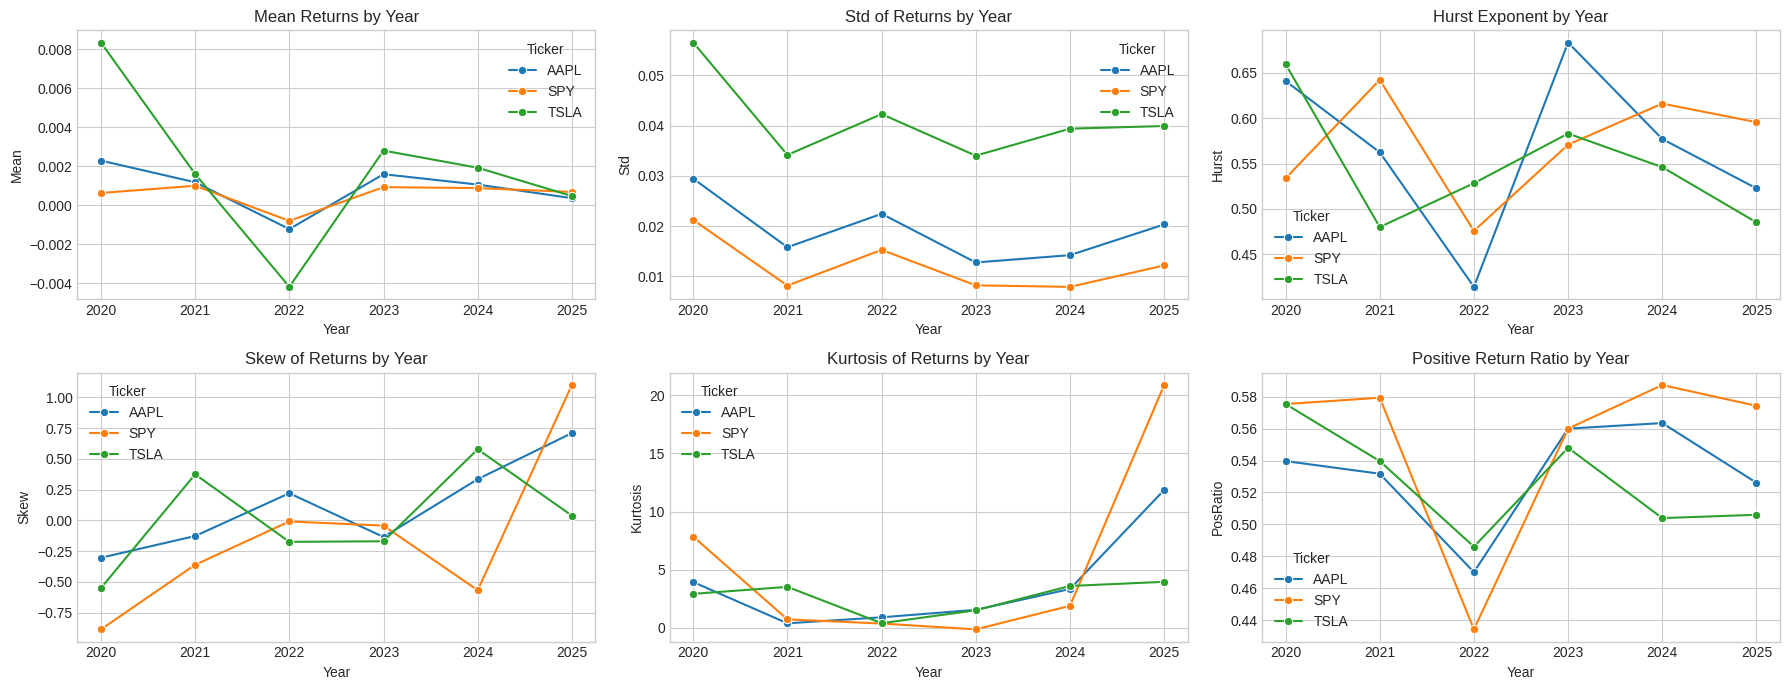

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12,6)})

# Line plots for mean, std, and Hurst exponent
fig, axes = plt.subplots(2, 3, figsize=(18,7))
sns.lineplot(data=stats_df, x='Year', y='Mean', hue='Ticker', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Mean Returns by Year')
sns.lineplot(data=stats_df, x='Year', y='Std', hue='Ticker', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Std of Returns by Year')
sns.lineplot(data=stats_df, x='Year', y='Hurst', hue='Ticker', marker='o', ax=axes[0, 2])
axes[0, 2].set_title('Hurst Exponent by Year')

sns.lineplot(data=stats_df, x='Year', y='Skew', hue='Ticker', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Skew of Returns by Year')
sns.lineplot(data=stats_df, x='Year', y='Kurtosis', hue='Ticker', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Kurtosis of Returns by Year')
sns.lineplot(data=stats_df, x='Year', y='PosRatio', hue='Ticker', marker='o', ax=axes[1, 2])
axes[1, 2].set_title('Positive Return Ratio by Year')

plt.tight_layout()
plt.show()

**Figure analysis.**

The six panels reinforce the table-level observations.

- Mean returns fluctuate around zero and change sign across years.
- The standard-deviation panel clearly separates TSLA from SPY, with AAPL in between.
- Hurst estimates move both above and below 0.5, and the ordering of the assets changes over time. This supports using several window lengths rather than assuming one fixed persistence scale.
- Skewness and kurtosis are not stable across years; the return distribution changes shape over the sample.
- The positive-return ratio remains close enough to 0.5 that a trivial always-positive classifier should not be assumed to solve the later forecasting task.

The figure therefore provides descriptive motivation for the multi-asset and multi-scale design, but it is not used to claim forecastability.


### Return-distribution boxplots

The boxplots provide a more direct view of dispersion and outliers than the yearly summary lines.


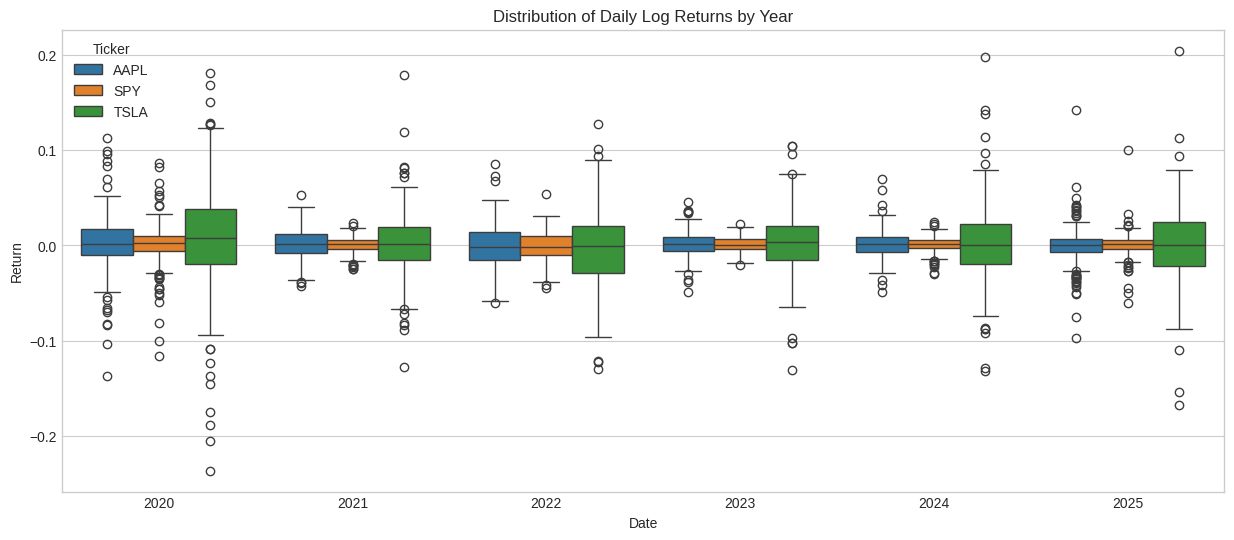

In [9]:
# Boxplots of yearly return distributions
plt.figure(figsize=(15,6))
sns.boxplot(data=log_returns_df.stack().reset_index(name='Return'),
            x=log_returns_df.stack().index.get_level_values(0).year,
            y='Return', hue=log_returns_df.stack().index.get_level_values(1))
plt.title('Distribution of Daily Log Returns by Year')
plt.show()

**Figure analysis.**

SPY has the narrowest central distribution, AAPL is wider, and TSLA shows the broadest spread and the most pronounced extreme observations. The centre of each distribution remains close to zero.

This confirms that the assets differ strongly in raw return magnitude. Because the principal Hopfield representation later keeps only the sign, these distributional differences should be interpreted as properties of the original data rather than direct predictors of Hopfield performance.

### Section 1 summary

The data contain meaningful cross-asset and temporal heterogeneity, while the sign balance remains reasonably close to 50/50. Hurst estimates are unstable across years, so temporal scale is investigated empirically rather than fixed from a single descriptive statistic.


# 2. Classical Hopfield network and implementation validation

## 2.1. Network definition

The implementation follows the classical bipolar Hopfield model. For stored patterns $\xi^\mu \in \{-1,+1\}^N$, the Hebbian weights are

$$
W = \sum_{\mu=1}^{P}\xi^\mu(\xi^\mu)^T,
$$

with a zero diagonal.

Neurons are updated asynchronously. A network state is considered stable when a complete sweep changes no bits. The energy used for diagnostics is

$$
E(\mathbf{s})=-\frac{1}{2}\mathbf{s}^T W\mathbf{s}.
$$

The usual positive normalization factor $1/N$ is omitted because, with zero thresholds, it scales every local field by the same positive constant and therefore does not change the sign-based update decisions.


In [10]:
class HopfieldNetwork:
    def __init__(self, n_neurons):
        """
        Initialize the network.
        Arguments:
            n_neurons (int): Pattern dimension (window length L)
        """
        self.n = n_neurons
        self.W = np.zeros((n_neurons, n_neurons))

    def train(self, patterns):
        """
        Train using the Hebbian rule: W = Σ(x_i · x_i^T)
        Arguments:
            patterns (np.array): Pattern matrix with shape (P, N)
        """
        # Store patterns in associative memory
        # Vectorized sum of outer products
        self.W = patterns.T @ patterns # Build the weight matrix from bipolar patterns; the weights represent the memory.
        np.fill_diagonal(self.W, 0) # Zero the diagonal: w_ii = 0 (no self-connections)
        # Explicit symmetry check; classical Lyapunov arguments require symmetric weights.
        if not np.allclose(self.W, self.W.T, atol=1e-9):
            raise RuntimeError("Weight matrix is not symmetric.")

    def energy(self, state):
        """
        Lyapunov energy E = -0.5 * s^T W s is valid here for symmetric weights, w_{ii}=0, and zero thresholds.
        With non-zero thresholds \theta_i, the energy would include an additional term.
        Expanded form: E(s)= -0.5 Σ_{i,j} w_ij * s_i * s_j - Σ_i I_i * s_i + Σ_i theta_i * s_i.
        Under asynchronous deterministic updates, the energy should not increase.
        """
        return -0.5 * np.dot(state, np.dot(self.W, state))

    def run(self, initial_state, max_sweeps=20):
        """
        Run asynchronous dynamics until a stable state is reached.
        One sweep updates all neurons sequentially in a random order.
        Stop when a full sweep produces no state changes (convergence).

        Arguments:
            initial_state (np.array): Corrupted input vector
            max_sweeps (int): Maximum number of complete network sweeps

        Returns:
            restored_state (np.array): Stable network state
        """
        state = initial_state.copy().astype(float)
        n = self.n

        for _ in range(max_sweeps):
            old_state = state.copy()
            # Random neuron order within each sweep. Updates are asynchronous: each new state is used immediately by subsequent updates.
            indices = np.random.permutation(n)

            for idx in indices:
                # Local field h_i = Σ_j w_ij * s_j
                local_field = np.dot(self.W[idx], state) # Neuron i combines the states of the other neurons weighted by their connections.

                # Threshold activation (sign).
                # Positive local field sets +1, negative sets -1; at local_field == 0 the state is unchanged.
                if local_field > 0:
                    state[idx] = 1.0
                elif local_field < 0:
                    state[idx] = -1.0

            # Convergence check: if no neuron changes during a sweep, the state is stable.
            if np.array_equal(state, old_state):
                break

        return state

print("HopfieldNetwork class defined. Implements Hebbian learning, async dynamics, and Lyapunov energy.")
# print("HopfieldNetwork class updated. Implements sweep-based async dynamics with convergence check.")

HopfieldNetwork class defined. Implements Hebbian learning, async dynamics, and Lyapunov energy.


### Noise helper

The following helper flips a requested fraction of bits and is used in the initial implementation check.


In [11]:
def inject_noise(pattern, noise_level):
    noisy = pattern.copy()
    n_flips = int(noise_level * len(pattern))
    flip_indices = np.random.choice(len(pattern), size=n_flips, replace=False)
    noisy[flip_indices] *= -1
    return noisy

## 2.2. Synthetic sanity check

Before using market data, the implementation is tested on a small controlled set of bipolar patterns. The test checks:

- symmetric zero-diagonal weights;
- recovery of a one-bit corruption;
- convergence to a stable state;
- non-increasing energy.

This is a technical validation of the implementation, not an experimental result about financial data.


In [12]:
# Patterns used for the sanity check
toy_patterns = np.array([
    [ 1,  1,  1,  1, -1, -1, -1, -1],
    [ 1, -1,  1, -1,  1, -1,  1, -1]
])

net = HopfieldNetwork(n_neurons=8)
net.train(toy_patterns)


# 2. Check structural properties
is_symmetric = np.allclose(net.W, net.W.T)
is_diag_zero = np.all(np.diag(net.W) == 0)
print(f"Weight matrix symmetric: {is_symmetric}")
print(f"Diagonal elements zero: {is_diag_zero}")


# 3. Corrupt one of eight bits (12.5% noise)
# Do not assume a universal theoretical attraction radius for this toy example.
original_pattern = toy_patterns[0]
noisy_pattern = inject_noise(original_pattern, 0.125)
# 4. Run dynamics until convergence
restored_pattern = net.run(noisy_pattern, max_sweeps=20)
print("Original:", original_pattern)
print("Noisy   :", noisy_pattern)
print("Restored:", restored_pattern.astype(int))



# 5. Functional checks
is_recovered = np.array_equal(original_pattern, restored_pattern)
e_noisy = net.energy(noisy_pattern)
e_restored = net.energy(restored_pattern)
energy_decreased = e_restored <= e_noisy + 1e-9

print(f"Pattern fully recovered: {is_recovered}")
print(f"Energy decreased (Noisy={e_noisy:.2f} -> Restored={e_restored:.2f}): {energy_decreased}")

# 6. Final verdict
if is_recovered and energy_decreased and is_symmetric and is_diag_zero:
    print("\nSUCCESS! Basic Hopfield implementation sanity check PASSED.")  # This technical check is not a formal proof of correctness for every configuration
else:
    raise AssertionError("FAILURE! Sanity check FAILED.")

Weight matrix symmetric: True
Diagonal elements zero: True
Original: [ 1  1  1  1 -1 -1 -1 -1]
Noisy   : [ 1 -1  1  1 -1 -1 -1 -1]
Restored: [ 1  1  1  1 -1 -1 -1 -1]
Pattern fully recovered: True
Energy decreased (Noisy=-12.00 -> Restored=-24.00): True

SUCCESS! Basic Hopfield implementation sanity check PASSED.


**Validation result.** The toy example passes all checks: the corrupted reference pattern is recovered, the final state is stable, and the network energy decreases from the initial corrupted state to the final state.

This establishes that the basic weight construction, asynchronous update rule, convergence criterion, and energy calculation behave as expected before the financial experiments begin.

### Section 2 summary

The classical Hopfield implementation is technically functional. Negative results on financial data therefore cannot be attributed simply to a network that fails to perform basic stored-pattern recall in a controlled setting.


# 3. Stored-pattern recall control experiment

This section asks the simplest question first: **can the network recover corrupted versions of financial patterns that were explicitly stored in its memory?**

This is a control experiment. It validates associative recall on financial windows but does not test generalization to future or unseen windows.

## 3.1. Experimental settings and helper functions

The control experiment uses temporal windows

$$
L \in \{10,30,50,70,100,200\}
$$

and requested noise levels from 5% to 40%.

The initial memory-size rule uses approximately $0.14N$ stored patterns as a classical reference condition. This value is not treated as a universal capacity for correlated financial windows; memory load is varied explicitly in the next section.


In [13]:
# =========================================================
# BLOCK 3.0: Experimental settings and helper functions
# =========================================================

WINDOWS = [10, 30, 50, 70, 100, 200]

# Main noise range for the stored-pattern control experiment.
NOISE_LEVELS_MAIN = np.arange(0.05, 0.41, 0.05).tolist()

# N_TEST = 200
CAPACITY_COEF = 0.14

rng = np.random.default_rng(42)


def extract_sliding_windows(series_1d, window_length):
    """
    Converts a one-dimensional binary time series into overlapping windows.
    Each window is one binary pattern for the Hopfield network.
    """
    n_samples = len(series_1d)
    n_windows = n_samples - window_length + 1

    if n_windows <= 0:
        raise ValueError("Window length exceeds series length.")

    return np.array([
        series_1d[i:i + window_length]
        for i in range(n_windows)
    ])


def hopfield_capacity(window_length, coef=CAPACITY_COEF):
    """
    0.14*N is used here only as a classical reference condition.
    The value near 0.138*N applies to large networks with random
    uncorrelated patterns and is not treated as a universal capacity
    for correlated financial windows.
    The next experiment varies the number of stored patterns explicitly.
    """
    return max(1, int(np.floor(coef * window_length)))


def select_memory_patterns(train_patterns, memory_size):
    """
    Selects memory patterns from the training part.

    Important:
    We do not use random sampling here because the data are temporal.
    We also do not simply take the first memory_size adjacent windows, because
    adjacent sliding windows are almost identical.

    Instead, we take evenly spaced historical patterns from the train interval.
    This keeps temporal order and gives the memory a broader historical coverage.
    """
    n_train = len(train_patterns)

    if memory_size > n_train:
        raise ValueError("memory_size exceeds number of training patterns.")

    if memory_size == 1:
        return train_patterns[[0]]

    indices = np.linspace(0, n_train - 1, memory_size, dtype=int)
    return train_patterns[indices]


def inject_noise_controlled(pattern, requested_noise, rng):
    """
    Adds controlled binary noise by flipping a fixed number of bits.

    Because window length is discrete, actual noise can differ from requested noise.
    For example, 5% noise in a 10-bit window cannot be represented exactly.
    Therefore the function returns both the noisy pattern and the actual noise level.
    """
    noisy = pattern.copy()
    n_bits = len(pattern)

    n_flips = int(np.round(requested_noise * n_bits))
    if requested_noise > 0:
        n_flips = max(1, n_flips)
    n_flips = min(n_flips, n_bits)

    flip_indices = rng.choice(n_bits, size=n_flips, replace=False)
    noisy[flip_indices] *= -1

    actual_noise = n_flips / n_bits
    return noisy, actual_noise


def accuracy(original, candidate):
    """
    Share of matching bits between original and candidate pattern.
    """
    return np.mean(original == candidate)


def hamming_distance(original, candidate):
    """
    Number of mismatching bits between original and candidate pattern.
    """
    return np.sum(original != candidate)


### Pattern formation and configuration check

Sliding windows are formed for every asset and window length. At this stage the 80/20 split is used only to define a historical pool for the stored-pattern control. The later unseen experiments use a stricter temporal split performed on the raw series **before** window extraction.


In [14]:
# =========================================================
# BLOCK 3.1: Pattern formation and train/test consistency check
# =========================================================

data_store = {}
split_info = []

for ticker in TICKERS:
    series_1d = binary_df[ticker].values

    for w in WINDOWS:
        windows_matrix = extract_sliding_windows(series_1d, window_length=w)
        data_store[(ticker, w)] = windows_matrix

        n_total = len(windows_matrix)
        # n_train = n_total - N_TEST
        # n_test = N_TEST
        n_train = int(n_total * 0.8)
        n_test = n_total - n_train
        # train = windows_matrix[:n_train]
        # test = windows_matrix[n_train:]
        capacity = hopfield_capacity(w)


        if n_train <= 0:
            raise ValueError(f"Not enough patterns for ticker={ticker}, window={w}")

        split_info.append({
            "ticker": ticker,
            "window": w,
            "total_patterns": n_total,
            "train_patterns": n_train,
            "test_patterns": n_test,
            "hopfield_capacity": capacity
        })

split_info_df = pd.DataFrame(split_info)
split_info_df

,ticker,window,total_patterns,train_patterns,test_patterns,hopfield_capacity
0,SPY,10,1497,1197,300,1
1,SPY,30,1477,1181,296,4
2,SPY,50,1457,1165,292,7
3,SPY,70,1437,1149,288,9
4,SPY,100,1407,1125,282,14
5,SPY,200,1307,1045,262,28
6,AAPL,10,1497,1197,300,1
7,AAPL,30,1477,1181,296,4
8,AAPL,50,1457,1165,292,7
9,AAPL,70,1437,1149,288,9


**Table analysis.** Increasing the window length changes two quantities at the same time:

- the number of neurons $N$;
- the number of stored patterns under the initial $0.14N$ rule.

For $L=10$, the reference memory contains only one pattern, while $L=200$ stores 28 patterns. Therefore, apparent differences between window lengths in this first control cannot be interpreted as a pure effect of temporal scale. This motivates the explicit memory-load experiment in Section 4.1.


## 3.2. Recall of corrupted stored patterns

The experiment follows the sequence

$$
\text{historical windows}
\rightarrow
\text{memory selection}
\rightarrow
\text{Hopfield training}
\rightarrow
\text{corruption of a stored pattern}
\rightarrow
\text{recall}.
$$

Each stored pattern is corrupted repeatedly at every requested noise level. The main metrics are bitwise accuracy and Hamming distance before and after Hopfield dynamics.


In [15]:
# =========================================================
# BLOCK 3.2: Stored-pattern recall control experiment
# =========================================================
# This block is explicitly treated as a classical recall control.
# Test whether the network can recover corrupted versions of patterns
# that were explicitly stored in memory. This is not unseen reconstruction.

results_recovery_main = []

N_REPEATS_PER_PATTERN = 20  # repeated noise trials for stability

for ticker in TICKERS:
    for w in WINDOWS:

        all_patterns = data_store[(ticker, w)]

        n_total = len(all_patterns)
        n_train = int(n_total * 0.8)
        train_pool = all_patterns[:n_train]

        memory_size = hopfield_capacity(w)
        memory_patterns = select_memory_patterns(train_pool, memory_size)

        net = HopfieldNetwork(n_neurons=w)
        net.train(memory_patterns)

        for requested_noise in NOISE_LEVELS_MAIN:
            for pattern_id, original_pattern in enumerate(memory_patterns):
                acc_noisy_list = []
                acc_restored_list = []

                hamming_noisy_list = []
                hamming_restored_list = []
                actual_noise_list = []

                for _ in range(N_REPEATS_PER_PATTERN):
                    noisy_p, actual_noise = inject_noise_controlled(
                        pattern=original_pattern,
                        requested_noise=requested_noise,
                        rng=rng
                    )

                    restored_p = net.run(noisy_p, max_sweeps=20)

                    acc_noisy_list.append(accuracy(original_pattern, noisy_p))
                    acc_restored_list.append(accuracy(original_pattern, restored_p))

                    hamming_noisy_list.append(hamming_distance(original_pattern, noisy_p))
                    hamming_restored_list.append(hamming_distance(original_pattern, restored_p))

                    actual_noise_list.append(actual_noise)

                acc_noisy_mean = np.mean(acc_noisy_list)
                acc_restored_mean = np.mean(acc_restored_list)

                hamming_noisy_mean = np.mean(hamming_noisy_list)
                hamming_restored_mean = np.mean(hamming_restored_list)

                results_recovery_main.append({
                    "ticker": ticker,
                    "window": w,
                    "memory_size": memory_size,
                    "pattern_id": pattern_id,
                    "requested_noise": requested_noise,
                    "actual_noise": np.mean(actual_noise_list),
                    "acc_noisy": acc_noisy_mean,
                    "acc_restored": acc_restored_mean,
                    "delta_acc": acc_restored_mean - acc_noisy_mean,
                    "hamming_noisy": hamming_noisy_mean,
                    "hamming_restored": hamming_restored_mean,
                    "delta_hamming": hamming_noisy_mean - hamming_restored_mean
                })

df_recovery_main = pd.DataFrame(results_recovery_main)
df_recovery_main

,ticker,window,memory_size,pattern_id,requested_noise,actual_noise,acc_noisy,acc_restored,delta_acc,hamming_noisy,hamming_restored,delta_hamming
0,SPY,10,1,0,0.05,0.1,0.9,1.00000,0.10000,1.0,0.00,1.00
1,SPY,10,1,0,0.10,0.1,0.9,1.00000,0.10000,1.0,0.00,1.00
2,SPY,10,1,0,0.15,0.2,0.8,1.00000,0.20000,2.0,0.00,2.00
3,SPY,10,1,0,0.20,0.2,0.8,1.00000,0.20000,2.0,0.00,2.00
4,SPY,10,1,0,0.25,0.2,0.8,1.00000,0.20000,2.0,0.00,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...
1507,TSLA,200,28,23,0.40,0.4,0.6,0.70475,0.10475,80.0,59.05,20.95
1508,TSLA,200,28,24,0.40,0.4,0.6,0.65275,0.05275,80.0,69.45,10.55
1509,TSLA,200,28,25,0.40,0.4,0.6,0.59350,-0.00650,80.0,81.30,-1.30
1510,TSLA,200,28,26,0.40,0.4,0.6,0.61375,0.01375,80.0,77.25,2.75


### Aggregated recall table

The raw repeated trials are aggregated by asset, window length, and noise level. This table is useful for checking exact numerical values, while the following figures make the trends easier to interpret.


In [16]:
# =========================================================
# BLOCK 3.3: Recovery summary table
# =========================================================

recovery_summary = (
    df_recovery_main
    .groupby(["ticker", "window", "memory_size"], as_index=False)
    .agg(
        mean_actual_noise=("actual_noise", "mean"),
        mean_acc_noisy=("acc_noisy", "mean"),
        mean_acc_restored=("acc_restored", "mean"),
        mean_delta_acc=("delta_acc", "mean"),
        mean_hamming_noisy=("hamming_noisy", "mean"),
        mean_hamming_restored=("hamming_restored", "mean"),
        mean_delta_hamming=("delta_hamming", "mean")
    )
)

recovery_summary

,ticker,window,memory_size,mean_actual_noise,mean_acc_noisy,mean_acc_restored,mean_delta_acc,mean_hamming_noisy,mean_hamming_restored,mean_delta_hamming
0,AAPL,10,1,0.237500,0.762500,1.000000,0.237500,2.375,0.000000,2.375000
1,AAPL,30,4,0.233333,0.766667,0.926406,0.159740,7.000,2.207813,4.792187
2,AAPL,50,7,0.225000,0.775000,0.902929,0.127929,11.250,4.853571,6.396429
3,AAPL,70,9,0.228571,0.771429,0.870575,0.099147,16.000,9.059722,6.940278
4,AAPL,100,14,0.225000,0.775000,0.875799,0.100799,22.500,12.420089,10.079911
5,AAPL,200,28,0.225000,0.775000,0.846742,0.071742,45.000,30.651563,14.348438
6,SPY,10,1,0.237500,0.762500,1.000000,0.237500,2.375,0.000000,2.375000
7,SPY,30,4,0.233333,0.766667,0.922396,0.155729,7.000,2.328125,4.671875
8,SPY,50,7,0.225000,0.775000,0.885321,0.110321,11.250,5.733929,5.516071
9,SPY,70,9,0.228571,0.771429,0.884742,0.113313,16.000,8.068056,7.931944


**Table analysis.** The network usually improves corrupted stored patterns, but the effect is far from uniform. Short, lightly loaded networks can recover almost perfectly, whereas long windows and strong corruption often leave substantial residual error. Because memory size still grows with the window length in this control, these results are descriptive rather than a clean scale comparison.


### Accuracy before and after recall


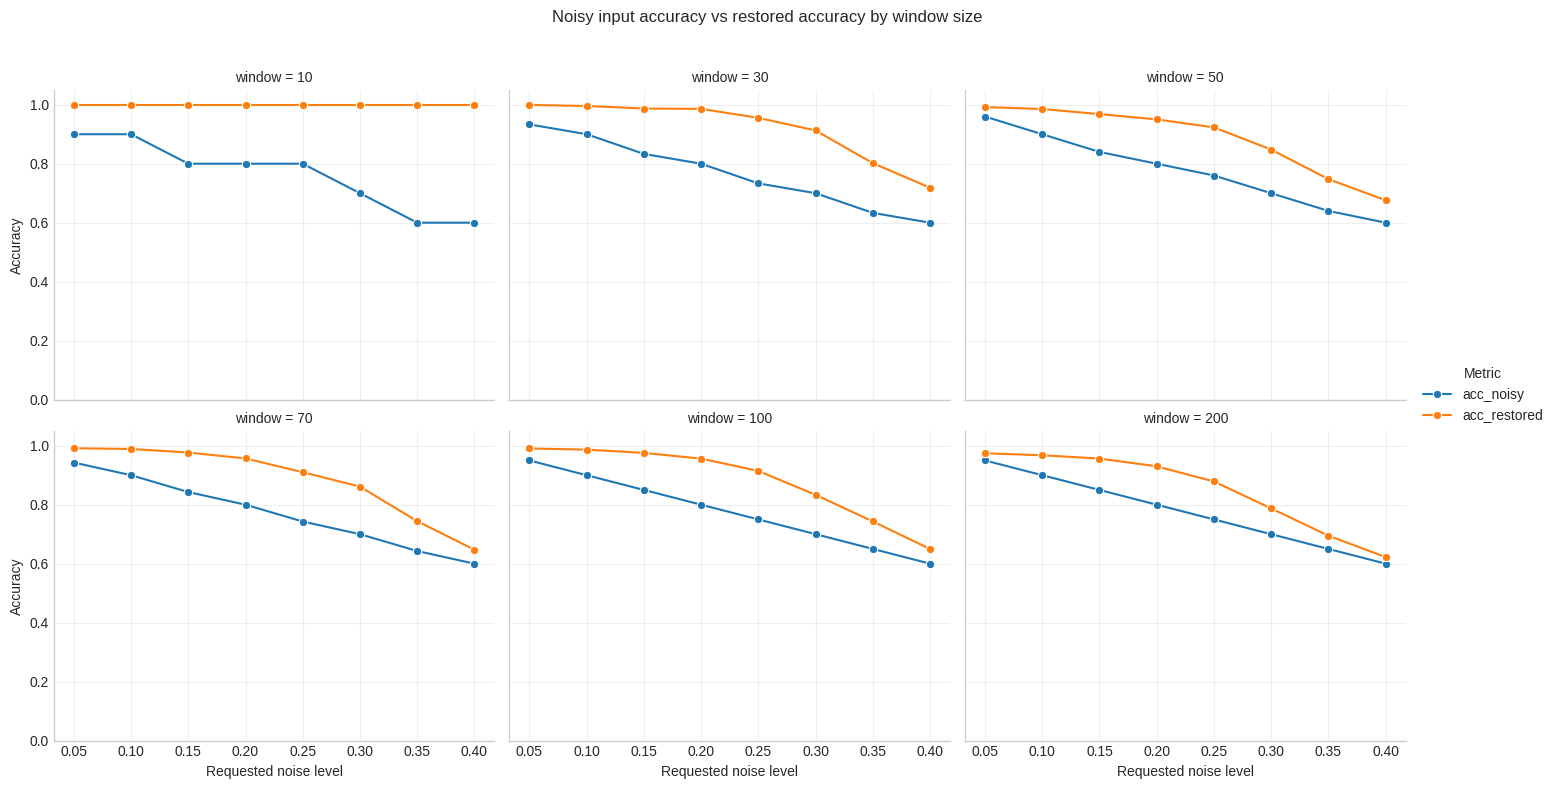

In [17]:
# =========================================================
# BLOCK 3.4: Noisy vs restored accuracy
# =========================================================

acc_compare = (
    df_recovery_main
    .groupby(["window", "requested_noise"], as_index=False)
    .agg(
        acc_noisy=("acc_noisy", "mean"),
        acc_restored=("acc_restored", "mean"),
        actual_noise=("actual_noise", "mean")
    )
)

acc_compare_long = acc_compare.melt(
    id_vars=["window", "requested_noise", "actual_noise"],
    value_vars=["acc_noisy", "acc_restored"],
    var_name="metric",
    value_name="accuracy"
)

g = sns.FacetGrid(
    acc_compare_long,
    col="window",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="requested_noise",
    y="accuracy",
    hue="metric",
    marker="o"
)

g.add_legend(title="Metric")

for ax in g.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Requested noise level")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)

plt.subplots_adjust(top=0.88)
g.fig.suptitle("Noisy input accuracy vs restored accuracy by window size")
plt.show()

**Figure analysis.**

The restored accuracy is consistently above the noisy-input accuracy in the easiest configurations, confirming genuine associative recall. The effect weakens as corruption grows.

The $L=10$ case appears nearly perfect, but it must be interpreted together with the configuration table: only one pattern is stored under the initial reference rule, so this is a much easier memory problem than $L=100$ or $L=200$.

For intermediate windows, recall remains useful at low and moderate corruption but degrades at 35–40% noise. The figure therefore confirms that the implementation can correct errors in stored financial patterns while also showing that recall has a limited basin of attraction.


### Effect of window length


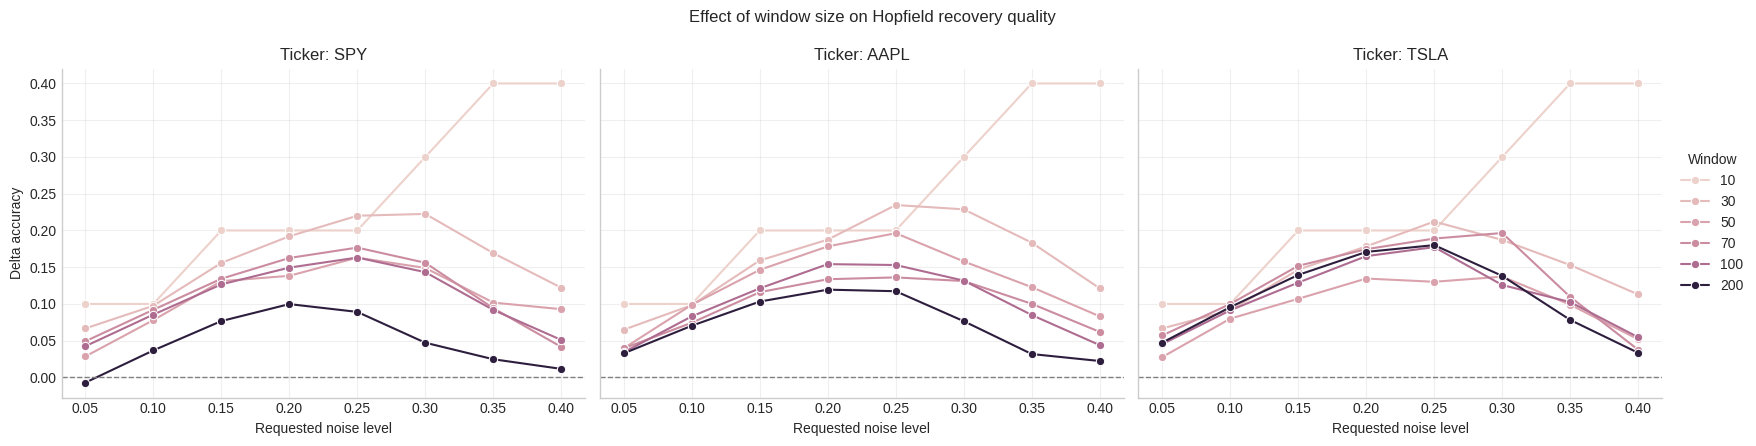

In [18]:
# =========================================================
# BLOCK 3.5: Effect of window size on recovery quality
# =========================================================

g = sns.FacetGrid(
    df_recovery_main,
    col="ticker",
    height=4.5,
    aspect=1.25,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="requested_noise",
    y="delta_acc",
    hue="window",
    marker="o",
    errorbar=None # no uncertainty bands around the lines
)

g.add_legend(title="Window")

for ax in g.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Requested noise level")
    ax.set_ylabel("Delta accuracy")
    ax.grid(True, alpha=0.3)
    ax.set_title(ax.get_title().replace("ticker = ", "Ticker: "))

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Effect of window size on Hopfield recovery quality")
plt.show()

**Figure analysis.**

The mean improvement is not a simple monotonic function of window length. Short windows benefit from an extremely small memory, while longer windows simultaneously increase state dimension and the number of stored patterns.

At moderate noise, several intermediate windows show clear positive improvement. At high noise, the benefit declines for most configurations. The long-window results differ across assets, especially at $L=200$, which indicates that both memory load and the structure of the binary sequence matter.

This figure should therefore not be read as identifying an optimal window length; the confounding effect of memory load is addressed explicitly in Section 4.1.


### Effect of financial instrument


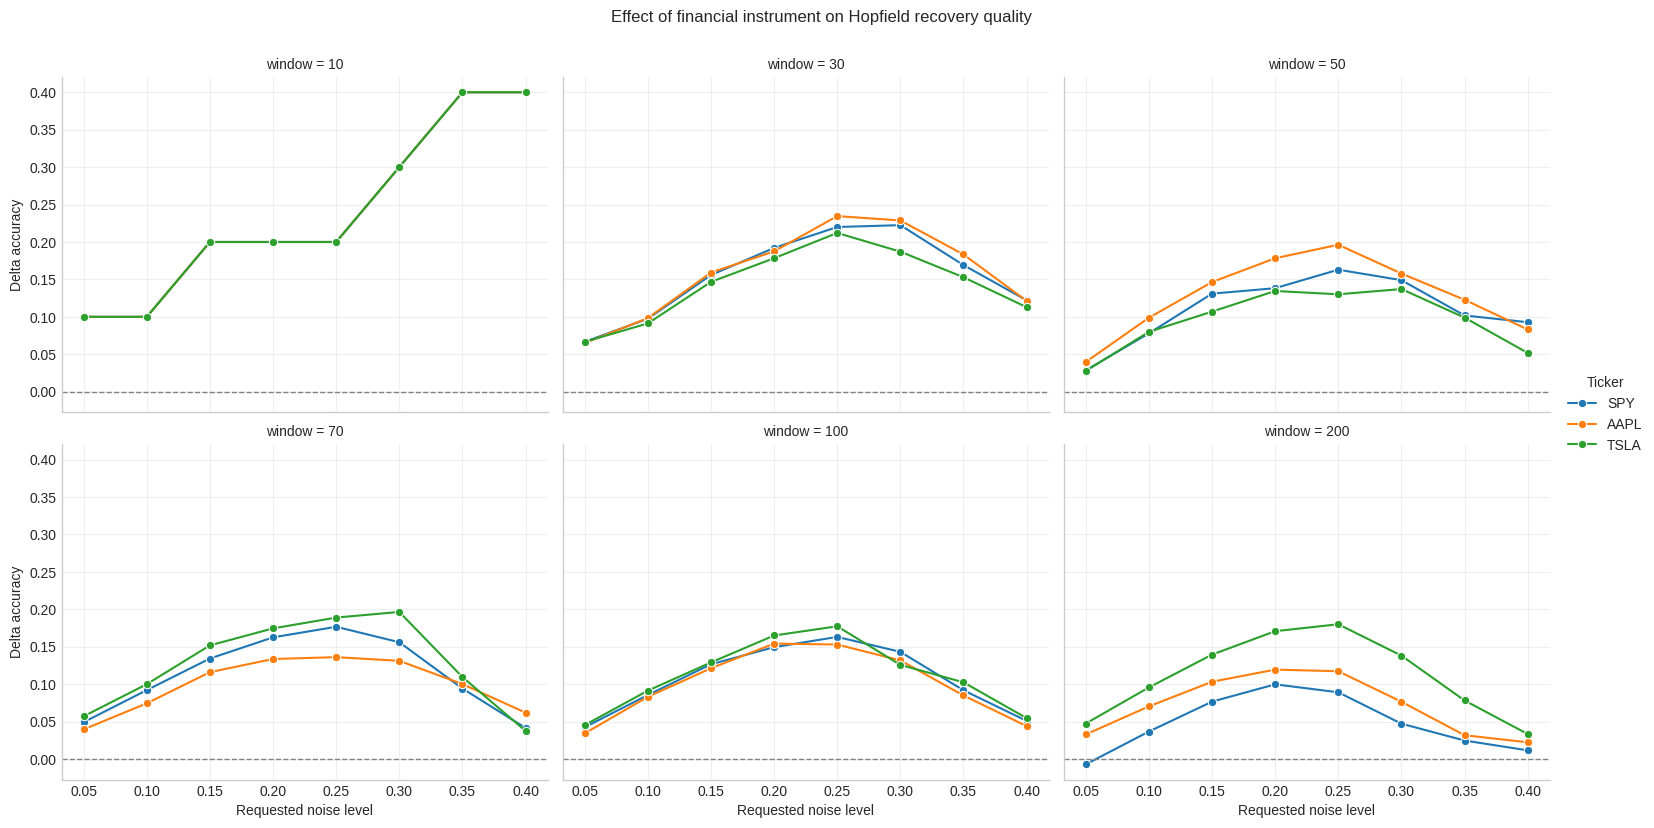

In [19]:
# =========================================================
# BLOCK 3.6: Effect of financial instrument on recovery quality
# =========================================================

g = sns.FacetGrid(
    df_recovery_main,
    col="window",
    col_wrap=3,
    height=4.2,
    aspect=1.25,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="requested_noise",
    y="delta_acc",
    hue="ticker",
    marker="o",
    errorbar=None
)

g.add_legend(title="Ticker")

for ax in g.axes.flat:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Requested noise level")
    ax.set_ylabel("Delta accuracy")
    ax.grid(True, alpha=0.3)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Effect of financial instrument on Hopfield recovery quality")
plt.show()

**Figure analysis.**

For most short and medium windows, SPY, AAPL, and TSLA follow broadly similar recall curves. The differences become more visible at large windows, especially at $L=200$.

Importantly, the most volatile asset in the original continuous data, TSLA, is not consistently the hardest to recall. In the $L=200$ control it can outperform SPY and AAPL. This is expected because sign-only Hopfield patterns contain the direction of returns, not their magnitude.

The result supports treating the temporal sign structure itself as the relevant object for the binary network.


### Heatmap of recall improvement


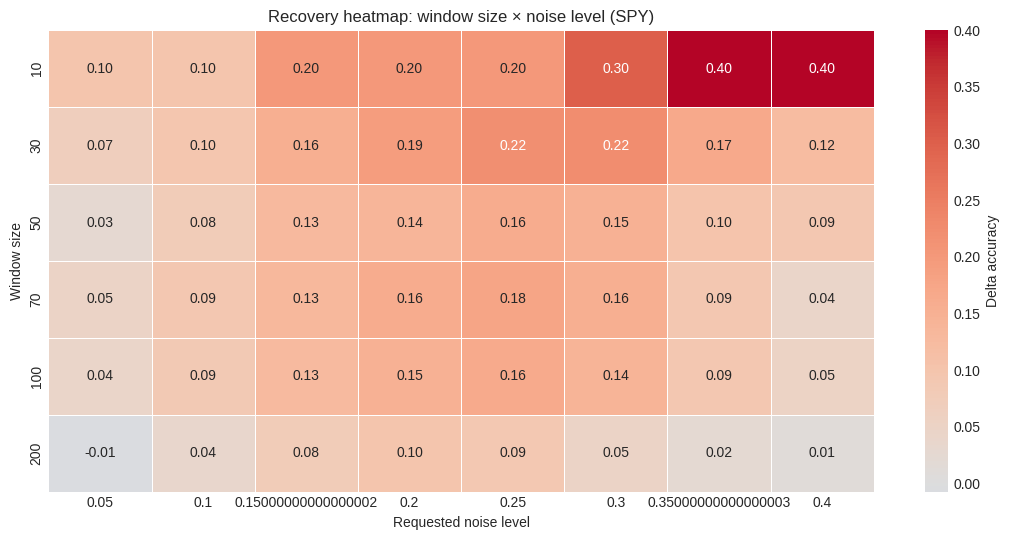

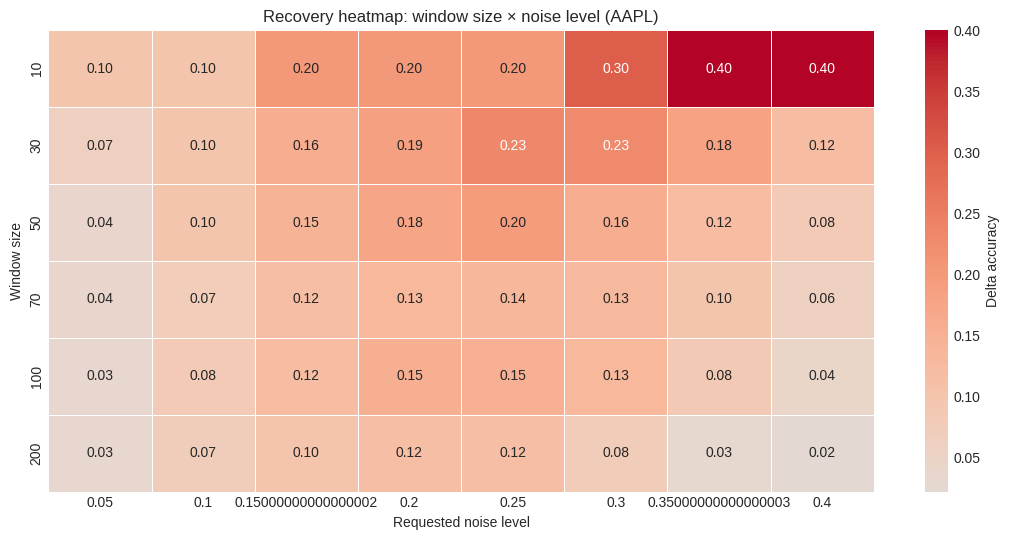

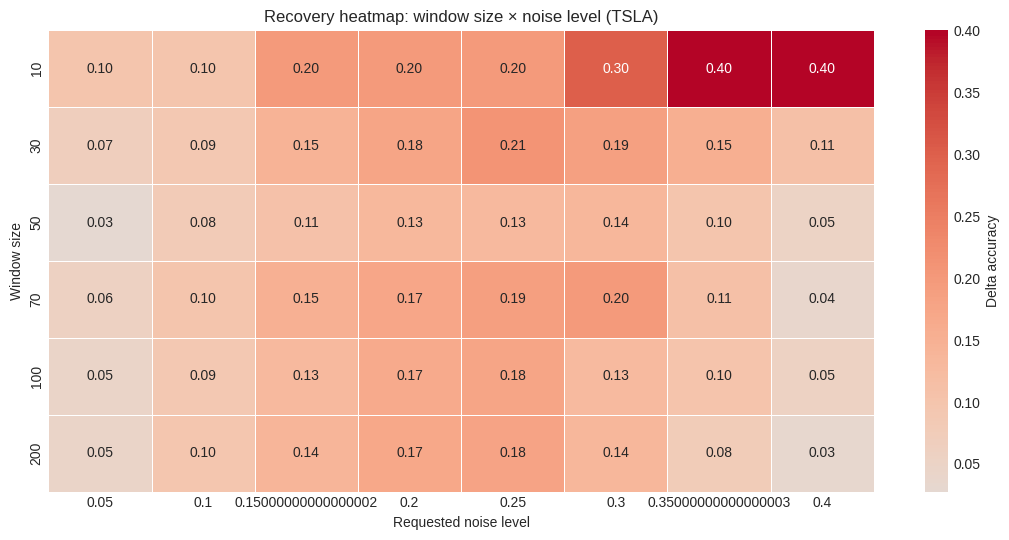

In [20]:
# =========================================================
# BLOCK 3.7: Heatmaps of recovery zones
# =========================================================

# for ticker in TICKERS:
#     heatmap_data = (
#         df_recovery_main[df_recovery_main["ticker"] == ticker]
#         .pivot(index="window", columns="requested_noise", values="delta_acc")
#         .sort_index()
#     )


for ticker in TICKERS:
    heatmap_data = (
        df_recovery_main[df_recovery_main["ticker"] == ticker]
        .pivot_table(
            index="window",
            columns="requested_noise",
            values="delta_acc",
            aggfunc="mean"
        )
        .sort_index()
    )


    plt.figure(figsize=(11, 5.5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Delta accuracy"}
    )

    plt.title(f"Recovery heatmap: window size × noise level ({ticker})")
    plt.xlabel("Requested noise level")
    plt.ylabel("Window size")
    plt.tight_layout()
    plt.show()

**Figure analysis.**

The heatmaps summarize where Hopfield dynamics improves the corrupted stored state.

- Low corruption naturally leaves little room for improvement.
- Moderate corruption, roughly 15–30%, often produces the largest positive gain in non-trivial configurations.
- At 35–40% corruption the benefit falls sharply for many windows.
- Some long-window configurations become nearly neutral or slightly harmful even though the target pattern was explicitly stored.

The heatmaps make the limited attraction region around stored patterns visible and reinforce the need to separate memory load from window length.


### Hamming distance before and after recall


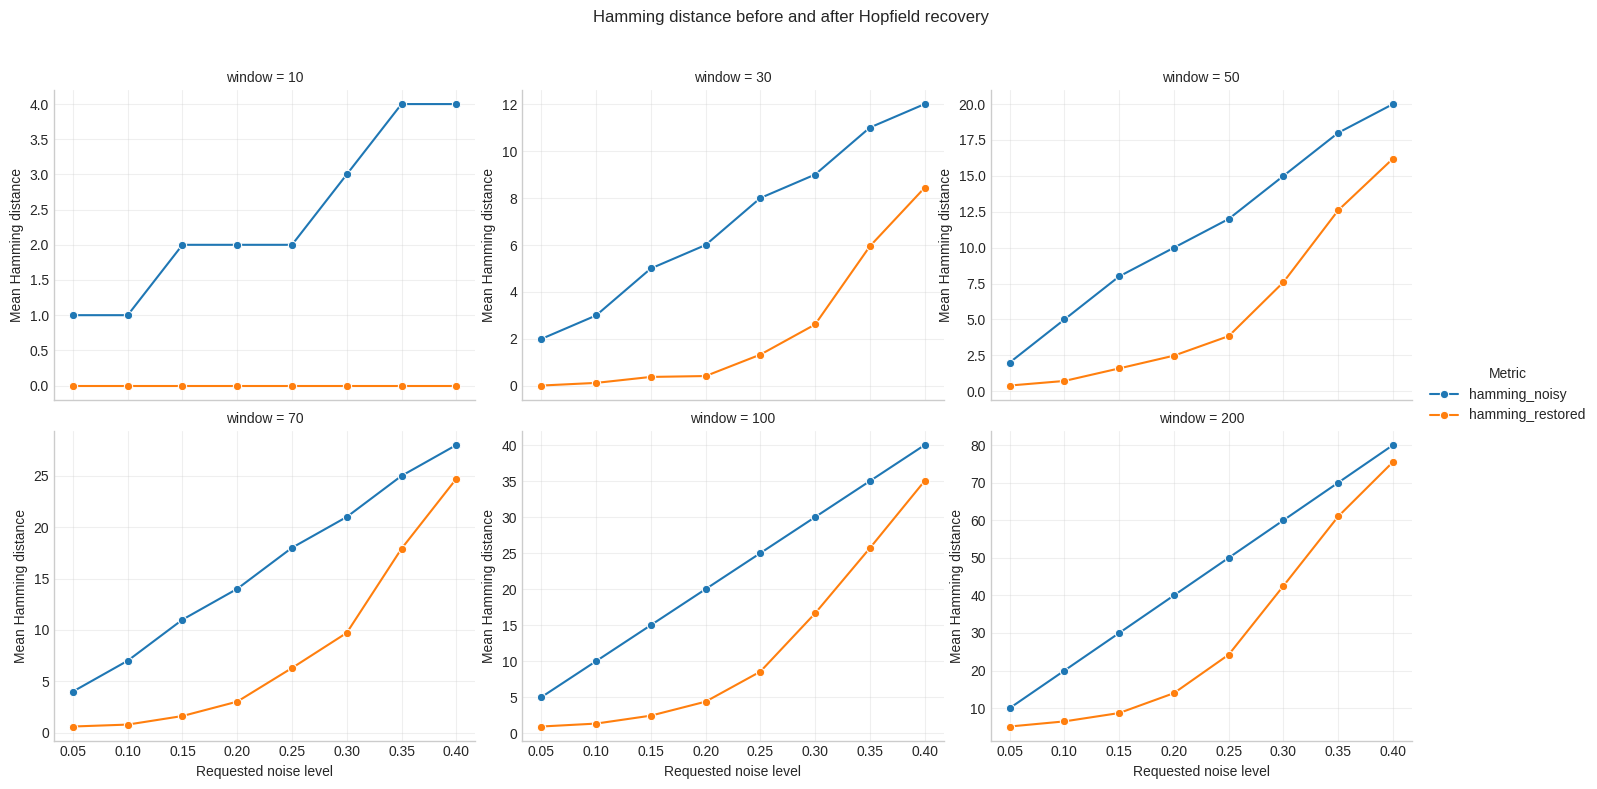

In [21]:
# =========================================================
# BLOCK 3.8: Hamming distance before and after recovery
# =========================================================

hamming_compare = (
    df_recovery_main
    .groupby(["window", "requested_noise"], as_index=False)
    .agg(
        hamming_noisy=("hamming_noisy", "mean"),
        hamming_restored=("hamming_restored", "mean")
    )
)

hamming_long = hamming_compare.melt(
    id_vars=["window", "requested_noise"],
    value_vars=["hamming_noisy", "hamming_restored"],
    var_name="metric",
    value_name="mean_hamming_distance"
)

g = sns.FacetGrid(
    hamming_long,
    col="window",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="requested_noise",
    y="mean_hamming_distance",
    hue="metric",
    marker="o"
)

g.add_legend(title="Metric")

for ax in g.axes.flat:
    ax.set_xlabel("Requested noise level")
    ax.set_ylabel("Mean Hamming distance")
    ax.grid(True, alpha=0.3)

plt.subplots_adjust(top=0.88)
g.fig.suptitle("Hamming distance before and after Hopfield recovery")
plt.show()

**Figure analysis.**

Hamming distance expresses the same reconstruction problem as a count of incorrect bits rather than a fraction.

For $L=10$, the final Hamming distance is effectively zero across the tested noise levels, again reflecting the trivial one-pattern memory. For $L=30$ to $L=100$, Hopfield removes many errors at low and moderate corruption, but the number of residual errors grows under stronger corruption.

For $L=200$ and 40% noise, as many as 80 bits are flipped initially. In weak configurations, most of those errors remain after the network runs. This view is useful because small changes in accuracy can correspond to many incorrect bits when the pattern is long.

### Section 3 summary

The classical network successfully performs its native task: **stored financial patterns can be recalled after corruption**. The result is strongest for low-complexity memories and moderate corruption. However, the first control mixes window length with the number of stored patterns. The next experiment therefore isolates memory load $\alpha=P/N$.


# 4. Unseen-pattern reconstruction and associative behaviour

The stored-pattern control establishes that the implementation can perform classical recall. The remaining reconstruction experiments ask a harder question: **can a network trained on historical windows be useful for financial fragments that were never stored?**

The analysis proceeds in stages:

1. isolate memory load as an experimental factor;
2. test whether clean unseen windows are stable;
3. measure movement toward stored historical memory;
4. test alternative representations;
5. compare uniform and prototype memory selection;
6. evaluate noisy unseen reconstruction directly.

## 4.1. Memory load as an independent factor

Memory load is defined as

$$
\alpha = \frac{P}{N},
$$

where $P$ is the number of stored patterns and $N$ is the number of neurons.

This experiment remains a stored-pattern recall test, but now the memory load is varied explicitly rather than tied to a single $0.14N$ reference rule.


In [22]:
# =========================================================
# BLOCK 4.1.1: Memory-load experiment settings
# =========================================================

ALPHA_LEVELS = [0.10, 0.20, 0.30, 0.50]
N_REPEATS_LOAD = 5

### Trial-level stored-pattern recall

Each repeat is stored as a separate result rather than being averaged immediately. This makes it possible to compute not only mean accuracy but also exact recovery rates and improvement frequencies.


In [23]:
# =========================================================
# BLOCK 4.1.2: Stored-pattern recall at different memory loads
# =========================================================

results_memory_load = []

for ticker in TICKERS:
    for w in WINDOWS:

        all_patterns = data_store[(ticker, w)]
        n_train = int(len(all_patterns) * 0.8)
        train_pool = all_patterns[:n_train]

        for alpha_requested in ALPHA_LEVELS:
            # Number of patterns corresponding to the requested load.
            memory_size = max(1, int(np.round(alpha_requested * w)))

            if memory_size > len(train_pool):
                continue
            # Actual load after rounding P to an integer.
            alpha_actual = memory_size / w

            memory_patterns = select_memory_patterns(train_pool, memory_size)

            net = HopfieldNetwork(n_neurons=w)
            net.train(memory_patterns)

            for requested_noise in NOISE_LEVELS_MAIN:
                for pattern_id, original_pattern in enumerate(memory_patterns):
                    for repeat_id in range(N_REPEATS_LOAD):
                        noisy_p, actual_noise = inject_noise_controlled(
                            pattern=original_pattern,
                            requested_noise=requested_noise,
                            rng=rng
                        )
                        restored_p = net.run(
                            noisy_p,
                            max_sweeps=20
                        )
                        acc_noisy = accuracy(
                            original_pattern,
                            noisy_p
                        )
                        acc_restored = accuracy(
                            original_pattern,
                            restored_p
                        )
                        hamming_noisy = hamming_distance(
                            original_pattern,
                            noisy_p
                        )
                        hamming_restored = hamming_distance(
                            original_pattern,
                            restored_p
                        )
                        results_memory_load.append({
                            "ticker": ticker,
                            "window": w,

                            "alpha_requested": alpha_requested,
                            "alpha_actual": alpha_actual,
                            "memory_size": memory_size,

                            "pattern_id": pattern_id,
                            "repeat_id": repeat_id,

                            "requested_noise": requested_noise,
                            "actual_noise": actual_noise,

                            "acc_noisy": acc_noisy,
                            "acc_restored": acc_restored,
                            "delta_acc": acc_restored - acc_noisy,

                            "hamming_noisy": hamming_noisy,
                            "hamming_restored": hamming_restored,
                            "delta_hamming": hamming_noisy - hamming_restored,

                            "improved": acc_restored > acc_noisy,
                            "exact_recovery": hamming_restored == 0
                        })

df_memory_load = pd.DataFrame(results_memory_load)
df_memory_load

,ticker,window,alpha_requested,alpha_actual,memory_size,pattern_id,repeat_id,requested_noise,actual_noise,acc_noisy,acc_restored,delta_acc,hamming_noisy,hamming_restored,delta_hamming,improved,exact_recovery
0,SPY,10,0.1,0.1,1,0,0,0.05,0.1,0.9,1.000,0.100,1,0,1,True,True
1,SPY,10,0.1,0.1,1,0,1,0.05,0.1,0.9,1.000,0.100,1,0,1,True,True
2,SPY,10,0.1,0.1,1,0,2,0.05,0.1,0.9,1.000,0.100,1,0,1,True,True
3,SPY,10,0.1,0.1,1,0,3,0.05,0.1,0.9,1.000,0.100,1,0,1,True,True
4,SPY,10,0.1,0.1,1,0,4,0.05,0.1,0.9,1.000,0.100,1,0,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60715,TSLA,200,0.5,0.5,100,99,0,0.40,0.4,0.6,0.490,-0.110,80,102,-22,False,False
60716,TSLA,200,0.5,0.5,100,99,1,0.40,0.4,0.6,0.595,-0.005,80,81,-1,False,False
60717,TSLA,200,0.5,0.5,100,99,2,0.40,0.4,0.6,0.490,-0.110,80,102,-22,False,False
60718,TSLA,200,0.5,0.5,100,99,3,0.40,0.4,0.6,0.580,-0.020,80,84,-4,False,False


### Actual memory configurations


In [24]:
memory_load_config = (
    df_memory_load[
        [
            "window",
            "alpha_requested",
            "alpha_actual",
            "memory_size"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["window", "alpha_requested"]
    )
    .reset_index(drop=True)
)

memory_load_config

,window,alpha_requested,alpha_actual,memory_size
0,10,0.1,0.1,1
1,10,0.2,0.2,2
2,10,0.3,0.3,3
3,10,0.5,0.5,5
4,30,0.1,0.1,3
5,30,0.2,0.2,6
6,30,0.3,0.3,9
7,30,0.5,0.5,15
8,50,0.1,0.1,5
9,50,0.2,0.2,10


**Configuration check.** Because $P$ must be an integer, the realized load can differ slightly from the requested value. This is especially important for short windows, where several requested loads may collapse to the same integer memory size. The subsequent analysis therefore uses `alpha_actual` whenever configurations are compared.


### Aggregated recall by memory load and noise


In [25]:
# =========================================================
# BLOCK 4.1.4: Recovery results by memory load and noise
# =========================================================

load_noise_summary = (
    df_memory_load
    .groupby(
        ["ticker", "window", "alpha_actual", "requested_noise"],
        as_index=False
    )
    .agg(
        mean_actual_noise=("actual_noise", "mean"),
        mean_acc_noisy=("acc_noisy", "mean"),
        mean_acc_restored=("acc_restored", "mean"),
        mean_delta_acc=("delta_acc", "mean"),
        mean_hamming_noisy=("hamming_noisy", "mean"),
        mean_hamming_restored=("hamming_restored", "mean"),
        improvement_rate=("improved", "mean"),
        exact_recovery_rate=("exact_recovery", "mean")
    )
)

load_noise_summary


,ticker,window,alpha_actual,requested_noise,mean_actual_noise,mean_acc_noisy,mean_acc_restored,mean_delta_acc,mean_hamming_noisy,mean_hamming_restored,improvement_rate,exact_recovery_rate
0,AAPL,10,0.1,0.05,0.10,0.90,1.00000,0.10000,1.0,0.000,1.000,1.0
1,AAPL,10,0.1,0.10,0.10,0.90,1.00000,0.10000,1.0,0.000,1.000,1.0
2,AAPL,10,0.1,0.15,0.20,0.80,1.00000,0.20000,2.0,0.000,1.000,1.0
3,AAPL,10,0.1,0.20,0.20,0.80,1.00000,0.20000,2.0,0.000,1.000,1.0
4,AAPL,10,0.1,0.25,0.20,0.80,1.00000,0.20000,2.0,0.000,1.000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
571,TSLA,200,0.5,0.20,0.20,0.80,0.65941,-0.14059,40.0,68.118,0.000,0.0
572,TSLA,200,0.5,0.25,0.25,0.75,0.64325,-0.10675,50.0,71.350,0.038,0.0
573,TSLA,200,0.5,0.30,0.30,0.70,0.61544,-0.08456,60.0,76.912,0.072,0.0
574,TSLA,200,0.5,0.35,0.35,0.65,0.59011,-0.05989,70.0,81.978,0.178,0.0


**Table analysis.** Each row now represents a well-defined experimental condition: asset, window length, realized memory load, and requested corruption level. Repeated stored patterns and repeated corruptions are averaged only within that condition. This produces a compact view of 576 experimental conditions without mixing different noise or memory-load settings.


### Recall improvement across memory load and noise


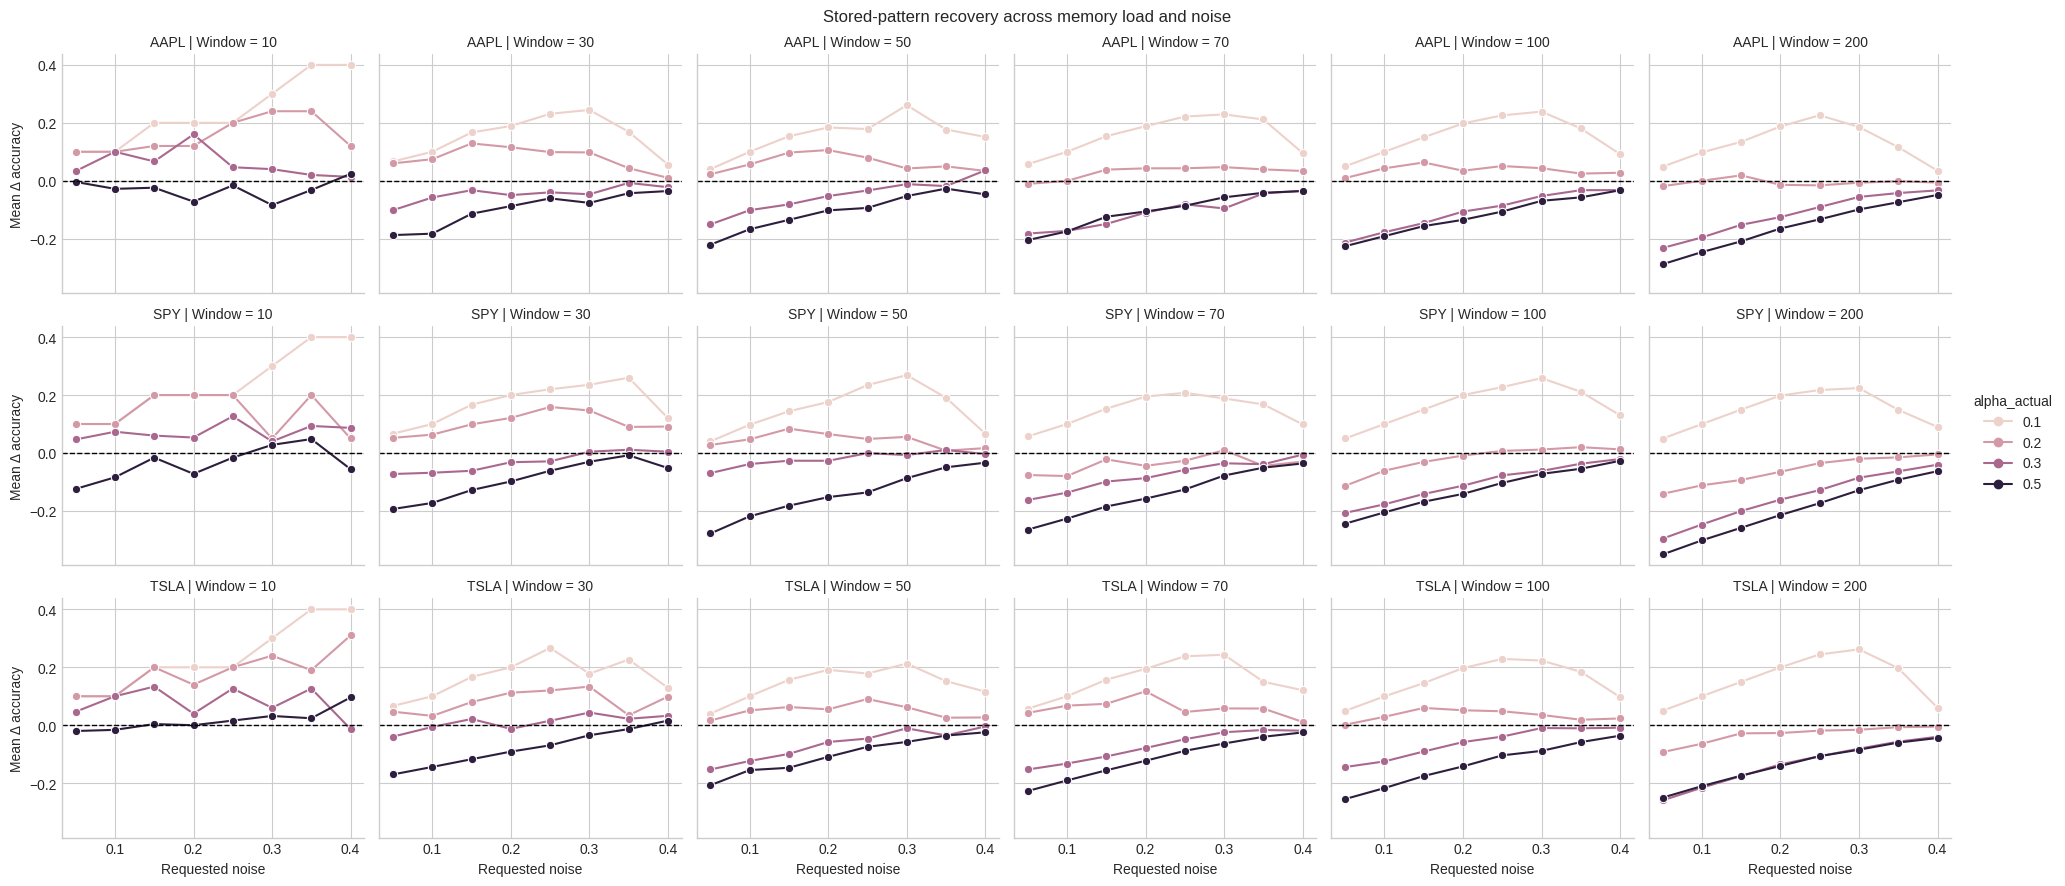

In [26]:
# =========================================================
# BLOCK 4.1.5: Effect of memory load across noise levels
# =========================================================

g = sns.relplot(
    data=load_noise_summary,
    x="requested_noise",
    y="mean_delta_acc",
    hue="alpha_actual",
    col="window",
    row="ticker",
    kind="line",
    marker="o",
    facet_kws={"sharey": True},
    height=3,
    aspect=1.1
)

g.set_axis_labels("Requested noise", "Mean Δ accuracy")
g.set_titles(
    row_template="{row_name}",
    col_template="Window = {col_name}"
)
for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
g.fig.subplots_adjust(top=0.93)
g.fig.suptitle("Stored-pattern recovery across memory load and noise")
plt.show()

**Figure analysis.**

Memory load has a strong and consistent effect.

- At $\alpha \approx 0.1$, recall is the most stable across all window lengths. Moderate corruption is often corrected effectively.
- At $\alpha \approx 0.2$, performance becomes more dependent on window length; short and medium windows can remain useful while long windows start to degrade.
- At $\alpha \approx 0.3$ and $0.5$, many non-trivial configurations become weak or harmful. Overloaded networks can move even lightly corrupted inputs away from the correct stored pattern.
- The old near-perfect $L=10$ result is explained by load: with one memory it is trivial, but as the number of stored ten-bit patterns increases, performance becomes unstable.

Across SPY, AAPL, and TSLA, the load effect is more consistent than the asset effect. The main empirical relation is therefore:

$$
\text{higher memory load} \Rightarrow \text{weaker stored-pattern recall}.
$$


### Exact recovery rate


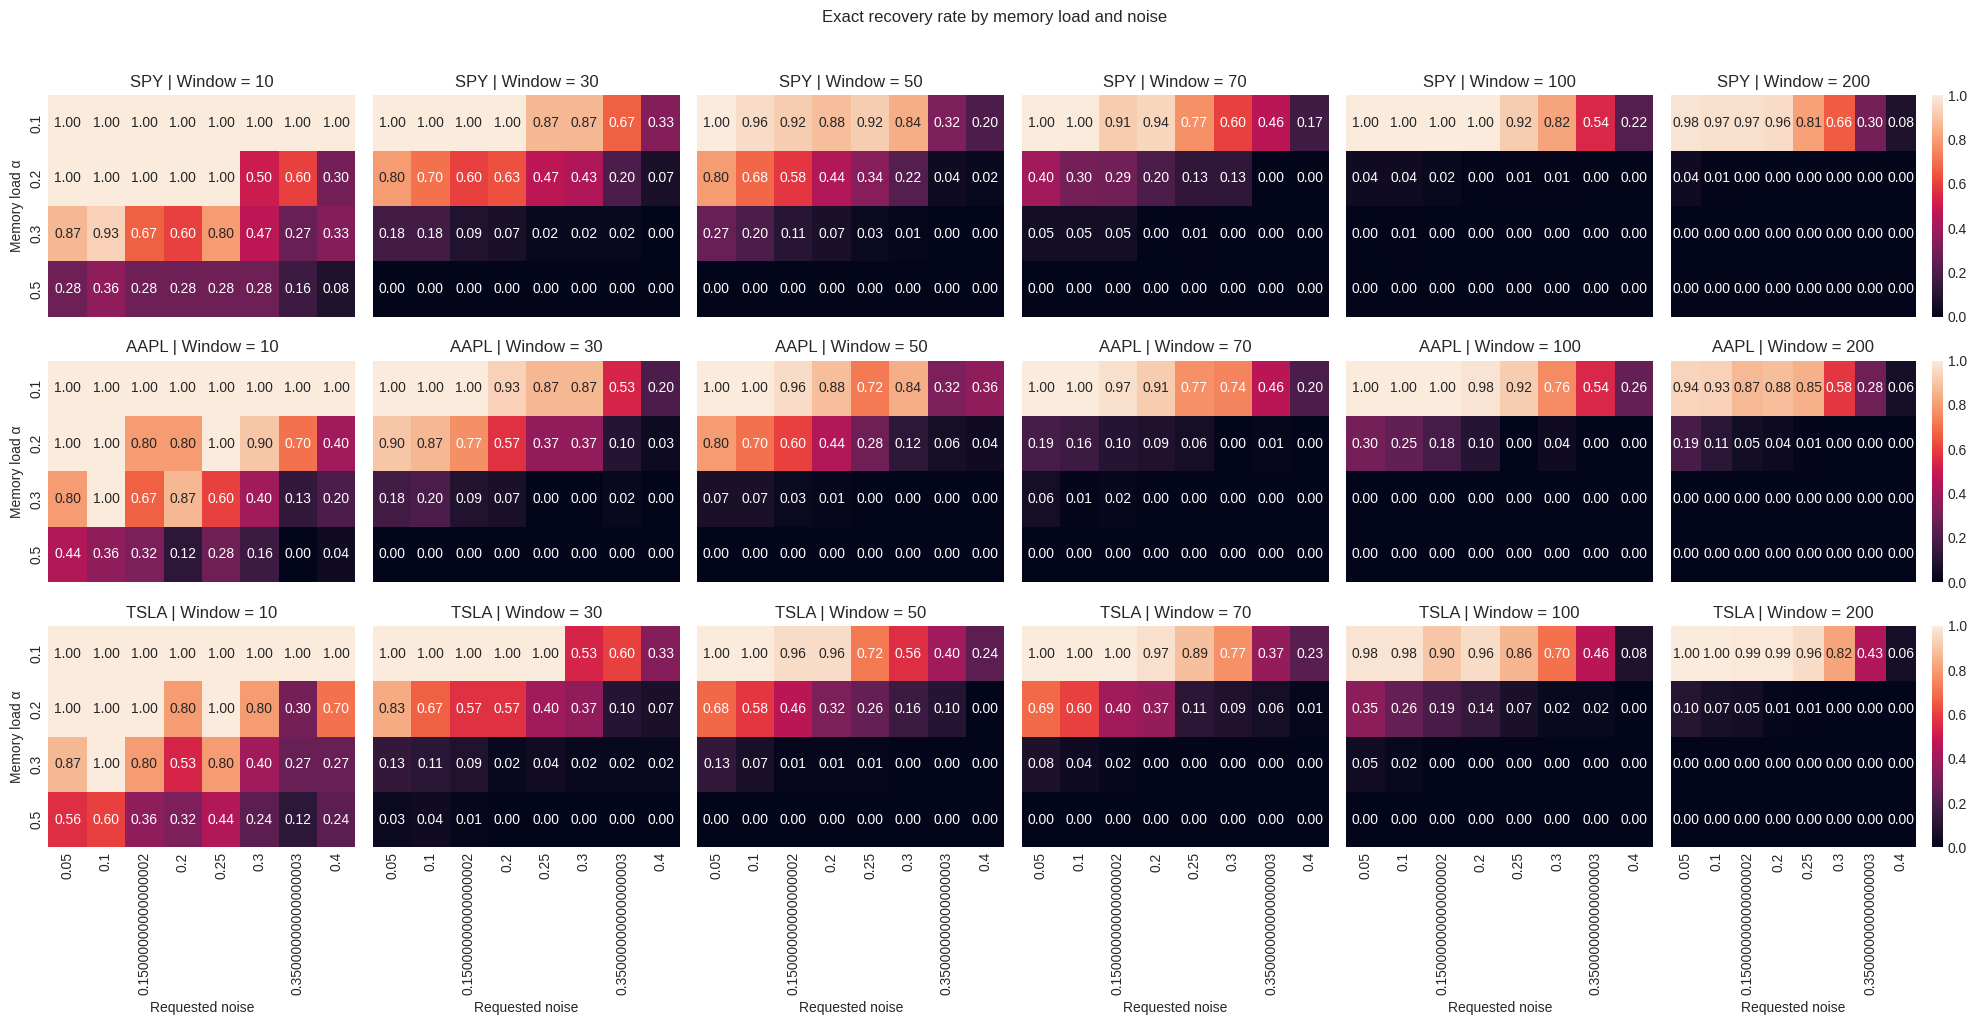

In [27]:
# =========================================================
# BLOCK 4.1.6: Exact recovery rate by memory load and noise
# =========================================================

fig, axes = plt.subplots(
    len(TICKERS),
    len(WINDOWS),
    figsize=(20, 10),
    sharex=True,
    sharey=True
)

for i, ticker in enumerate(TICKERS):
    for j, w in enumerate(WINDOWS):

        subset = load_noise_summary[
            (load_noise_summary["ticker"] == ticker) &
            (load_noise_summary["window"] == w)
        ]

        pivot = subset.pivot(
            index="alpha_actual",
            columns="requested_noise",
            values="exact_recovery_rate"
        )

        sns.heatmap(
            pivot,
            ax=axes[i, j],
            vmin=0,
            vmax=1,
            annot=True,
            fmt=".2f",
            cbar=(j == len(WINDOWS) - 1)
        )

        axes[i, j].set_title(f"{ticker} | Window = {w}")

        if i == len(TICKERS) - 1:
            axes[i, j].set_xlabel("Requested noise")
        else:
            axes[i, j].set_xlabel("")

        if j == 0:
            axes[i, j].set_ylabel("Memory load α")
        else:
            axes[i, j].set_ylabel("")

plt.suptitle(
    "Exact recovery rate by memory load and noise",
    y=1.02
)

plt.tight_layout()
plt.show()

**Figure analysis.**

Exact recovery is a strict criterion: every bit must return to the stored target.

At $\alpha \approx 0.1$, even long windows can be recovered exactly after modest corruption. At $\alpha \approx 0.2$, the exact-recovery region shrinks, especially for $L=100$ and $L=200$. At $\alpha \ge 0.3$, exact recovery becomes rare for most non-trivial windows, and at $\alpha \approx 0.5$ it nearly disappears beyond the shortest case.

The important conclusion is not simply that longer windows are worse. Long patterns can be recalled well when the memory is lightly loaded. The failure becomes pronounced primarily under the combination of **large state dimension and high memory load**.


### Mean restored accuracy


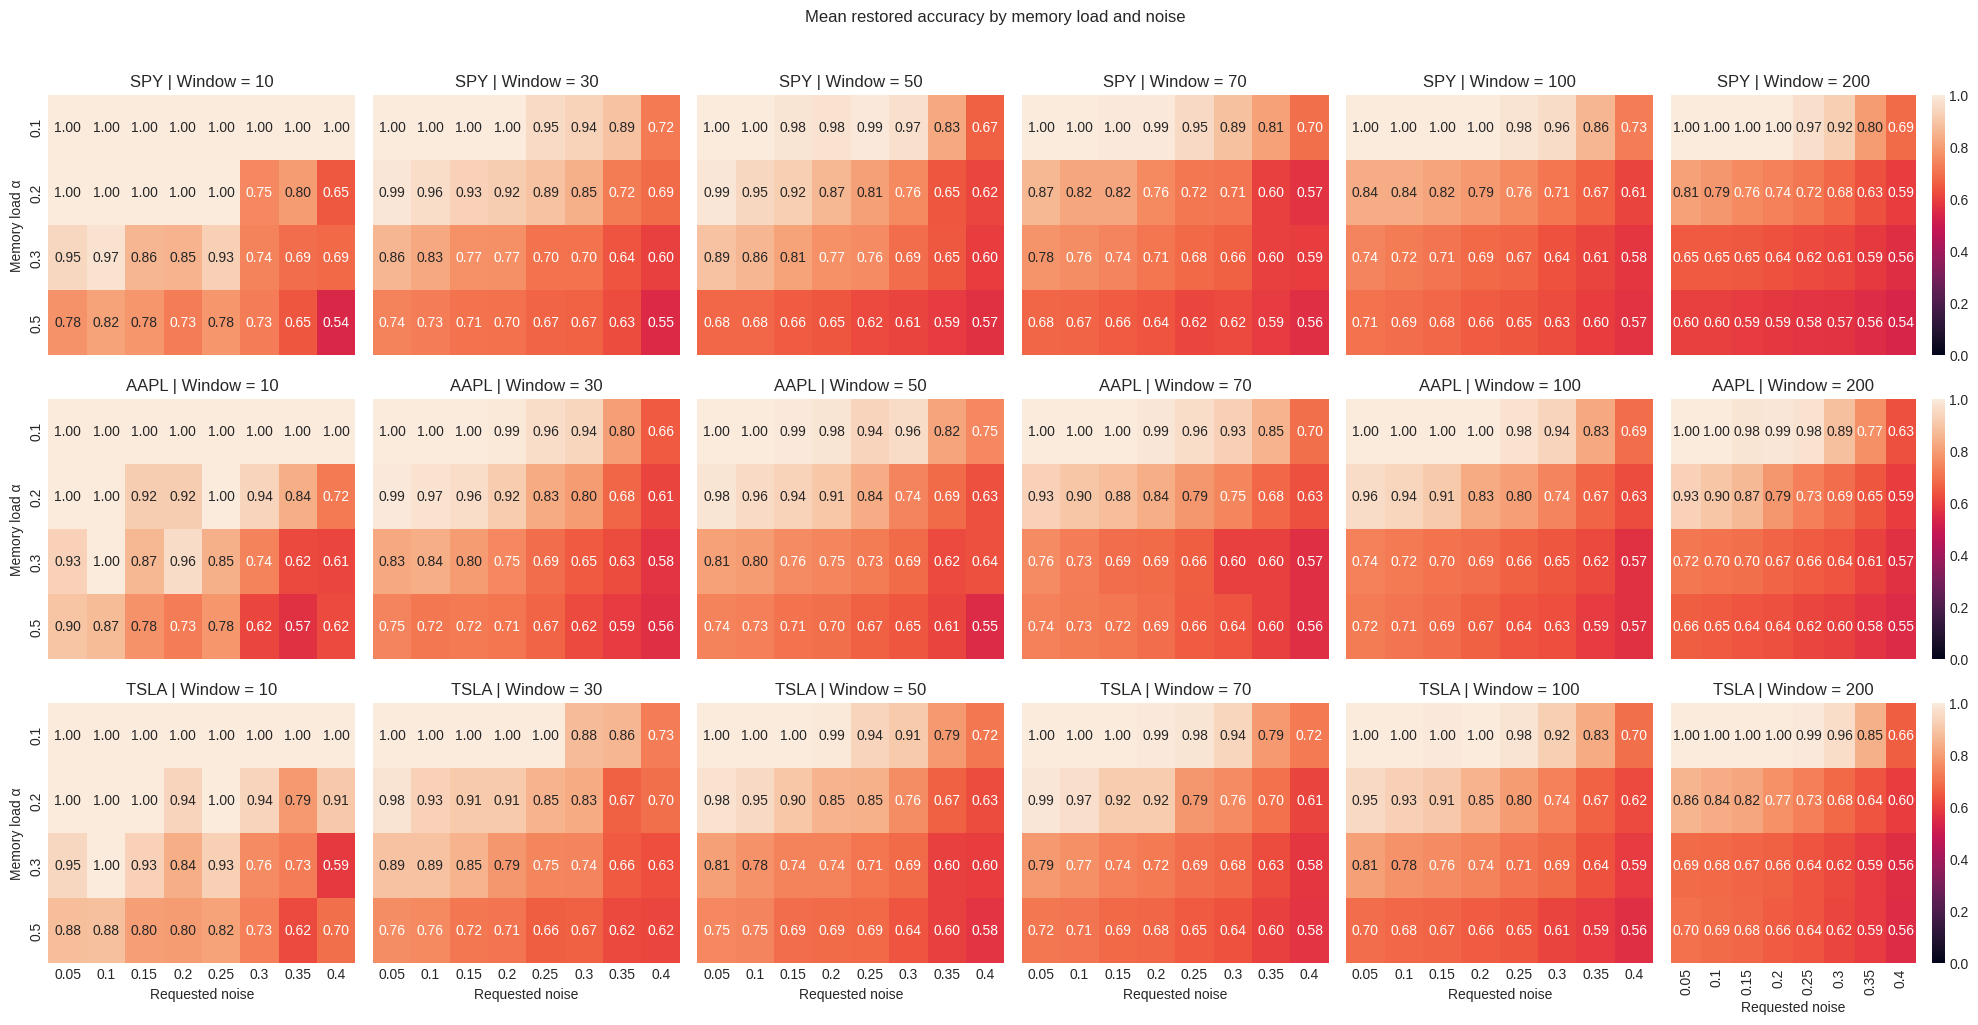

In [28]:
# =========================================================
# BLOCK 4.1.7: Mean restored accuracy by memory load and noise
# =========================================================

fig, axes = plt.subplots(
    len(TICKERS),
    len(WINDOWS),
    figsize=(20, 10),
    sharex=True,
    sharey=True
)

for i, ticker in enumerate(TICKERS):
    for j, w in enumerate(WINDOWS):

        subset = load_noise_summary[
            (load_noise_summary["ticker"] == ticker) &
            (load_noise_summary["window"] == w)
        ].copy()

        # Round only for cleaner axis labels.
        subset["noise"] = subset["requested_noise"].round(2)

        pivot = subset.pivot(
            index="alpha_actual",
            columns="noise",
            values="mean_acc_restored"
        )

        sns.heatmap(
            pivot,
            ax=axes[i, j],
            vmin=0,
            vmax=1,
            annot=True,
            fmt=".2f",
            cbar=(j == len(WINDOWS) - 1)
        )

        axes[i, j].set_title(f"{ticker} | Window = {w}")

        if i == len(TICKERS) - 1:
            axes[i, j].set_xlabel("Requested noise")
        else:
            axes[i, j].set_xlabel("")

        if j == 0:
            axes[i, j].set_ylabel("Memory load α")
        else:
            axes[i, j].set_ylabel("")

plt.suptitle(
    "Mean restored accuracy by memory load and noise",
    y=1.02
)

plt.tight_layout()
plt.show()

**Figure analysis.**

Mean restored accuracy provides a less strict view than exact recovery. It shows how much of the stored target remains correct even when one or more bits fail to recover.

At $\alpha \approx 0.1$, most configurations remain close to 0.9–1.0 under low and moderate corruption, including long windows. At $\alpha \approx 0.2$, the long-window curves begin to lose accuracy even under mild corruption. At $\alpha \approx 0.3$ and $0.5$, substantial degradation is visible across most windows.

For example, overloaded long-window networks can reduce an input that was initially about 95% correct to a final state close to 60% correct. Thus, high load can make the dynamics actively harmful rather than merely incomplete.

### Section 4.1 summary

Stored-pattern recall is controlled strongly by memory load. Low-load memories can recall even long patterns, whereas higher load produces interference and rapidly reduces both exact recovery and average accuracy. This establishes a reliable low-load regime in which later negative unseen-pattern results cannot be dismissed as simple memory overload.


## 4.2. Stability of clean unseen patterns

The next stage introduces a strict chronological split. The raw sign series is divided into an early training segment and a later test segment **before** sliding windows are created. This prevents any training window from sharing raw observations with a test window.

The network is then trained only on historical training patterns, while clean test windows are passed through the network without added noise. The question is simple:

> Does a new financial state remain stable under a Hopfield memory built only from earlier history?


In [29]:
# =========================================================
# BLOCK 4.2.1: Unseen-pattern experiment settings
# =========================================================

TRAIN_RATIO_UNSEEN = 0.8
ALPHA_LEVELS_UNSEEN = [0.05, 0.10, 0.15, 0.20]

# =========================================================
# BLOCK 4.2.2: Temporal split before window formation
# =========================================================

unseen_data_store = {}
unseen_split_info = []

for ticker in TICKERS:
    series_1d = binary_df[ticker].values

    # Chronological split is performed BEFORE creating windows.
    split_idx = int(len(series_1d) * TRAIN_RATIO_UNSEEN)

    train_series = series_1d[:split_idx]
    test_series = series_1d[split_idx:]

    for w in WINDOWS:

        if len(train_series) < w or len(test_series) < w:
            raise ValueError(
                f"Not enough observations for ticker={ticker}, window={w}"
            )

        train_patterns = extract_sliding_windows(
            train_series,
            window_length=w
        )

        test_patterns = extract_sliding_windows(
            test_series,
            window_length=w
        )

        unseen_data_store[(ticker, w)] = {
            "train_patterns": train_patterns,
            "test_patterns": test_patterns
        }

        unseen_split_info.append({
            "ticker": ticker,
            "window": w,
            "train_observations": len(train_series),
            "test_observations": len(test_series),
            "train_patterns": len(train_patterns),
            "test_patterns": len(test_patterns)
        })

unseen_split_info_df = pd.DataFrame(unseen_split_info)

unseen_split_info_df

,ticker,window,train_observations,test_observations,train_patterns,test_patterns
0,SPY,10,1204,302,1195,293
1,SPY,30,1204,302,1175,273
2,SPY,50,1204,302,1155,253
3,SPY,70,1204,302,1135,233
4,SPY,100,1204,302,1105,203
5,SPY,200,1204,302,1005,103
6,AAPL,10,1204,302,1195,293
7,AAPL,30,1204,302,1175,273
8,AAPL,50,1204,302,1155,253
9,AAPL,70,1204,302,1135,233


**Split check.** The table confirms that windows are formed independently inside the train and test segments. No raw test observation appears in a training window, so the unseen experiments use a leakage-safe temporal split.


### Realized memory configurations for unseen experiments


In [30]:
# =========================================================
# BLOCK 4.2.3: Memory configurations for unseen experiment
# =========================================================

unseen_memory_config = []

for w in WINDOWS:
    for alpha_requested in ALPHA_LEVELS_UNSEEN:

        memory_size = max(
            1,
            int(np.round(alpha_requested * w))
        )

        alpha_actual = memory_size / w

        unseen_memory_config.append({
            "window": w,
            "alpha_requested": alpha_requested,
            "memory_size": memory_size,
            "alpha_actual": alpha_actual
        })

unseen_memory_config_df = pd.DataFrame(unseen_memory_config)

unseen_memory_config_df

,window,alpha_requested,memory_size,alpha_actual
0,10,0.05,1,0.100000
1,10,0.10,1,0.100000
2,10,0.15,2,0.200000
3,10,0.20,2,0.200000
4,30,0.05,2,0.066667
5,30,0.10,3,0.100000
6,30,0.15,4,0.133333
7,30,0.20,6,0.200000
8,50,0.05,2,0.040000
9,50,0.10,5,0.100000


**Configuration note.** For short patterns, rounding can make different requested loads identical in practice. For example, with $N=10$, both requested $\alpha=0.05$ and $\alpha=0.10$ can correspond to $P=1$. Later plots therefore use the realized memory load rather than treating duplicated requested settings as distinct.


### Clean unseen stability experiment

All clean test windows are passed through the trained network without artificial corruption. If a complete sweep leaves a window unchanged, it is a fixed point of that trained memory.


In [31]:
# =========================================================
# BLOCK 4.2.4: Clean unseen-pattern stability experiment
# =========================================================

results_unseen_stability = []

for ticker in TICKERS:
    for w in WINDOWS:

        train_patterns = unseen_data_store[(ticker, w)]["train_patterns"]
        test_patterns = unseen_data_store[(ticker, w)]["test_patterns"]

        for alpha_requested in ALPHA_LEVELS_UNSEEN:

            memory_size = max(
                1,
                int(np.round(alpha_requested * w))
            )

            if memory_size > len(train_patterns):
                continue

            alpha_actual = memory_size / w

            memory_patterns = select_memory_patterns(train_patterns,memory_size)

            net = HopfieldNetwork(n_neurons=w)
            net.train(memory_patterns)

            for pattern_id, original_pattern in enumerate(test_patterns):

                restored_pattern = net.run(
                    original_pattern,
                    max_sweeps=20
                )

                acc_restored = accuracy(
                    original_pattern,
                    restored_pattern
                )

                hamming_restored = hamming_distance(
                    original_pattern,
                    restored_pattern
                )

                results_unseen_stability.append({
                    "ticker": ticker,
                    "window": w,

                    "alpha_requested": alpha_requested,
                    "alpha_actual": alpha_actual,
                    "memory_size": memory_size,

                    "pattern_id": pattern_id,

                    "acc_restored": acc_restored,
                    "hamming_restored": hamming_restored,

                    "exact_stable": hamming_restored == 0
                })

df_unseen_stability = pd.DataFrame(results_unseen_stability)

df_unseen_stability

,ticker,window,alpha_requested,alpha_actual,memory_size,pattern_id,acc_restored,hamming_restored,exact_stable
0,SPY,10,0.05,0.1,1,0,0.600,4,False
1,SPY,10,0.05,0.1,1,1,0.700,3,False
2,SPY,10,0.05,0.1,1,2,0.600,4,False
3,SPY,10,0.05,0.1,1,3,0.600,4,False
4,SPY,10,0.05,0.1,1,4,0.600,4,False
...,...,...,...,...,...,...,...,...,...
16291,TSLA,200,0.20,0.2,40,98,0.545,91,False
16292,TSLA,200,0.20,0.2,40,99,0.585,83,False
16293,TSLA,200,0.20,0.2,40,100,0.585,83,False
16294,TSLA,200,0.20,0.2,40,101,0.565,87,False


**Raw-result note.** There is no noise level and no repeated corruption in this experiment. Each row corresponds to one clean unseen test pattern under one network configuration.


### Aggregated clean-unseen stability


In [32]:
# =========================================================
# BLOCK 4.2.5: Clean unseen-pattern stability summary
# =========================================================

unseen_stability_summary = (
    df_unseen_stability
    .groupby(
        [
            "ticker",
            "window",
            "alpha_requested",
            "alpha_actual",
            "memory_size"
        ],
        as_index=False
    )
    .agg(
        n_test_patterns=("pattern_id", "count"),
        mean_acc_restored=("acc_restored", "mean"),
        mean_hamming_restored=("hamming_restored", "mean"),
        exact_stability_rate=("exact_stable", "mean")
    )
)

unseen_stability_summary

,ticker,window,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_acc_restored,mean_hamming_restored,exact_stability_rate
0,AAPL,10,0.05,0.100000,1,293,0.622526,3.774744,0.0
1,AAPL,10,0.10,0.100000,1,293,0.622526,3.774744,0.0
2,AAPL,10,0.15,0.200000,2,293,0.668942,3.310580,0.0
3,AAPL,10,0.20,0.200000,2,293,0.668942,3.310580,0.0
4,AAPL,30,0.05,0.066667,2,273,0.608669,11.739927,0.0
...,...,...,...,...,...,...,...,...,...
67,TSLA,100,0.20,0.200000,20,203,0.578325,42.167488,0.0
68,TSLA,200,0.05,0.050000,10,103,0.552233,89.553398,0.0
69,TSLA,200,0.10,0.100000,20,103,0.557087,88.582524,0.0
70,TSLA,200,0.15,0.150000,30,103,0.556117,88.776699,0.0


**Table analysis.** Clean unseen patterns are generally not preserved exactly. Even in low-load regimes that performed well on stored memories, the network changes most test windows. This establishes a clear distinction between **recall of stored states** and **generalization to new states**.


### Clean unseen accuracy by memory load


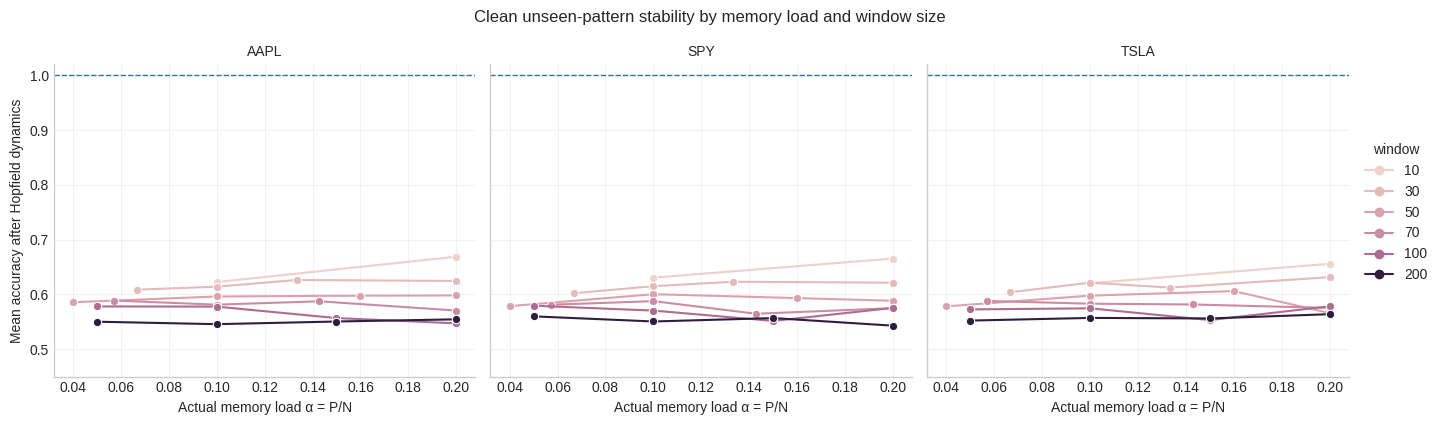

In [33]:
# =========================================================
# BLOCK 4.2.6: Clean unseen accuracy by memory load
# =========================================================

g = sns.relplot(
    data=unseen_stability_summary,
    x="alpha_actual",
    y="mean_acc_restored",
    hue="window",
    col="ticker",
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
    facet_kws={"sharex": True, "sharey": True}
)
g.set_axis_labels(
    "Actual memory load α = P/N",
    "Mean accuracy after Hopfield dynamics"
)
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.axhline(
        1.0,
        linestyle="--",
        linewidth=1
    )
    ax.set_ylim(0.45, 1.02)
    ax.grid(alpha=0.25)

g.fig.suptitle("Clean unseen-pattern stability by memory load and window size", y=1.05)
plt.show()

**Figure analysis.**

The contrast with stored-pattern recall is substantial.

- The highest mean retained accuracy appears for short windows and is only around the mid-0.6 range.
- For $L=100$ and $L=200$, many configurations lie roughly around 0.54–0.58, meaning that 40–45% of the bits can change even though the input was initially clean.
- Lowering $\alpha$ does not restore the near-perfect behaviour seen for explicitly stored patterns.
- The relationship with load is not consistently monotonic within 0.05–0.20; the dominant difference is between short and long contexts.

Therefore, a network can be a competent low-load associative memory while still failing to treat previously unseen financial windows as stable states.


### Exact stability


In [34]:
# =========================================================
# BLOCK 4.2.8: Exact stability check
# =========================================================

exact_stability_check = (
    unseen_stability_summary[
        unseen_stability_summary["exact_stability_rate"] > 0
    ]
)

exact_stability_check

,ticker,window,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_acc_restored,mean_hamming_restored,exact_stability_rate
24,SPY,10,0.05,0.1,1,293,0.630717,3.692833,0.006826
25,SPY,10,0.10,0.1,1,293,0.630717,3.692833,0.006826
26,SPY,10,0.15,0.2,2,293,0.665529,3.344710,0.006826
27,SPY,10,0.20,0.2,2,293,0.665529,3.344710,0.006826
50,TSLA,10,0.15,0.2,2,293,0.655973,3.440273,0.003413
51,TSLA,10,0.20,0.2,2,293,0.655973,3.440273,0.003413


**Diagnostic analysis.** Exact stability is almost absent. Non-zero exact-stability rates occur only in isolated $L=10$ configurations and remain below 1% of test patterns. For $L \ge 30$, no clean unseen test pattern remains completely unchanged in the reported configurations.

This rules out the interpretation that new financial windows naturally become additional attractors of the trained classical Hopfield memory.


### Best and worst clean-unseen configurations


In [35]:
# =========================================================
# BLOCK 4.2.9: Best and worst clean unseen configurations
# =========================================================

best_unseen_configs = (
    unseen_stability_summary
    .sort_values(
        "mean_acc_restored",
        ascending=False
    )
    .head(15)
)

worst_unseen_configs = (
    unseen_stability_summary
    .sort_values(
        "mean_acc_restored",
        ascending=True
    )
    .head(15)
)
print("Best unseen patterns")
display(best_unseen_configs)
print("")
print("Worst unseen patterns")
display(worst_unseen_configs)

Best unseen patterns


,ticker,window,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_acc_restored,mean_hamming_restored,exact_stability_rate
3,AAPL,10,0.20,0.200000,2,293,0.668942,3.310580,0.000000
2,AAPL,10,0.15,0.200000,2,293,0.668942,3.310580,0.000000
27,SPY,10,0.20,0.200000,2,293,0.665529,3.344710,0.006826
26,SPY,10,0.15,0.200000,2,293,0.665529,3.344710,0.006826
50,TSLA,10,0.15,0.200000,2,293,0.655973,3.440273,0.003413
51,TSLA,10,0.20,0.200000,2,293,0.655973,3.440273,0.003413
55,TSLA,30,0.20,0.200000,6,273,0.631502,11.054945,0.000000
24,SPY,10,0.05,0.100000,1,293,0.630717,3.692833,0.006826
25,SPY,10,0.10,0.100000,1,293,0.630717,3.692833,0.006826
6,AAPL,30,0.15,0.133333,4,273,0.626374,11.208791,0.000000



Worst unseen patterns


,ticker,window,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_acc_restored,mean_hamming_restored,exact_stability_rate
47,SPY,200,0.20,0.20,40,103,0.542913,91.417476,0.0
21,AAPL,200,0.10,0.10,20,103,0.545680,90.864078,0.0
19,AAPL,100,0.20,0.20,20,203,0.547192,45.280788,0.0
20,AAPL,200,0.05,0.05,10,103,0.550194,89.961165,0.0
22,AAPL,200,0.15,0.15,30,103,0.550534,89.893204,0.0
45,SPY,200,0.10,0.10,20,103,0.550583,89.883495,0.0
42,SPY,100,0.15,0.15,15,203,0.551576,44.842365,0.0
68,TSLA,200,0.05,0.05,10,103,0.552233,89.553398,0.0
66,TSLA,100,0.15,0.15,15,203,0.553153,44.684729,0.0
23,AAPL,200,0.20,0.20,40,103,0.554515,89.097087,0.0


**Diagnostic analysis.** The ranked tables show that the best configurations still fall far below the perfect stability observed for stored memories, while the worst configurations retain only a little more than half of the original bits. The spread confirms that the effect depends on scale and asset, but the overall conclusion is unchanged: exact unseen stability is not a general property of the trained network.

### Section 4.2 summary

A leakage-safe chronological test shows that clean unseen financial patterns are almost never fixed points of the classical Hopfield network. Low memory load is sufficient for reliable stored recall but is not sufficient for unseen generalization.


## 4.3. Historical association retrieval

Failure to preserve an unseen pattern does not necessarily mean that the network behaves randomly. A content-addressable memory may transform a new input toward a nearby stored historical state.

This section therefore measures:

- the nearest stored pattern before Hopfield dynamics;
- the nearest stored pattern after Hopfield dynamics;
- the change in Hamming distance to the memory;
- whether the final state exactly matches a stored pattern.


### Helper: nearest stored pattern


In [36]:
# =========================================================
# BLOCK 4.3.1: Nearest stored pattern
# =========================================================

def find_nearest_memory_pattern(pattern, memory_patterns):
    """
    Find the stored pattern with minimum Hamming distance
    to the given pattern.

    Returns:
        nearest_id: index of the nearest stored pattern
        nearest_distance: Hamming distance to the nearest stored pattern
    """
    distances = np.sum(memory_patterns != pattern,axis=1)

    nearest_id = int(np.argmin(distances))
    nearest_distance = int(distances[nearest_id])

    return nearest_id, nearest_distance

### Helper: indices of selected memory patterns

The original uniform selector returns pattern values. The next helper reproduces its indices so that a retrieved memory can be linked back to its historical position.


In [37]:
# =========================================================
# BLOCK 4.3.2: Memory-pattern indices
# =========================================================

def select_memory_pattern_indices(n_train, memory_size):
    """
    Return the indices of patterns selected
    by select_memory_patterns.
    """
    return np.linspace(0,n_train - 1,memory_size,dtype=int)

### Historical-association retrieval experiment


In [38]:
# =========================================================
# BLOCK 4.3.3: Historical association retrieval
# =========================================================

results_historical_retrieval = []

for ticker in TICKERS:
    for w in WINDOWS:

        train_patterns = unseen_data_store[(ticker, w)]["train_patterns"]
        test_patterns = unseen_data_store[(ticker, w)]["test_patterns"]

        for alpha_requested in ALPHA_LEVELS_UNSEEN:

            memory_size = max(
                1,
                int(np.round(alpha_requested * w))
            )

            if memory_size > len(train_patterns):
                continue

            alpha_actual = memory_size / w

            memory_indices = select_memory_pattern_indices(
                len(train_patterns),
                memory_size
            )

            memory_patterns = train_patterns[memory_indices]

            # Verify that the selection exactly matches
            # the existing select_memory_patterns function.
            assert np.array_equal(
                memory_patterns,
                select_memory_patterns(
                    train_patterns,
                    memory_size
                )
            )

            net = HopfieldNetwork(n_neurons=w)
            net.train(memory_patterns)

            for pattern_id, original_pattern in enumerate(test_patterns):

                # Nearest historical pattern BEFORE Hopfield dynamics.
                nearest_before_id, distance_before = (
                    find_nearest_memory_pattern(
                        original_pattern,
                        memory_patterns
                    )
                )

                # Hopfield dynamics.
                restored_pattern = net.run(
                    original_pattern,
                    max_sweeps=20
                )

                # Nearest historical pattern AFTER Hopfield dynamics.
                nearest_after_id, distance_after = (
                    find_nearest_memory_pattern(
                        restored_pattern,
                        memory_patterns
                    )
                )

                # Check whether the final state exactly matches
                # at least one stored pattern.
                exact_matches = np.all(
                    memory_patterns == restored_pattern,
                    axis=1
                )

                exact_memory_retrieval = bool(
                    np.any(exact_matches)
                )

                if exact_memory_retrieval:
                    retrieved_memory_id = int(
                        np.flatnonzero(exact_matches)[0]
                    )
                else:
                    retrieved_memory_id = None

                results_historical_retrieval.append({
                    "ticker": ticker,
                    "window": w,

                    "alpha_requested": alpha_requested,
                    "alpha_actual": alpha_actual,
                    "memory_size": memory_size,

                    "pattern_id": pattern_id,

                    "nearest_before_id": nearest_before_id,
                    "distance_before": distance_before,

                    "nearest_after_id": nearest_after_id,
                    "distance_after": distance_after,

                    "same_nearest_memory":
                        nearest_before_id == nearest_after_id,

                    "delta_distance_to_memory":
                        distance_before - distance_after,

                    "exact_memory_retrieval":
                        exact_memory_retrieval,

                    "retrieved_memory_id":
                        retrieved_memory_id
                })

df_historical_retrieval = pd.DataFrame(
    results_historical_retrieval
)

df_historical_retrieval

,ticker,window,alpha_requested,alpha_actual,memory_size,pattern_id,nearest_before_id,distance_before,nearest_after_id,distance_after,same_nearest_memory,delta_distance_to_memory,exact_memory_retrieval,retrieved_memory_id
0,SPY,10,0.05,0.1,1,0,0,4,0,0,True,4,True,0.0
1,SPY,10,0.05,0.1,1,1,0,7,0,10,True,-3,False,NaN
2,SPY,10,0.05,0.1,1,2,0,6,0,10,True,-4,False,NaN
3,SPY,10,0.05,0.1,1,3,0,4,0,0,True,4,True,0.0
4,SPY,10,0.05,0.1,1,4,0,6,0,10,True,-4,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16291,TSLA,200,0.20,0.2,40,98,19,83,26,63,False,20,False,NaN
16292,TSLA,200,0.20,0.2,40,99,12,82,10,56,False,26,False,NaN
16293,TSLA,200,0.20,0.2,40,100,39,78,39,57,True,21,False,NaN
16294,TSLA,200,0.20,0.2,40,101,6,90,33,70,False,20,False,NaN


**Raw-result note.** Each row records how one unseen test pattern relates to the stored historical memory before and after Hopfield dynamics. These trial-level results are aggregated next.


### Aggregated historical-retrieval summary


In [39]:
# =========================================================
# BLOCK 4.3.4: Historical retrieval summary
# =========================================================

historical_retrieval_summary = (
    df_historical_retrieval
    .groupby(
        [
            "ticker",
            "window",
            "alpha_requested",
            "alpha_actual",
            "memory_size"
        ],
        as_index=False
    )
    .agg(
        n_test_patterns=("pattern_id", "count"),

        mean_distance_before=(
            "distance_before",
            "mean"
        ),

        mean_distance_after=(
            "distance_after",
            "mean"
        ),

        mean_delta_distance_to_memory=(
            "delta_distance_to_memory",
            "mean"
        ),

        same_nearest_memory_rate=(
            "same_nearest_memory",
            "mean"
        ),

        exact_memory_retrieval_rate=(
            "exact_memory_retrieval",
            "mean"
        )
    )
)

historical_retrieval_summary

,ticker,window,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_distance_before,mean_distance_after,mean_delta_distance_to_memory,same_nearest_memory_rate,exact_memory_retrieval_rate
0,AAPL,10,0.05,0.100000,1,293,4.921502,4.778157,0.143345,1.000000,0.522184
1,AAPL,10,0.10,0.100000,1,293,4.921502,5.119454,-0.197952,1.000000,0.488055
2,AAPL,10,0.15,0.200000,2,293,3.979522,1.979522,2.000000,0.870307,0.505119
3,AAPL,10,0.20,0.200000,2,293,3.979522,1.911263,2.068259,0.853242,0.522184
4,AAPL,30,0.05,0.066667,2,273,13.329670,8.769231,4.560440,0.908425,0.512821
...,...,...,...,...,...,...,...,...,...,...,...
67,TSLA,100,0.20,0.200000,20,203,40.576355,24.339901,16.236453,0.211823,0.009852
68,TSLA,200,0.05,0.050000,10,103,88.436893,46.805825,41.631068,0.349515,0.262136
69,TSLA,200,0.10,0.100000,20,103,86.805825,52.097087,34.708738,0.203883,0.058252
70,TSLA,200,0.15,0.150000,30,103,85.291262,54.475728,30.815534,0.155340,0.000000


**Table analysis.** The summary shows that Hopfield often reduces the distance from an unseen pattern to the memory even though it does not preserve the unseen pattern itself. Exact matches with a stored memory are more common at low load and become rarer as load increases.


### Plot preparation using realized memory load


In [40]:
# =========================================================
# BLOCK 4.3.5: Data for historical retrieval visualizations
# =========================================================

retrieval_plot_summary = (
    historical_retrieval_summary
    .groupby(
        ["ticker", "window", "alpha_actual"],
        as_index=False
    )
    .agg(
        mean_distance_before=("mean_distance_before", "mean"),
        mean_distance_after=("mean_distance_after", "mean"),
        mean_delta_distance_to_memory=("mean_delta_distance_to_memory", "mean"),
        exact_memory_retrieval_rate=("exact_memory_retrieval_rate", "mean"),
        same_nearest_memory_rate=("same_nearest_memory_rate", "mean")
    )
)

retrieval_plot_summary["normalized_delta_distance"] = (
    retrieval_plot_summary["mean_delta_distance_to_memory"]
    / retrieval_plot_summary["window"]
)

retrieval_plot_summary

,ticker,window,alpha_actual,mean_distance_before,mean_distance_after,mean_delta_distance_to_memory,exact_memory_retrieval_rate,same_nearest_memory_rate,normalized_delta_distance
0,AAPL,10,0.100000,4.921502,4.948805,-0.027304,0.505119,1.000000,-0.002730
1,AAPL,10,0.200000,3.979522,1.945392,2.034130,0.513652,0.861775,0.203413
2,AAPL,30,0.066667,13.329670,8.769231,4.560440,0.512821,0.908425,0.152015
3,AAPL,30,0.100000,12.912088,9.758242,3.153846,0.406593,0.677656,0.105128
4,AAPL,30,0.133333,12.047619,6.868132,5.179487,0.373626,0.600733,0.172650
...,...,...,...,...,...,...,...,...,...
61,TSLA,100,0.200000,40.576355,24.339901,16.236453,0.009852,0.211823,0.162365
62,TSLA,200,0.050000,88.436893,46.805825,41.631068,0.262136,0.349515,0.208155
63,TSLA,200,0.100000,86.805825,52.097087,34.708738,0.058252,0.203883,0.173544
64,TSLA,200,0.150000,85.291262,54.475728,30.815534,0.000000,0.155340,0.154078


Raw Hamming-distance reductions are normalized by window length before comparing different temporal scales. A ten-bit reduction has a very different meaning for $L=10$ and $L=200$, so the normalized measure expresses movement as a fraction of the state dimension.


### Relative movement toward stored memory


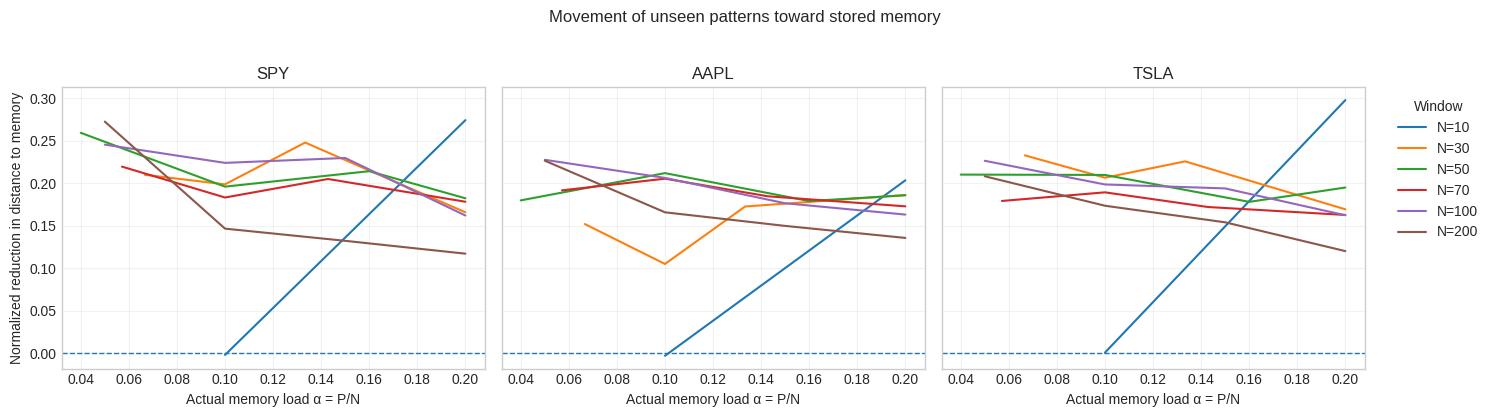

In [41]:
# =========================================================
# BLOCK 4.3.6: Relative movement toward stored memory
# =========================================================

fig, axes = plt.subplots(
    1,
    len(TICKERS),
    figsize=(15, 4),
    sharey=True
)

for ax, ticker in zip(axes, TICKERS):

    subset = retrieval_plot_summary[
        retrieval_plot_summary["ticker"] == ticker
    ]

    for w in WINDOWS:

        window_data = (
            subset[subset["window"] == w]
            .sort_values("alpha_actual")
        )

        ax.plot(
            window_data["alpha_actual"],
            window_data["normalized_delta_distance"],
            label=f"N={w}"
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(ticker)
    ax.set_xlabel("Actual memory load α = P/N")
    ax.grid(alpha=0.25)

axes[0].set_ylabel(
    "Normalized reduction in distance to memory"
)

axes[-1].legend(
    title="Window",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.suptitle(
    "Movement of unseen patterns toward stored memory",
    y=1.03
)

plt.tight_layout()
plt.show()

**Figure analysis.**

For most assets and window lengths, Hopfield dynamics moves unseen test patterns closer to at least one stored historical pattern. The normalized reduction is usually modest but clearly positive in many low-load configurations.

The result refines the clean-unseen experiment: new market states do not become their own stable attractors, but the network still performs associative transformation toward the finite set of memories it supports.

The strength of this movement does not by itself imply successful reconstruction of the original unseen state. That distinction becomes central in the noisy-unseen experiment.


### Exact retrieval of a stored historical pattern


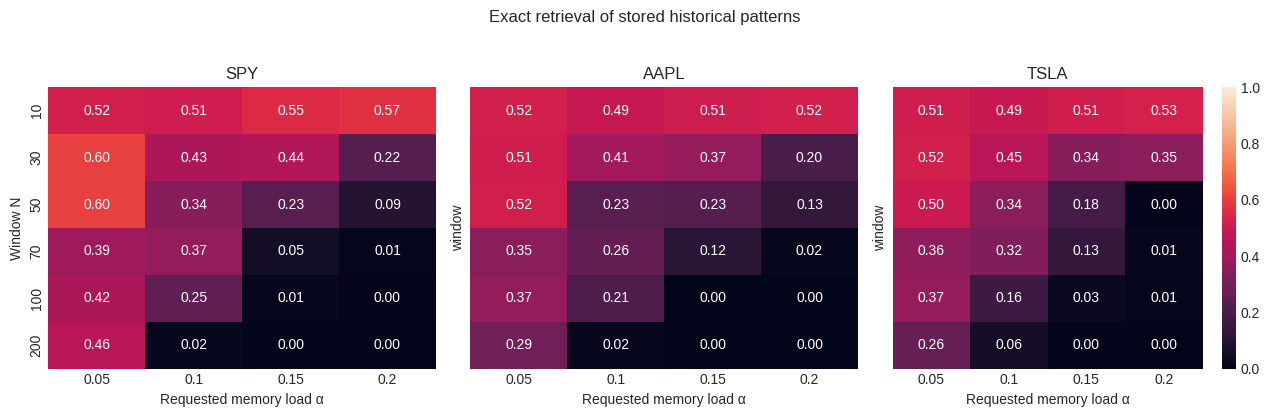

In [42]:
# =========================================================
# BLOCK 4.3.7: Exact historical memory retrieval
# Updated plotting cell:
# Build the heatmap by alpha_requested rather than alpha_actual
# =========================================================

retrieval_heatmap_summary = (
    historical_retrieval_summary
    .groupby(
        ["ticker", "window", "alpha_requested"],
        as_index=False
    )
    .agg(
        exact_memory_retrieval_rate=(
            "exact_memory_retrieval_rate",
            "mean"
        )
    )
)

fig, axes = plt.subplots(
    1,
    len(TICKERS),
    figsize=(13, 4),
    sharey=True
)

for ax, ticker in zip(axes, TICKERS):

    subset = retrieval_heatmap_summary[
        retrieval_heatmap_summary["ticker"] == ticker
    ]

    pivot = subset.pivot(
        index="window",
        columns="alpha_requested",
        values="exact_memory_retrieval_rate"
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=ax is axes[-1]
    )

    ax.set_title(ticker)
    ax.set_xlabel("Requested memory load α")

axes[0].set_ylabel("Window N")

fig.suptitle(
    "Exact retrieval of stored historical patterns",
    y=1.03
)

plt.tight_layout()
plt.show()

**Figure analysis.**

At low memory load, the final network state can sometimes coincide exactly with one of the stored historical patterns. The exact-match rate falls sharply as window length or load increases.

This behaviour is consistent with the classical model: at low load the basin structure is dominated by explicit memories, while higher load increases interference and the frequency of intermediate or spurious attractors.

### Section 4.3 summary

The network does exhibit associative behaviour on unseen financial inputs: it frequently moves them toward historical memory. However, association with stored history is not the same as preserving or reconstructing the true unseen state.


## 4.4. Alternative representation: volatility patterns

Sign-only patterns discard return magnitude. To test whether a more persistent aspect of market dynamics is being lost, a binary volatility representation is constructed from the absolute return.

The threshold is the median absolute return of the **training split only**. Values above the training median are encoded as $+1$ and the rest as $-1$. The test set never influences the threshold.


In [43]:
# =========================================================
# BLOCK 4.4.1: Volatility representation
# =========================================================

volatility_data_store = {}
volatility_threshold_info = []

for ticker in TICKERS:

    returns_1d = log_returns_df[ticker].values

    split_idx = int(
        len(returns_1d) * TRAIN_RATIO_UNSEEN
    )

    train_returns = returns_1d[:split_idx]
    test_returns = returns_1d[split_idx:]

    # Compute the threshold from the training split only.
    volatility_threshold = np.median(
        np.abs(train_returns)
    )

    train_volatility_series = np.where(
        np.abs(train_returns) > volatility_threshold,
        1,
        -1
    )

    test_volatility_series = np.where(
        np.abs(test_returns) > volatility_threshold,
        1,
        -1
    )

    volatility_threshold_info.append({
        "ticker": ticker,
        "threshold": volatility_threshold,
        "train_high_volatility_ratio": np.mean(
            train_volatility_series == 1
        ),
        "test_high_volatility_ratio": np.mean(
            test_volatility_series == 1
        )
    })

    for w in WINDOWS:

        train_patterns = extract_sliding_windows(
            train_volatility_series,
            window_length=w
        )

        test_patterns = extract_sliding_windows(
            test_volatility_series,
            window_length=w
        )

        volatility_data_store[(ticker, w)] = {
            "train_patterns": train_patterns,
            "test_patterns": test_patterns
        }

volatility_threshold_info_df = pd.DataFrame(
    volatility_threshold_info
)

volatility_threshold_info_df

,ticker,threshold,train_high_volatility_ratio,test_high_volatility_ratio
0,SPY,0.006418,0.5,0.357616
1,AAPL,0.010120,0.5,0.407285
2,TSLA,0.020894,0.5,0.556291


**Representation check.** By construction, the training high-volatility ratio is approximately 0.5. The test ratio is free to differ because it reflects the later market regime. This confirms that the volatility channel is balanced on train without using future information.


### Clean unseen stability for volatility patterns


In [44]:
# =========================================================
# BLOCK 4.4.3: Clean unseen stability for volatility patterns
# =========================================================

results_volatility_unseen_stability = []

for ticker in TICKERS:
    for w in WINDOWS:
        train_patterns = (volatility_data_store[(ticker, w)]["train_patterns"])
        test_patterns = (volatility_data_store[(ticker, w)]["test_patterns"])

        for alpha_requested in ALPHA_LEVELS_UNSEEN:
            memory_size = max(1,int(np.round(alpha_requested * w)))

            if memory_size > len(train_patterns):
                continue

            alpha_actual = memory_size / w
            memory_patterns = select_memory_patterns(train_patterns,memory_size)

            net = HopfieldNetwork(n_neurons=w)
            net.train(memory_patterns)

            for pattern_id, original_pattern in enumerate(test_patterns):
                restored_pattern = net.run(original_pattern,max_sweeps=20)
                acc_restored = accuracy(original_pattern,restored_pattern)
                hamming_restored = hamming_distance(original_pattern,restored_pattern)

                results_volatility_unseen_stability.append({
                    "ticker": ticker,
                    "window": w,
                    "alpha_requested": alpha_requested,
                    "alpha_actual": alpha_actual,
                    "memory_size": memory_size,
                    "pattern_id": pattern_id,
                    "acc_restored": acc_restored,
                    "hamming_restored": hamming_restored,
                    "exact_stable":
                        hamming_restored == 0
                })

df_volatility_unseen_stability = pd.DataFrame(results_volatility_unseen_stability)
df_volatility_unseen_stability

,ticker,window,alpha_requested,alpha_actual,memory_size,pattern_id,acc_restored,hamming_restored,exact_stable
0,SPY,10,0.05,0.1,1,0,0.500,5,False
1,SPY,10,0.05,0.1,1,1,0.700,3,False
2,SPY,10,0.05,0.1,1,2,0.600,4,False
3,SPY,10,0.05,0.1,1,3,0.600,4,False
4,SPY,10,0.05,0.1,1,4,0.600,4,False
...,...,...,...,...,...,...,...,...,...
16291,TSLA,200,0.20,0.2,40,98,0.585,83,False
16292,TSLA,200,0.20,0.2,40,99,0.545,91,False
16293,TSLA,200,0.20,0.2,40,100,0.555,89,False
16294,TSLA,200,0.20,0.2,40,101,0.535,93,False


The same clean-unseen stability question is repeated without changing the Hopfield architecture. Only the binary representation of the financial state changes.


In [45]:
# =========================================================
# BLOCK 4.4.4: Volatility unseen-stability summary
# =========================================================

volatility_unseen_stability_summary = (
    df_volatility_unseen_stability
    .groupby(
        [
            "ticker",
            "window",
            "alpha_requested",
            "alpha_actual",
            "memory_size"
        ],
        as_index=False
    )
    .agg(
        n_test_patterns=("pattern_id", "count"),
        mean_acc_restored=("acc_restored", "mean"),
        mean_hamming_restored=(
            "hamming_restored",
            "mean"
        ),
        exact_stability_rate=("exact_stable", "mean")
    )
)

volatility_unseen_stability_summary

,ticker,window,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_acc_restored,mean_hamming_restored,exact_stability_rate
0,AAPL,10,0.05,0.100000,1,293,0.612628,3.873720,0.000000
1,AAPL,10,0.10,0.100000,1,293,0.612628,3.873720,0.000000
2,AAPL,10,0.15,0.200000,2,293,0.658362,3.416382,0.003413
3,AAPL,10,0.20,0.200000,2,293,0.658362,3.416382,0.003413
4,AAPL,30,0.05,0.066667,2,273,0.602442,11.926740,0.000000
...,...,...,...,...,...,...,...,...,...
67,TSLA,100,0.20,0.200000,20,203,0.575616,42.438424,0.000000
68,TSLA,200,0.05,0.050000,10,103,0.557816,88.436893,0.000000
69,TSLA,200,0.10,0.100000,20,103,0.564029,87.194175,0.000000
70,TSLA,200,0.15,0.150000,30,103,0.568641,86.271845,0.000000


**Table analysis.** Volatility-only patterns are more stable than sign-only patterns in some configurations and less stable in others. The change of representation therefore affects the geometry of the memory, but it does not create a general regime of unseen stability.


### Sign-only versus volatility-only


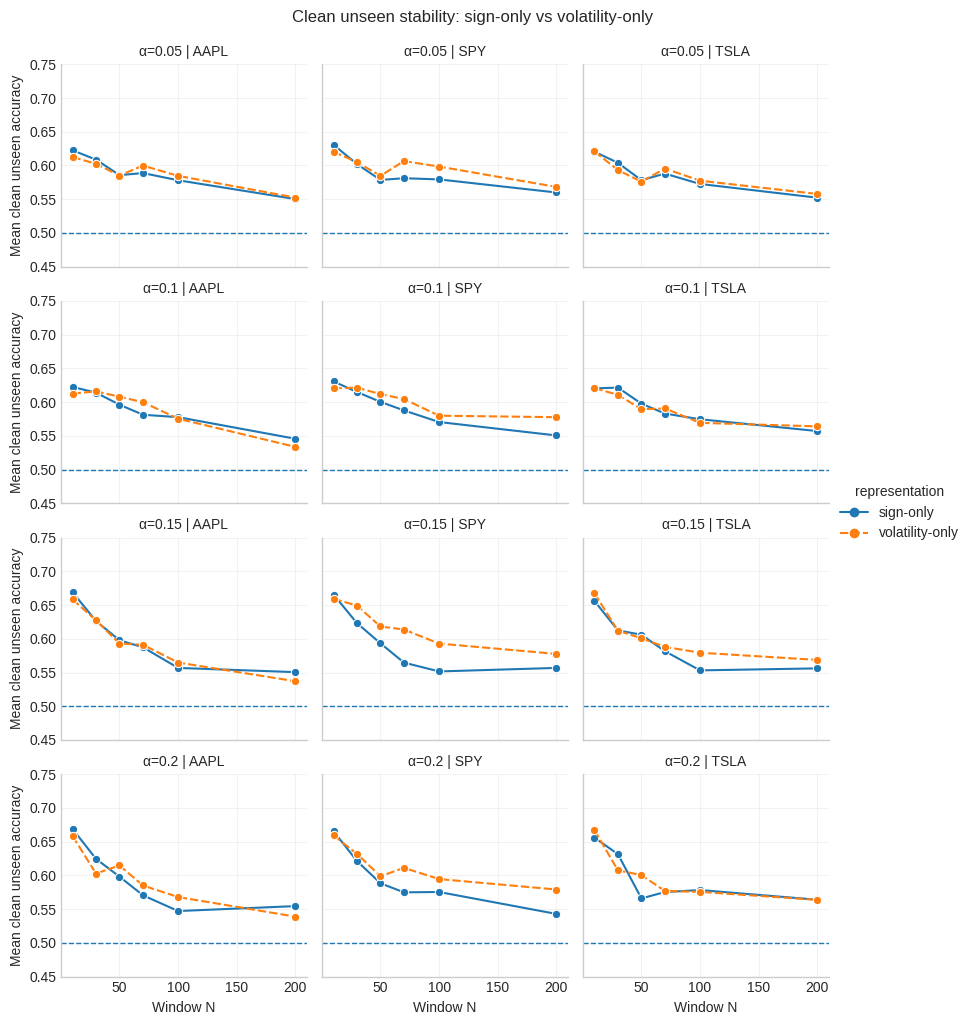

In [46]:
# =========================================================
# BLOCK 4.4.5: Sign-only vs volatility-only comparison
# =========================================================

sign_comparison = (
    unseen_stability_summary[
        [
            "ticker",
            "window",
            "alpha_requested",
            "mean_acc_restored"
        ]
    ]
    .copy()
)

sign_comparison["representation"] = "sign-only"


volatility_comparison = (
    volatility_unseen_stability_summary[
        [
            "ticker",
            "window",
            "alpha_requested",
            "mean_acc_restored"
        ]
    ]
    .copy()
)

volatility_comparison["representation"] = "volatility-only"


representation_comparison = pd.concat(
    [
        sign_comparison,
        volatility_comparison
    ],
    ignore_index=True
)

# =========================================================
# BLOCK 4.4.6: Sign vs volatility unseen stability
# =========================================================

g = sns.relplot(
    data=representation_comparison,
    x="window",
    y="mean_acc_restored",
    hue="representation",
    style="representation",
    col="ticker",
    row="alpha_requested",
    kind="line",
    marker="o",
    height=2.5,
    aspect=1.15
)

g.set_axis_labels(
    "Window N",
    "Mean clean unseen accuracy"
)

g.set_titles(
    "α={row_name} | {col_name}"
)

for ax in g.axes.flat:
    ax.set_ylim(0.45, 0.75)
    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1
    )
    ax.grid(alpha=0.25)

g.fig.suptitle(
    "Clean unseen stability: sign-only vs volatility-only",
    y=1.02
)

plt.show()

**Figure analysis.**

The relative advantage of volatility depends on asset, window length, and memory load. Some long-window configurations preserve the volatility channel better than the sign channel, which is consistent with volatility being more persistent than return direction in many financial series.

However, neither representation approaches the near-perfect retained accuracy observed for stored patterns. The key failure therefore cannot be removed simply by replacing return direction with a binary magnitude state.


### Accuracy difference between the two representations


In [47]:
# =========================================================
# BLOCK 4.4.7: Accuracy difference between representations
# =========================================================

representation_difference = (
    representation_comparison
    .pivot(
        index=[
            "ticker",
            "window",
            "alpha_requested"
        ],
        columns="representation",
        values="mean_acc_restored"
    )
    .reset_index()
)

representation_difference["volatility_minus_sign"] = (
    representation_difference["volatility-only"]
    - representation_difference["sign-only"]
)

representation_difference = (
    representation_difference
    .sort_values(
        "volatility_minus_sign",
        ascending=False
    )
)

representation_difference

representation,ticker,window,alpha_requested,sign-only,volatility-only,volatility_minus_sign
38,SPY,70,0.15,0.564684,0.613734,0.049050
42,SPY,100,0.15,0.551576,0.592906,0.041330
39,SPY,70,0.20,0.574923,0.611220,0.036297
47,SPY,200,0.20,0.542913,0.579126,0.036214
59,TSLA,50,0.20,0.565850,0.600553,0.034704
...,...,...,...,...,...,...
21,AAPL,200,0.10,0.545680,0.533641,-0.012039
22,AAPL,200,0.15,0.550534,0.537039,-0.013495
23,AAPL,200,0.20,0.554515,0.538883,-0.015631
7,AAPL,30,0.20,0.624542,0.602808,-0.021734


**Table analysis.** The signed differences change direction across configurations. This confirms that there is no universally superior single-channel binary representation in the tested setting.

### Section 4.4 summary

Volatility carries somewhat different temporal structure from return sign, but switching from sign-only to volatility-only does not solve the unseen-generalization problem. This motivates combining both channels rather than choosing one.


## 4.5. Combined sign + volatility representation

The next representation concatenates the two binary channels:

$$
X_t^{\mathrm{combined}}
=
[
X_t^{\mathrm{sign}}
\mid
X_t^{\mathrm{volatility}}
].
$$

For an original window length $L$, the Hopfield state therefore has $N=2L$ neurons. This allows a single memory to encode direction, movement magnitude, and their joint configuration.


In [48]:
# =========================================================
# BLOCK 4.5.1: Combined sign + volatility representation
# =========================================================

combined_data_store = {}

for ticker in TICKERS:
    for w in WINDOWS:

        sign_train_patterns = (unseen_data_store[(ticker, w)]["train_patterns"])
        sign_test_patterns = (unseen_data_store[(ticker, w)]["test_patterns"])

        volatility_train_patterns = (volatility_data_store[(ticker, w)]["train_patterns"])
        volatility_test_patterns = (volatility_data_store[(ticker, w)]["test_patterns"])

        # Both representations refer to exactly the same
        # temporal windows.
        if len(sign_train_patterns) != len(volatility_train_patterns):
            raise RuntimeError(f"Train pattern mismatch for {ticker}, window={w}")

        if len(sign_test_patterns) != len(volatility_test_patterns):
            raise RuntimeError(f"Test pattern mismatch for {ticker}, window={w}")

        combined_train_patterns = np.concatenate([sign_train_patterns,volatility_train_patterns],axis=1)
        combined_test_patterns = np.concatenate([sign_test_patterns,volatility_test_patterns],axis=1)
        combined_data_store[(ticker, w)] = {
            "train_patterns": combined_train_patterns,
            "test_patterns": combined_test_patterns
        }

### Realized memory loads for the combined state


In [49]:
# =========================================================
# BLOCK 4.5.2: Combined representation memory configuration
# =========================================================

combined_memory_config = []

for w in WINDOWS:
    n_neurons = 2 * w
    for alpha_requested in ALPHA_LEVELS_UNSEEN:
        memory_size = max(1,int(np.round(alpha_requested * n_neurons)))
        alpha_actual = memory_size / n_neurons
        combined_memory_config.append({
            "window": w,
            "n_neurons": n_neurons,
            "alpha_requested": alpha_requested,
            "memory_size": memory_size,
            "alpha_actual": alpha_actual
        })

combined_memory_config_df = pd.DataFrame(combined_memory_config)
combined_memory_config_df

,window,n_neurons,alpha_requested,memory_size,alpha_actual
0,10,20,0.05,1,0.05
1,10,20,0.10,2,0.10
2,10,20,0.15,3,0.15
3,10,20,0.20,4,0.20
4,30,60,0.05,3,0.05
5,30,60,0.10,6,0.10
6,30,60,0.15,9,0.15
7,30,60,0.20,12,0.20
8,50,100,0.05,5,0.05
9,50,100,0.10,10,0.10


**Configuration note.** At the same requested $\alpha$, the combined representation has twice as many neurons and therefore can store a different absolute number of patterns. Direct cross-representation comparisons are consequently descriptive rather than strict causal ablations at fixed $P$.


### Clean unseen stability of the combined representation


In [50]:
# =========================================================
# BLOCK 4.5.3: Clean unseen stability
# for combined sign + volatility patterns
# =========================================================

results_combined_unseen_stability = []

for ticker in TICKERS:
    for w in WINDOWS:
        train_patterns = (combined_data_store[(ticker, w)]["train_patterns"])
        test_patterns = (combined_data_store[(ticker, w)]["test_patterns"])
        n_neurons = 2 * w
        for alpha_requested in ALPHA_LEVELS_UNSEEN:
            memory_size = max(1,int(np.round(alpha_requested * n_neurons)))
            if memory_size > len(train_patterns):
                continue
            alpha_actual = memory_size / n_neurons
            memory_patterns = select_memory_patterns(train_patterns,memory_size)

            net = HopfieldNetwork(n_neurons=n_neurons)
            net.train(memory_patterns)

            for pattern_id, original_pattern in enumerate(test_patterns):
                restored_pattern = net.run(original_pattern,max_sweeps=20)

                acc_restored = accuracy(original_pattern,restored_pattern)
                sign_acc_restored = accuracy(original_pattern[:w],restored_pattern[:w])
                volatility_acc_restored = accuracy(original_pattern[w:],restored_pattern[w:])
                hamming_restored = hamming_distance(original_pattern,restored_pattern)
                results_combined_unseen_stability.append({
                    "ticker": ticker,
                    "window": w,
                    "n_neurons": n_neurons,

                    "alpha_requested": alpha_requested,
                    "alpha_actual": alpha_actual,
                    "memory_size": memory_size,

                    "pattern_id": pattern_id,

                    "acc_restored": acc_restored,
                    "sign_acc_restored": sign_acc_restored,
                    "volatility_acc_restored":
                        volatility_acc_restored,

                    "hamming_restored": hamming_restored,

                    "exact_stable":
                        hamming_restored == 0
                })

df_combined_unseen_stability = pd.DataFrame(results_combined_unseen_stability)
df_combined_unseen_stability

,ticker,window,n_neurons,alpha_requested,alpha_actual,memory_size,pattern_id,acc_restored,sign_acc_restored,volatility_acc_restored,hamming_restored,exact_stable
0,SPY,10,20,0.05,0.05,1,0,0.5500,0.600,0.500,9,False
1,SPY,10,20,0.05,0.05,1,1,0.5000,0.300,0.700,10,False
2,SPY,10,20,0.05,0.05,1,2,0.5000,0.400,0.600,10,False
3,SPY,10,20,0.05,0.05,1,3,0.5000,0.600,0.400,10,False
4,SPY,10,20,0.05,0.05,1,4,0.6000,0.600,0.600,8,False
...,...,...,...,...,...,...,...,...,...,...,...,...
16291,TSLA,200,400,0.20,0.20,80,98,0.5700,0.575,0.565,172,False
16292,TSLA,200,400,0.20,0.20,80,99,0.5400,0.580,0.500,184,False
16293,TSLA,200,400,0.20,0.20,80,100,0.5475,0.550,0.545,181,False
16294,TSLA,200,400,0.20,0.20,80,101,0.5650,0.535,0.595,174,False


In [51]:
# =========================================================
# BLOCK 4.5.4: Combined unseen-stability summary
# =========================================================

combined_unseen_stability_summary = (
    df_combined_unseen_stability
    .groupby(
        [
            "ticker",
            "window",
            "n_neurons",
            "alpha_requested",
            "alpha_actual",
            "memory_size"
        ],
        as_index=False
    )
    .agg(
        n_test_patterns=("pattern_id", "count"),

        mean_acc_restored=(
            "acc_restored",
            "mean"
        ),

        mean_sign_acc_restored=(
            "sign_acc_restored",
            "mean"
        ),

        mean_volatility_acc_restored=(
            "volatility_acc_restored",
            "mean"
        ),

        mean_hamming_restored=(
            "hamming_restored",
            "mean"
        ),

        exact_stability_rate=(
            "exact_stable",
            "mean"
        )
    )
)

combined_unseen_stability_summary

,ticker,window,n_neurons,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_acc_restored,mean_sign_acc_restored,mean_volatility_acc_restored,mean_hamming_restored,exact_stability_rate
0,AAPL,10,20,0.05,0.05,1,293,0.579010,0.584300,0.573720,8.419795,0.0
1,AAPL,10,20,0.10,0.10,2,293,0.622355,0.633447,0.611263,7.552901,0.0
2,AAPL,10,20,0.15,0.15,3,293,0.627474,0.636177,0.618771,7.450512,0.0
3,AAPL,10,20,0.20,0.20,4,293,0.655461,0.649829,0.661092,6.890785,0.0
4,AAPL,30,60,0.05,0.05,3,273,0.584676,0.584249,0.585104,24.919414,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
67,TSLA,100,200,0.20,0.20,40,203,0.568350,0.560690,0.576010,86.330049,0.0
68,TSLA,200,400,0.05,0.05,20,103,0.546432,0.541117,0.551748,181.427184,0.0
69,TSLA,200,400,0.10,0.10,40,103,0.548568,0.542524,0.554612,180.572816,0.0
70,TSLA,200,400,0.15,0.15,60,103,0.556214,0.548981,0.563447,177.514563,0.0


**Table analysis.**

Combining sign and volatility does not make clean unseen patterns stable attractors. Exact stability remains effectively zero in the reported configurations.

Short windows can reach retained accuracies in the low-to-mid 0.6 range, but the longer windows again fall toward roughly 0.55–0.60. The combined state therefore enriches the input without eliminating the gap between stored recall and unseen generalization.


### Historical retrieval in the combined representation


In [52]:
# =========================================================
# BLOCK 4.5.5: Historical retrieval
# for combined sign + volatility patterns
# =========================================================

results_combined_retrieval = []

for ticker in TICKERS:
    for w in WINDOWS:

        train_patterns = (combined_data_store[(ticker, w)]["train_patterns"])
        test_patterns = (combined_data_store[(ticker, w)]["test_patterns"])

        n_neurons = 2 * w

        for alpha_requested in ALPHA_LEVELS_UNSEEN:
            memory_size = max(1,int(np.round(alpha_requested * n_neurons)))
            if memory_size > len(train_patterns):
                continue
            alpha_actual = memory_size / n_neurons
            memory_patterns = select_memory_patterns(train_patterns,memory_size)

            net = HopfieldNetwork(n_neurons=n_neurons)
            net.train(memory_patterns)

            for pattern_id, original_pattern in enumerate(test_patterns):
                nearest_before_id, distance_before = (
                    find_nearest_memory_pattern(original_pattern,memory_patterns)
                )

                restored_pattern = net.run(original_pattern,max_sweeps=20)
                nearest_after_id, distance_after = (
                    find_nearest_memory_pattern(restored_pattern,memory_patterns)
                )

                exact_matches = np.all(memory_patterns == restored_pattern,axis=1)
                exact_memory_retrieval = bool(np.any(exact_matches))

                results_combined_retrieval.append({
                    "ticker": ticker,
                    "window": w,
                    "n_neurons": n_neurons,

                    "alpha_requested": alpha_requested,
                    "alpha_actual": alpha_actual,
                    "memory_size": memory_size,

                    "pattern_id": pattern_id,
                    "nearest_before_id": nearest_before_id,
                    "distance_before": distance_before,
                    "nearest_after_id": nearest_after_id,
                    "distance_after": distance_after,
                    "same_nearest_memory": nearest_before_id == nearest_after_id,
                    "delta_distance_to_memory": distance_before - distance_after,
                    "normalized_delta_distance": (distance_before - distance_after) / n_neurons,
                    "exact_memory_retrieval": exact_memory_retrieval
                })

df_combined_retrieval = pd.DataFrame(results_combined_retrieval)
df_combined_retrieval

,ticker,window,n_neurons,alpha_requested,alpha_actual,memory_size,pattern_id,nearest_before_id,distance_before,nearest_after_id,distance_after,same_nearest_memory,delta_distance_to_memory,normalized_delta_distance,exact_memory_retrieval
0,SPY,10,20,0.05,0.05,1,0,0,9,0,0,True,9,0.4500,True
1,SPY,10,20,0.05,0.05,1,1,0,10,0,20,True,-10,-0.5000,False
2,SPY,10,20,0.05,0.05,1,2,0,10,0,20,True,-10,-0.5000,False
3,SPY,10,20,0.05,0.05,1,3,0,10,0,20,True,-10,-0.5000,False
4,SPY,10,20,0.05,0.05,1,4,0,12,0,20,True,-8,-0.4000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16291,TSLA,200,400,0.20,0.20,80,98,58,179,70,133,False,46,0.1150,False
16292,TSLA,200,400,0.20,0.20,80,99,5,165,10,127,False,38,0.0950,False
16293,TSLA,200,400,0.20,0.20,80,100,59,178,60,145,False,33,0.0825,False
16294,TSLA,200,400,0.20,0.20,80,101,17,178,10,139,False,39,0.0975,False


In [53]:
# =========================================================
# BLOCK 4.5.6: Combined historical retrieval summary
# =========================================================

combined_retrieval_summary = (
    df_combined_retrieval
    .groupby(
        [
            "ticker",
            "window",
            "n_neurons",
            "alpha_requested",
            "alpha_actual",
            "memory_size"
        ],
        as_index=False
    )
    .agg(
        n_test_patterns=("pattern_id","count"),
        mean_distance_before=("distance_before","mean"),
        mean_distance_after=("distance_after","mean"),
        mean_normalized_delta_distance=("normalized_delta_distance","mean"),
        same_nearest_memory_rate=("same_nearest_memory","mean"),
        exact_memory_retrieval_rate=("exact_memory_retrieval","mean")
    )
)

combined_retrieval_summary

,ticker,window,n_neurons,alpha_requested,alpha_actual,memory_size,n_test_patterns,mean_distance_before,mean_distance_after,mean_normalized_delta_distance,same_nearest_memory_rate,exact_memory_retrieval_rate
0,AAPL,10,20,0.05,0.05,1,293,9.935154,9.897611,0.001877,1.000000,0.505119
1,AAPL,10,20,0.10,0.10,2,293,8.767918,5.290102,0.173891,0.880546,0.470990
2,AAPL,10,20,0.15,0.15,3,293,8.105802,3.385666,0.236007,0.716724,0.402730
3,AAPL,10,20,0.20,0.20,4,293,7.709898,3.129693,0.229010,0.610922,0.409556
4,AAPL,30,60,0.05,0.05,3,273,26.688645,16.395604,0.171551,0.655678,0.388278
...,...,...,...,...,...,...,...,...,...,...,...,...
67,TSLA,100,200,0.20,0.20,40,203,84.369458,58.926108,0.127217,0.142857,0.000000
68,TSLA,200,400,0.05,0.05,20,103,180.650485,108.543689,0.180267,0.252427,0.223301
69,TSLA,200,400,0.10,0.10,40,103,178.000000,122.330097,0.139175,0.097087,0.000000
70,TSLA,200,400,0.15,0.15,60,103,176.262136,138.747573,0.093786,0.116505,0.000000


**Table analysis.**

Associative attraction toward historical memory remains visible after the two channels are combined. At low load, the network can substantially reduce distance to the nearest stored pattern, while exact memory retrieval declines as the load increases.

For long windows, this often means that the final state is closer to historical memory without exactly matching a stored pattern. The same coverage/interference tension seen in sign-only memory therefore persists.


### Channel-wise retained accuracy


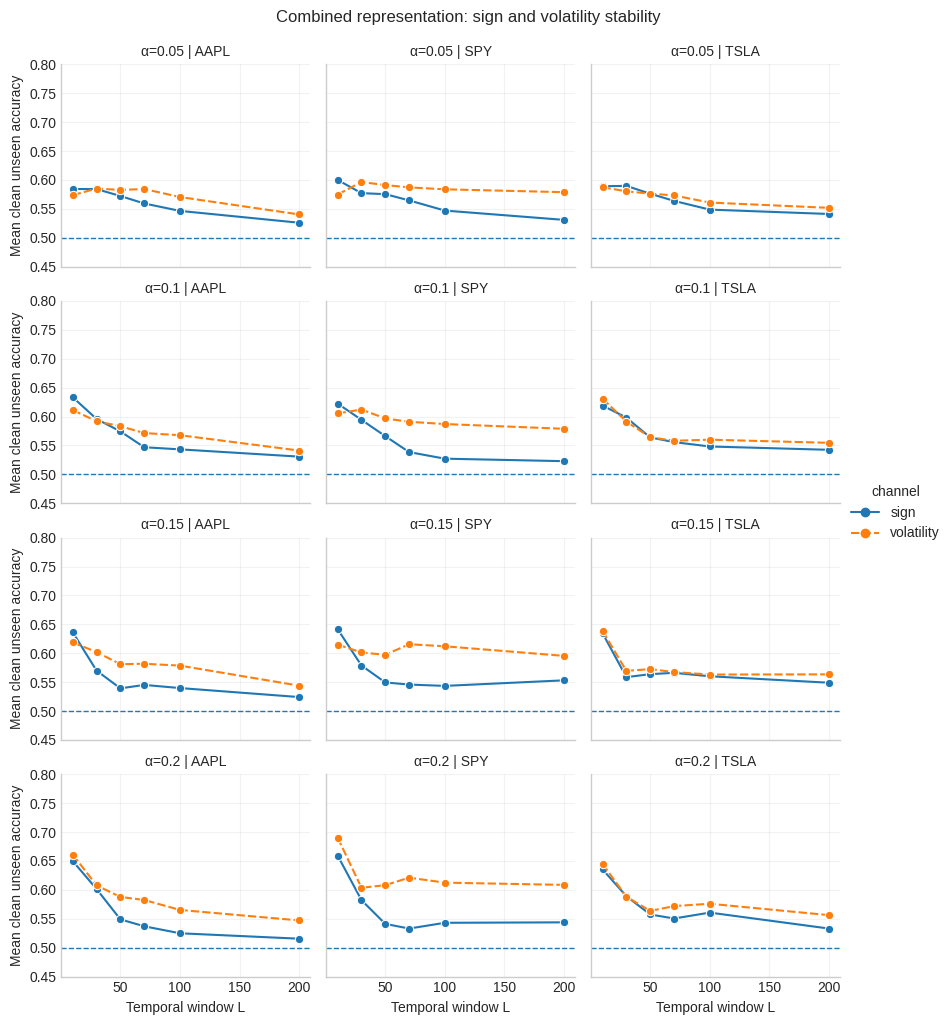

In [54]:
# =========================================================
# BLOCK 4.5.7: Combined representation stability
# =========================================================

combined_channel_plot = (
    combined_unseen_stability_summary[
        [
            "ticker",
            "window",
            "alpha_requested",
            "mean_sign_acc_restored",
            "mean_volatility_acc_restored"
        ]
    ]
    .melt(
        id_vars=[
            "ticker",
            "window",
            "alpha_requested"
        ],
        value_vars=[
            "mean_sign_acc_restored",
            "mean_volatility_acc_restored"
        ],
        var_name="channel",
        value_name="mean_accuracy"
    )
)

combined_channel_plot["channel"] = (combined_channel_plot["channel"].replace({"mean_sign_acc_restored": "sign", "mean_volatility_acc_restored": "volatility"}))

g = sns.relplot(
    data=combined_channel_plot,
    x="window",
    y="mean_accuracy",
    hue="channel",
    style="channel",
    col="ticker",
    row="alpha_requested",
    kind="line",
    marker="o",
    height=2.5,
    aspect=1.15
)

g.set_axis_labels("Temporal window L", "Mean clean unseen accuracy")
g.set_titles("α={row_name} | {col_name}")
for ax in g.axes.flat:
    ax.set_ylim(0.45, 0.80)
    ax.axhline(0.5,linestyle="--",linewidth=1)
    ax.grid(alpha=0.25)
g.fig.suptitle("Combined representation: sign and volatility stability", y=1.02)
plt.show()

**Figure analysis.**

The sign and volatility halves of the same combined state do not always behave identically.

- At short windows their retained accuracies are similar.
- At longer windows the volatility half is often preserved somewhat better than the sign half, especially for SPY and AAPL at moderate loads.
- TSLA shows a smaller separation between the two channels.

This suggests that the magnitude regime has somewhat more stable temporal structure than direction in several configurations. Even so, neither channel remains close to perfect stability, so the combined representation does not create robust unseen attractors.


### Comparison of sign-only, volatility-only, and combined representations


In [55]:
# =========================================================
# BLOCK 4.5.8: Representation comparison
# =========================================================

combined_comparison = (
    combined_unseen_stability_summary[
        [
            "ticker",
            "window",
            "alpha_requested",
            "mean_acc_restored"
        ]
    ]
    .copy()
)

combined_comparison["representation"] = ("sign+volatility")

all_representation_comparison = pd.concat([representation_comparison,combined_comparison],ignore_index=True)

representation_summary = (
    all_representation_comparison
    .groupby(
        [
            "representation",
            "window",
            "alpha_requested"
        ],
        as_index=False
    )
    .agg(mean_acc_restored=("mean_acc_restored","mean"))
)

representation_summary

,representation,window,alpha_requested,mean_acc_restored
0,sign+volatility,10,0.05,0.584869
1,sign+volatility,10,0.10,0.620478
2,sign+volatility,10,0.15,0.630830
3,sign+volatility,10,0.20,0.656883
4,sign+volatility,30,0.05,0.585511
...,...,...,...,...
67,volatility-only,100,0.20,0.579376
68,volatility-only,200,0.05,0.559466
69,volatility-only,200,0.10,0.558447
70,volatility-only,200,0.15,0.561068


**Table analysis.**

The combined representation can improve individual short-window configurations, but it does not produce a large or systematic increase in clean-unseen accuracy. As the temporal window grows, all three representations tend to settle in a moderate-accuracy regime rather than approaching stable recall.

### Section 4.5 summary

Adding a volatility channel enriches the market-state description and reveals that volatility can be more stable than direction on some scales. Nevertheless, simple feature concatenation does not solve unseen generalization. The next experiment therefore changes **which historical states are stored**, rather than adding more input channels.


## 4.6. Prototype-based memory selection

Uniform memory selection is reproducible but ignores the geometry of the training set. This section compares it with a prototype-based strategy.

- **Uniform memory:** historical windows are selected approximately evenly over time.
- **Prototype memory:** training windows are clustered, and the real historical pattern closest to each cluster centre is stored.

The number of stored patterns is kept the same within each comparison. The experiment therefore tests memory composition rather than memory size.


### Prototype selector


In [56]:
# =========================================================
# BLOCK 4.6.1: Prototype memory selection
# =========================================================

from sklearn.cluster import KMeans

def select_prototype_patterns(train_patterns, memory_size, random_state=42):
    """
    Group training patterns by similarity and select
    one real historical pattern
    closest to the center of each group.

    Returns:
    - prototype_patterns: selected patterns;
    - prototype_indices: their indices in train_patterns.
    """

    train_patterns = np.asarray(train_patterns)
    n_train = len(train_patterns)
    if memory_size > n_train:
        raise ValueError("memory_size exceeds number of training patterns.")

    if memory_size == 1:
        center = np.mean(train_patterns, axis=0)
        distances = np.sum((train_patterns - center) ** 2,axis=1)
        prototype_index = int(np.argmin(distances))
        return (train_patterns[[prototype_index]],np.array([prototype_index]))

    kmeans = KMeans(n_clusters=memory_size,random_state=random_state,n_init=10)
    cluster_ids = kmeans.fit_predict(train_patterns)
    prototype_indices = []
    for cluster_id in range(memory_size):
        cluster_indices = np.where(cluster_ids == cluster_id)[0]
        cluster_patterns = train_patterns[cluster_indices]
        center = kmeans.cluster_centers_[cluster_id]
        distances = np.sum((cluster_patterns - center) ** 2,axis=1)
        nearest_local_index = int(np.argmin(distances))
        prototype_indices.append(int(cluster_indices[nearest_local_index]))

    prototype_indices = np.array(prototype_indices,dtype=int)
    prototype_patterns = train_patterns[prototype_indices]

    return (prototype_patterns,prototype_indices)

The clustering stage is used only to identify representative regions of the training set. The Hopfield network still stores actual bipolar historical windows, not continuous cluster centres.


### Example of uniform and prototype selections


In [57]:
# =========================================================
# BLOCK 4.6.2: Example of memory selection
# =========================================================

example_ticker = "SPY"
example_window = 30
example_memory_size = 6

example_train_patterns = (unseen_data_store[(example_ticker, example_window)]["train_patterns"])
uniform_indices = (select_memory_pattern_indices(len(example_train_patterns),example_memory_size))

_, prototype_indices = (select_prototype_patterns(example_train_patterns,example_memory_size))

memory_selection_example = pd.DataFrame({
    "uniform_index": uniform_indices,
    "prototype_index": prototype_indices
})

memory_selection_example

,uniform_index,prototype_index
0,0,93
1,234,1159
2,469,1024
3,704,854
4,939,1169
5,1174,889


**Diagnostic analysis.** The example confirms that the two strategies select different historical indices. Uniform memory covers the timeline, whereas prototype memory is free to choose several states from similar periods if they represent distinct clusters in pattern space. This table validates the selection mechanism but is not itself a quality result.


### Clean-unseen experiment: uniform versus prototype memory


In [58]:
# =========================================================
# BLOCK 4.6.3: Uniform vs prototype memory
# Clean unseen patterns
# =========================================================

results_memory_selection = []

representation_data = {
    "sign-only": unseen_data_store,
    "sign+volatility": combined_data_store
}

for representation_id, (representation, data_store) in enumerate(representation_data.items()):
    for ticker_id, ticker in enumerate(TICKERS):
        for window_id, w in enumerate(WINDOWS):
            train_patterns = data_store[(ticker, w)]["train_patterns"]
            test_patterns = data_store[(ticker, w)]["test_patterns"]
            n_neurons = train_patterns.shape[1]
            for alpha_requested in ALPHA_LEVELS_UNSEEN:
                memory_size = max(1,int(np.round(alpha_requested * n_neurons)))
                if memory_size > len(train_patterns):
                    continue

                alpha_actual = memory_size / n_neurons
                uniform_memory_patterns = select_memory_patterns(train_patterns,memory_size)
                prototype_memory_patterns, _ = select_prototype_patterns(train_patterns,memory_size)

                memory_variants = {
                    "uniform": uniform_memory_patterns,
                    "prototype": prototype_memory_patterns
                }

                for memory_method, memory_patterns in memory_variants.items():
                    net = HopfieldNetwork(n_neurons=n_neurons)
                    net.train(memory_patterns)
                    for pattern_id, original_pattern in enumerate(test_patterns):
                        nearest_before_id, distance_before = (find_nearest_memory_pattern(original_pattern,memory_patterns))

                        # Paired update-order control:
                        # For the same test pattern, uniform and prototype memories
                        # receive the same sequence of random
                        # neuron update orders.
                        update_seed = int(
                            np.random.SeedSequence(
                                [
                                    42,
                                    representation_id,
                                    ticker_id,
                                    window_id,
                                    memory_size,
                                    pattern_id
                                ]
                            ).generate_state(1)[0]
                        )

                        np.random.seed(update_seed)

                        restored_pattern = net.run(original_pattern,max_sweeps=20)
                        nearest_after_id, distance_after = (find_nearest_memory_pattern(restored_pattern,memory_patterns))
                        hamming_restored = hamming_distance(original_pattern,restored_pattern)
                        exact_matches = np.all(memory_patterns == restored_pattern,axis=1)

                        results_memory_selection.append({
                            "representation": representation,
                            "ticker": ticker,
                            "window": w,
                            "n_neurons": n_neurons,
                            "alpha_requested": alpha_requested,
                            "alpha_actual": alpha_actual,
                            "memory_size": memory_size,
                            "memory_method": memory_method,
                            "pattern_id": pattern_id,

                            "clean_accuracy": accuracy(original_pattern,restored_pattern),
                            "clean_hamming": hamming_restored,
                            "exact_stable": hamming_restored == 0,
                            "distance_before": distance_before,
                            "normalized_distance_before": distance_before / n_neurons,
                            "distance_after": distance_after,
                            "normalized_distance_improvement": (distance_before - distance_after) / n_neurons,
                            "same_nearest_pattern": (nearest_before_id== nearest_after_id),
                            "exact_memory_match": bool(np.any(exact_matches))
                        })

df_memory_selection = pd.DataFrame(results_memory_selection)
df_memory_selection

,representation,ticker,window,n_neurons,alpha_requested,alpha_actual,memory_size,memory_method,pattern_id,clean_accuracy,clean_hamming,exact_stable,distance_before,normalized_distance_before,distance_after,normalized_distance_improvement,same_nearest_pattern,exact_memory_match
0,sign-only,SPY,10,10,0.05,0.1,1,uniform,0,0.6000,4,False,4,0.4000,0,0.4000,True,True
1,sign-only,SPY,10,10,0.05,0.1,1,uniform,1,0.7000,3,False,7,0.7000,10,-0.3000,True,False
2,sign-only,SPY,10,10,0.05,0.1,1,uniform,2,0.6000,4,False,6,0.6000,10,-0.4000,True,False
3,sign-only,SPY,10,10,0.05,0.1,1,uniform,3,0.6000,4,False,4,0.4000,0,0.4000,True,True
4,sign-only,SPY,10,10,0.05,0.1,1,uniform,4,0.6000,4,False,6,0.6000,10,-0.4000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65179,sign+volatility,TSLA,200,400,0.20,0.2,80,prototype,98,0.5600,176,False,179,0.4475,144,0.0875,False,False
65180,sign+volatility,TSLA,200,400,0.20,0.2,80,prototype,99,0.5625,175,False,165,0.4125,127,0.0950,False,False
65181,sign+volatility,TSLA,200,400,0.20,0.2,80,prototype,100,0.5325,187,False,174,0.4350,145,0.0725,False,False
65182,sign+volatility,TSLA,200,400,0.20,0.2,80,prototype,101,0.5300,188,False,181,0.4525,132,0.1225,False,False


**Raw-result note.** The experiment produces 65,184 trial-level rows. Each row describes one clean unseen test pattern under a fixed representation, asset, window, load, and memory-selection method. Uniform and prototype networks are compared under matched stochastic update conditions.


### Configuration-level summary


In [59]:
# =========================================================
# BLOCK 4.6.4: Memory-selection summary
# =========================================================

memory_selection_summary = (
    df_memory_selection
    .groupby(
        [
            "representation",
            "ticker",
            "window",
            "n_neurons",
            "alpha_requested",
            "alpha_actual",
            "memory_size",
            "memory_method"
        ],
        as_index=False
    )
    .agg(
        n_test_patterns=("pattern_id","count"),
        mean_clean_accuracy=("clean_accuracy","mean"),
        mean_clean_hamming=("clean_hamming","mean"),
        exact_stability_rate=("exact_stable","mean"),
        mean_distance_before=("distance_before","mean"),
        mean_normalized_distance_before=("normalized_distance_before","mean"),
        mean_distance_after=("distance_after","mean"),
        mean_normalized_distance_improvement=("normalized_distance_improvement","mean"),
        same_nearest_pattern_rate=("same_nearest_pattern","mean"),
        exact_memory_match_rate=("exact_memory_match","mean"
        )
    )
)

memory_selection_summary

,representation,ticker,window,n_neurons,alpha_requested,alpha_actual,memory_size,memory_method,n_test_patterns,mean_clean_accuracy,mean_clean_hamming,exact_stability_rate,mean_distance_before,mean_normalized_distance_before,mean_distance_after,mean_normalized_distance_improvement,same_nearest_pattern_rate,exact_memory_match_rate
0,sign+volatility,AAPL,10,20,0.05,0.05,1,prototype,293,0.589590,8.208191,0.0,9.566553,0.478328,9.010239,0.027816,1.000000,0.549488
1,sign+volatility,AAPL,10,20,0.05,0.05,1,uniform,293,0.579010,8.419795,0.0,9.935154,0.496758,9.829352,0.005290,1.000000,0.508532
2,sign+volatility,AAPL,10,20,0.10,0.10,2,prototype,293,0.636348,7.273038,0.0,8.061433,0.403072,2.201365,0.293003,1.000000,0.559727
3,sign+volatility,AAPL,10,20,0.10,0.10,2,uniform,293,0.622355,7.552901,0.0,8.767918,0.438396,4.880546,0.194369,0.901024,0.511945
4,sign+volatility,AAPL,10,20,0.15,0.15,3,prototype,293,0.622014,7.559727,0.0,7.552901,0.377645,2.744027,0.240444,0.655290,0.262799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,sign-only,TSLA,200,200,0.10,0.10,20,uniform,103,0.555583,88.883495,0.0,86.805825,0.434029,53.126214,0.168398,0.252427,0.038835
284,sign-only,TSLA,200,200,0.15,0.15,30,prototype,103,0.555097,88.980583,0.0,85.728155,0.428641,58.417476,0.136553,0.106796,0.000000
285,sign-only,TSLA,200,200,0.15,0.15,30,uniform,103,0.553398,89.320388,0.0,85.291262,0.426456,55.029126,0.151311,0.145631,0.000000
286,sign-only,TSLA,200,200,0.20,0.20,40,prototype,103,0.550485,89.902913,0.0,84.932039,0.424660,58.669903,0.131311,0.106796,0.000000


**Table analysis.**

Prototype selection can improve both historical coverage and clean-unseen retained accuracy in individual configurations, but the direction of the effect is not uniform. For example, short combined AAPL patterns at low load benefit from prototype memory, while other loads show much smaller or reversed differences.

A paired comparison is therefore required before drawing an overall conclusion.


### Paired prototype-minus-uniform comparison


In [60]:
# =========================================================
# BLOCK 4.6.5: Prototype minus uniform comparison
# =========================================================

memory_selection_comparison = (
    memory_selection_summary
    .pivot(
        index=[
            "representation",
            "ticker",
            "window",
            "alpha_requested"
        ],
        columns="memory_method",
        values=[
            "mean_clean_accuracy",
            "mean_normalized_distance_before",
            "mean_normalized_distance_improvement",
            "exact_memory_match_rate"
        ]
    )
)

memory_selection_comparison.columns = [
    f"{metric}_{method}"
    for metric, method
    in memory_selection_comparison.columns
]

memory_selection_comparison = (memory_selection_comparison.reset_index())
memory_selection_comparison["prototype_minus_uniform_accuracy"] = (memory_selection_comparison["mean_clean_accuracy_prototype"] - memory_selection_comparison["mean_clean_accuracy_uniform"])
memory_selection_comparison["prototype_minus_uniform_initial_distance"] = (memory_selection_comparison["mean_normalized_distance_before_prototype"] - memory_selection_comparison["mean_normalized_distance_before_uniform"])
memory_selection_comparison["prototype_minus_uniform_distance_improvement"] = (memory_selection_comparison["mean_normalized_distance_improvement_prototype"] - memory_selection_comparison["mean_normalized_distance_improvement_uniform"])
memory_selection_comparison["prototype_minus_uniform_exact_match"] = (memory_selection_comparison["exact_memory_match_rate_prototype"] - memory_selection_comparison["exact_memory_match_rate_uniform"])

memory_selection_comparison

,representation,ticker,window,alpha_requested,mean_clean_accuracy_prototype,mean_clean_accuracy_uniform,mean_normalized_distance_before_prototype,mean_normalized_distance_before_uniform,mean_normalized_distance_improvement_prototype,mean_normalized_distance_improvement_uniform,exact_memory_match_rate_prototype,exact_memory_match_rate_uniform,prototype_minus_uniform_accuracy,prototype_minus_uniform_initial_distance,prototype_minus_uniform_distance_improvement,prototype_minus_uniform_exact_match
0,sign+volatility,AAPL,10,0.05,0.589590,0.579010,0.478328,0.496758,0.027816,0.005290,0.549488,0.508532,0.010580,-0.018430,0.022526,0.040956
1,sign+volatility,AAPL,10,0.10,0.636348,0.622355,0.403072,0.438396,0.293003,0.194369,0.559727,0.511945,0.013993,-0.035324,0.098635,0.047782
2,sign+volatility,AAPL,10,0.15,0.622014,0.627133,0.377645,0.405290,0.240444,0.242150,0.262799,0.430034,-0.005119,-0.027645,-0.001706,-0.167235
3,sign+volatility,AAPL,10,0.20,0.626451,0.653072,0.362969,0.385495,0.236007,0.213823,0.255973,0.378840,-0.026621,-0.022526,0.022184,-0.122867
4,sign+volatility,AAPL,30,0.05,0.591819,0.583394,0.433394,0.444811,0.210562,0.180525,0.373626,0.402930,0.008425,-0.011416,0.030037,-0.029304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,sign-only,TSLA,100,0.20,0.557833,0.580394,0.407833,0.405764,0.140394,0.167291,0.000000,0.009852,-0.022562,0.002069,-0.026897,-0.009852
140,sign-only,TSLA,200,0.05,0.555340,0.550922,0.442670,0.442184,0.210194,0.238544,0.378641,0.378641,0.004417,0.000485,-0.028350,0.000000
141,sign-only,TSLA,200,0.10,0.554903,0.555583,0.434223,0.434029,0.172427,0.168398,0.029126,0.038835,-0.000680,0.000194,0.004029,-0.009709
142,sign-only,TSLA,200,0.15,0.555097,0.553398,0.428641,0.426456,0.136553,0.151311,0.000000,0.000000,0.001699,0.002184,-0.014757,0.000000


**Table analysis.**

The paired differences are interpreted according to the metric:

- positive accuracy difference favours prototype memory;
- negative initial-distance difference favours prototype memory because lower distance means better coverage;
- positive distance-improvement difference means stronger movement toward stored memory;
- positive exact-match difference means more frequent exact convergence to a stored pattern.

The signs vary across loads and representations. Prototype memory is therefore not uniformly superior, although it can improve coverage substantially in low-load settings.


### Historical coverage before Hopfield dynamics


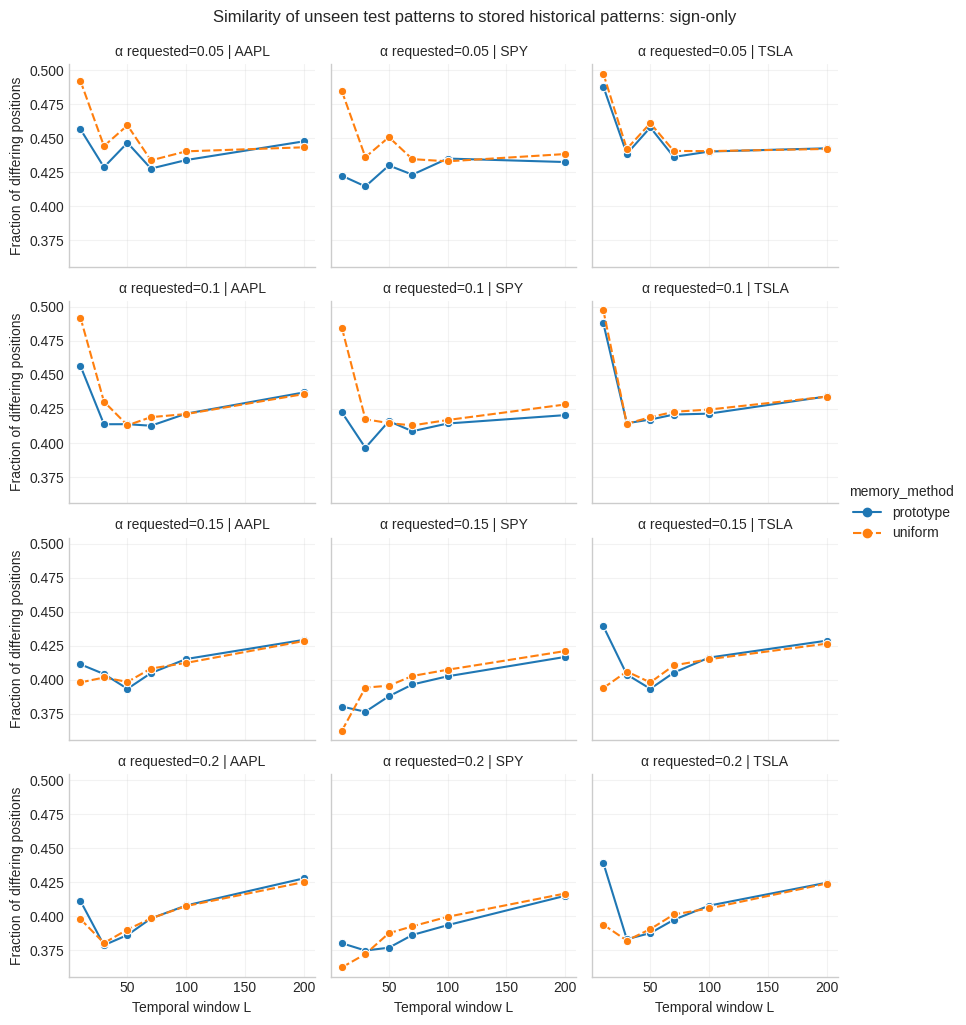

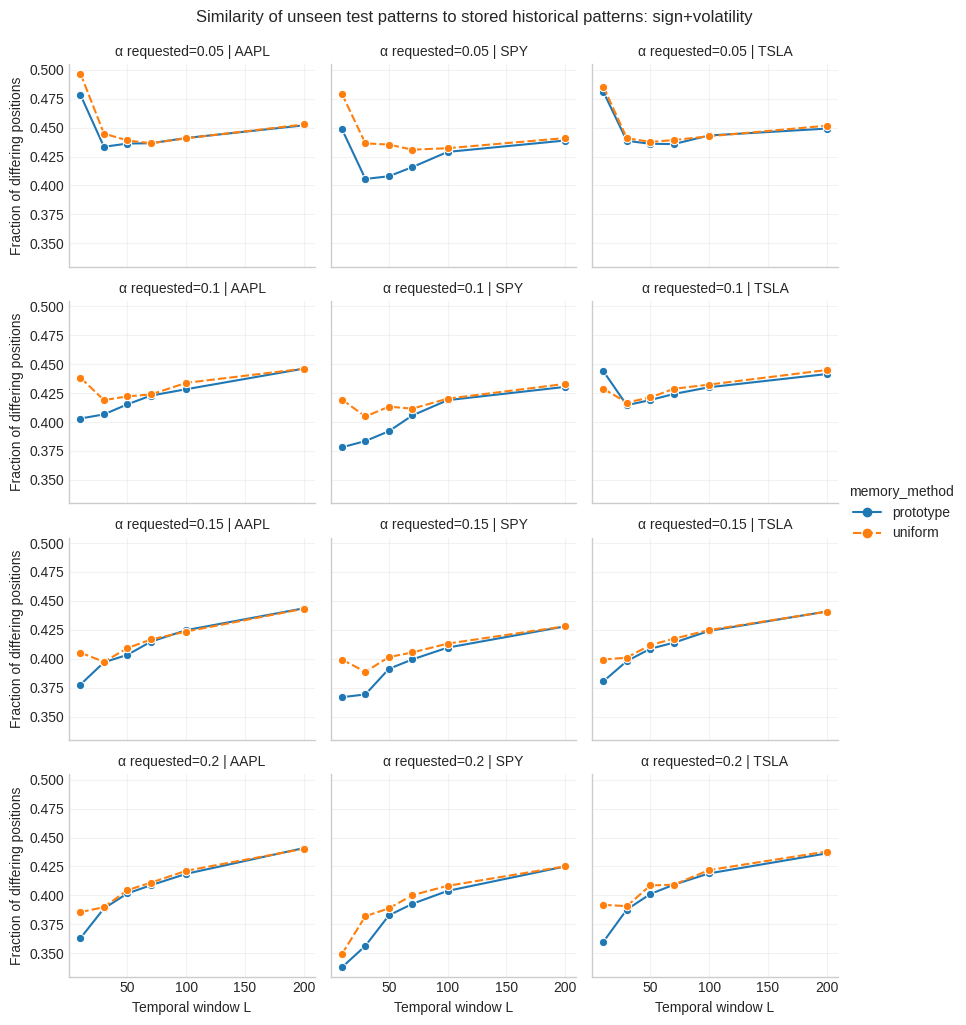

In [61]:
# =========================================================
# BLOCK 4.6.6: Initial similarity to stored patterns
# =========================================================

for representation in ["sign-only","sign+volatility"]:
    plot_data = memory_selection_summary[memory_selection_summary["representation"]== representation]
    g = sns.relplot(
        data=plot_data,
        x="window",
        y="mean_normalized_distance_before",
        hue="memory_method",
        style="memory_method",
        col="ticker",
        row="alpha_requested",
        kind="line",
        marker="o",
        height=2.5,
        aspect=1.15
    )

    g.set_axis_labels("Temporal window L","Fraction of differing positions")
    g.set_titles("α requested={row_name} | {col_name}")
    for ax in g.axes.flat:
        ax.grid(alpha=0.25)
    g.fig.suptitle(
        f"Similarity of unseen test patterns "
        f"to stored historical patterns: {representation}",
        y=1.02
    )
    plt.show()


**Figure analysis.**

These plots isolate the quality of the **stored memory set itself**, before any Hopfield dynamics is applied. Lower normalized Hamming distance means that an unseen test pattern has a closer historical analogue among the stored memories.

For sign-only patterns, prototype memory improves coverage most clearly at low loads and short-to-medium windows; the advantage becomes small or reverses in some higher-load cases.

For the combined sign + volatility representation, prototype memory more consistently reduces the nearest-memory distance, especially for AAPL and SPY at low and moderate loads. The benefit shrinks as window length increases.

Thus, clustering can produce a more representative finite memory, but better coverage does not automatically imply better reconstruction.


### Clean unseen accuracy after Hopfield dynamics


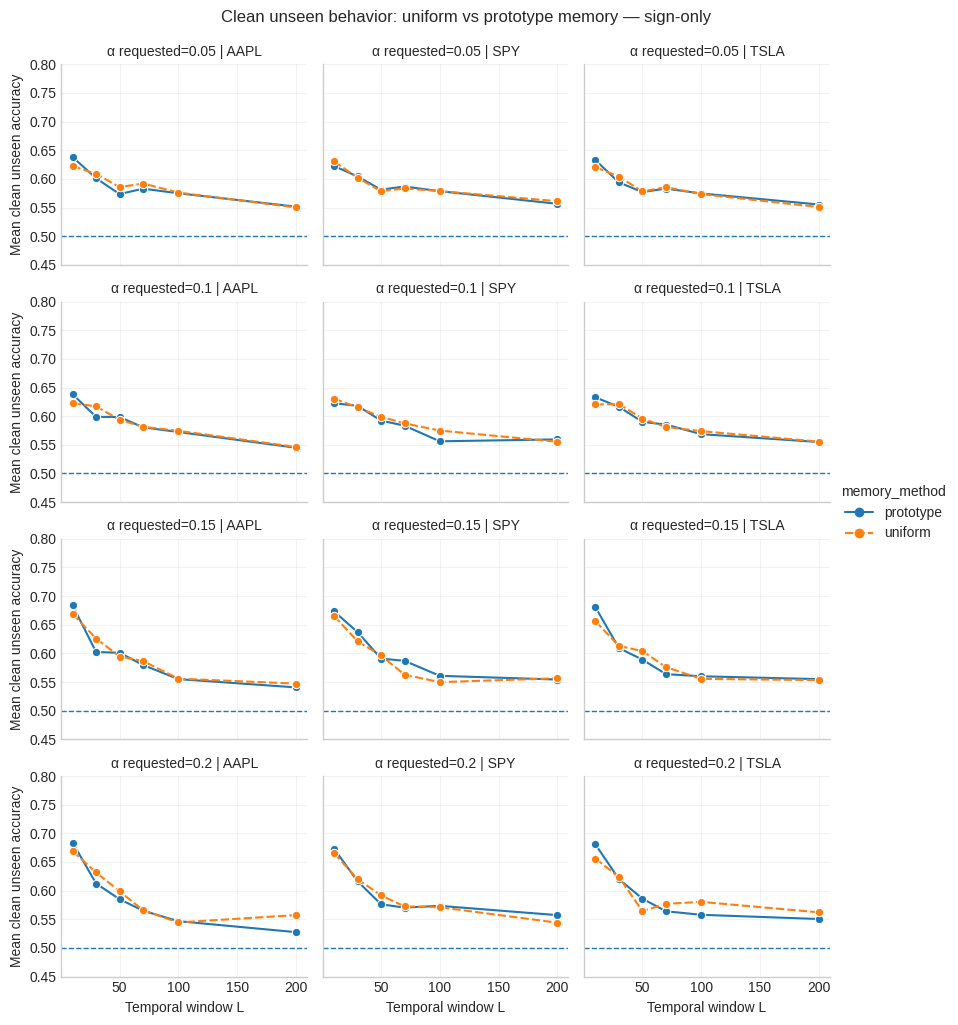

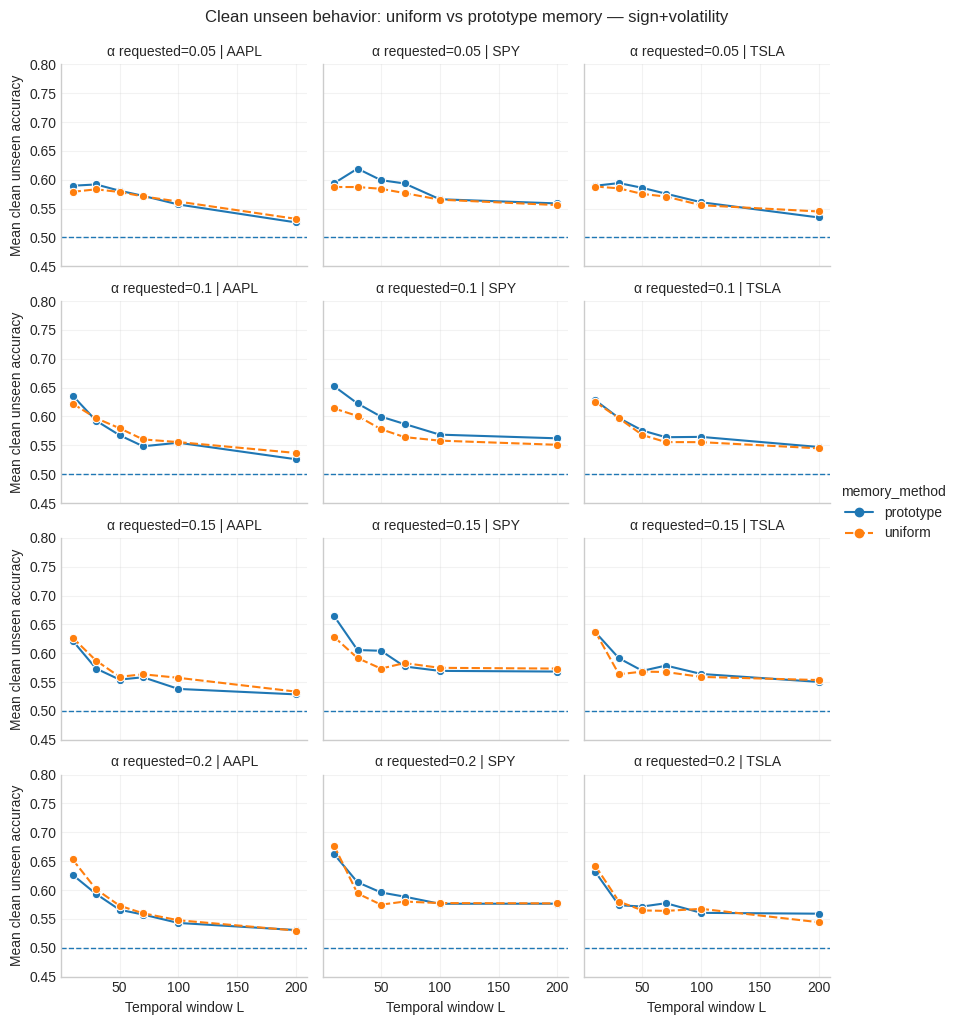

In [62]:
# =========================================================
# BLOCK 4.6.7: Clean unseen accuracy
# =========================================================

for representation in ["sign-only","sign+volatility"]:
    plot_data = memory_selection_summary[memory_selection_summary["representation"]== representation]
    g = sns.relplot(
        data=plot_data,
        x="window",
        y="mean_clean_accuracy",
        hue="memory_method",
        style="memory_method",
        col="ticker",
        row="alpha_requested",
        kind="line",
        marker="o",
        height=2.5,
        aspect=1.15
    )

    g.set_axis_labels("Temporal window L","Mean clean unseen accuracy")
    g.set_titles("α requested={row_name} | {col_name}")

    for ax in g.axes.flat:
        ax.set_ylim(0.45, 0.80)
        ax.axhline(0.5,linestyle="--",linewidth=1)
        ax.grid(alpha=0.25)

    g.fig.suptitle(
        f"Clean unseen behavior: "
        f"uniform vs prototype memory — {representation}",
        y=1.02
    )
    plt.show()

**Figure analysis.**

After Hopfield dynamics, the prototype and uniform curves are usually much closer than their pre-dynamics coverage curves.

For sign-only memory, small advantages alternate between the two strategies and no stable direction emerges. For the combined representation, prototype memory produces modest gains in several low-load configurations, particularly at short and medium scales, but the effect remains small and disappears or reverses elsewhere.

The important distinction is that **improving the stored sample does not proportionally improve the network dynamics**. The attractor geometry created by Hebbian superposition remains a limiting factor.


### Overall prototype-memory effect


In [63]:
# =========================================================
# BLOCK 4.6.8: Overall prototype-memory effect
# =========================================================

prototype_effect_summary = (
    memory_selection_comparison
    .groupby(
        [
            "representation",
            "alpha_requested"
        ],
        as_index=False
    )
    .agg(
        mean_accuracy_difference=(
            "prototype_minus_uniform_accuracy",
            "mean"
        ),

        mean_initial_distance_difference=(
            "prototype_minus_uniform_initial_distance",
            "mean"
        ),

        mean_distance_improvement_difference=(
            "prototype_minus_uniform_distance_improvement",
            "mean"
        ),

        mean_exact_match_difference=(
            "prototype_minus_uniform_exact_match",
            "mean"
        )
    )
)

prototype_effect_summary

,representation,alpha_requested,mean_accuracy_difference,mean_initial_distance_difference,mean_distance_improvement_difference,mean_exact_match_difference
0,sign+volatility,0.05,0.005861,-0.008642,0.006237,-0.025494
1,sign+volatility,0.10,0.007288,-0.008566,-0.016441,-0.033622
2,sign+volatility,0.15,0.002970,-0.007513,0.000903,-0.038420
3,sign+volatility,0.20,-0.000229,-0.007376,-0.005409,-0.034209
4,sign-only,0.05,-0.000725,-0.011780,0.044678,0.065815
5,sign-only,0.10,-0.001827,-0.009347,0.024037,0.015041
6,sign-only,0.15,0.001945,0.001372,-0.030457,0.003391
7,sign-only,0.20,-0.002708,0.002690,-0.025764,0.002789


**Table analysis.**

The aggregate paired summary makes the pattern clearer.

For `sign+volatility`, prototype selection reduces the initial normalized distance to memory by roughly 0.7–0.9 percentage points across the tested loads. For `sign-only`, the coverage advantage is concentrated at the lowest loads and disappears at higher load.

Clean-unseen accuracy changes much less. The combined representation gains only a few tenths of a percentage point on average at several low-load settings, while sign-only differences stay near zero and change sign.

Exact matching and movement-to-memory metrics are also mixed. Therefore prototype selection improves **coverage** more consistently than it improves the actual Hopfield output.

### Section 4.6 summary

Prototype selection makes the finite memory more representative in several important configurations, especially for combined sign + volatility patterns. However, the improvement is too small and too inconsistent to solve the unseen-stability problem. The decisive test is therefore whether the better memory helps when unseen test patterns are actually corrupted.


## 4.7. Noisy unseen reconstruction

This is the principal reconstruction experiment.

A clean unseen test pattern $X$ is artificially corrupted:

$$
X \rightarrow X_{\mathrm{noisy}},
$$

then passed through the trained network:

$$
X_{\mathrm{noisy}}
\rightarrow
\mathrm{Hopfield}
\rightarrow
X_{\mathrm{restored}}.
$$

The result is compared with the **original clean unseen pattern**, not with a stored memory.

The main metric is

$$
\Delta A =
A(X_{\mathrm{restored}},X)
-
A(X_{\mathrm{noisy}},X).
$$

Positive $\Delta A$ means that Hopfield corrected more errors than it introduced. Negative $\Delta A$ means that the final state is farther from the true clean test pattern than the corrupted input was.


### Experiment settings

Twenty clean test patterns are selected approximately uniformly across each test interval. Actual memory load and actual corruption fraction are used to avoid duplicate configurations caused by integer rounding. Uniform and prototype memories receive matched test patterns, matched bit corruptions, and matched random update-order sequences.


In [64]:
# =========================================================
# BLOCK 4.7.1: Noisy unseen reconstruction settings
# =========================================================

NOISE_LEVELS_UNSEEN = np.arange(0.05, 0.41, 0.05).tolist()

N_TEST_PATTERNS_UNSEEN_NOISE = 20
N_REPEATS_UNSEEN_NOISE = 3

NOISY_UNSEEN_RANDOM_STATE = 42
MAX_SWEEPS_UNSEEN_NOISE = 100


def select_evenly_spaced_test_indices(n_test, n_selected):
    """
    Selects test-pattern indices approximately evenly
    across the whole test interval.
    """
    n_selected = min(n_selected, n_test)
    return np.linspace(0,n_test - 1,n_selected,dtype=int)


def build_unique_level_configs(n_items, requested_levels):
    """
    Converts requested fractional levels into unique integer counts.

    Several requested levels may correspond to the same integer count
    for short vectors. In that case only one actual experimental
    condition is retained.

    For each integer count, the requested level closest to the resulting
    actual fraction is retained only as a descriptive reference.
    """
    configs = {}
    for requested_level in requested_levels:
        count = max(1,int(np.round(requested_level * n_items)))
        count = min(count, n_items)
        actual_level = count / n_items
        candidate = {
            "requested_level": requested_level,
            "count": count,
            "actual_level": actual_level
        }

        if count not in configs:
            configs[count] = candidate
        else:
            current = configs[count]
            if (abs(requested_level - actual_level) < abs(current["requested_level"]- actual_level)):
                configs[count] = candidate

    return [configs[count]for count in sorted(configs)]


def inject_noise_by_flips(pattern, n_flips, rng):
    """
    Flips exactly n_flips elements of a bipolar pattern.
    """
    noisy = pattern.copy()
    flip_indices = rng.choice(len(pattern),size=n_flips,replace=False)
    noisy[flip_indices] *= -1
    actual_noise = n_flips / len(pattern)

    return noisy, actual_noise


def run_hopfield_with_diagnostics(net,initial_state,rng,max_sweeps=100):
    """
    Runs the same asynchronous Hopfield dynamics as HopfieldNetwork.run,
    but additionally reports convergence and the number of sweeps used.
    """
    state = initial_state.copy().astype(float)
    for sweep_id in range(1, max_sweeps + 1):
        old_state = state.copy()
        indices = rng.permutation(net.n)
        for idx in indices:
            local_field = np.dot(net.W[idx],state)
            if local_field > 0:
                state[idx] = 1.0
            elif local_field < 0:
                state[idx] = -1.0
        if np.array_equal(state,old_state):
            return state, True, sweep_id

    return state, False, max_sweeps

### Selected test-pattern coverage


In [65]:
# =========================================================
# BLOCK 4.7.2: Test-pattern selection
# =========================================================

noisy_unseen_test_selection = []

for representation, data_store in {
    "sign-only": unseen_data_store,
    "sign+volatility": combined_data_store
}.items():

    for ticker in TICKERS:
        for w in WINDOWS:
            test_patterns = data_store[(ticker, w)]["test_patterns"]
            selected_indices = (select_evenly_spaced_test_indices(len(test_patterns),N_TEST_PATTERNS_UNSEEN_NOISE))
            noisy_unseen_test_selection.append({
                "representation": representation,
                "ticker": ticker,
                "window": w,
                "available_test_patterns": len(test_patterns),
                "selected_test_patterns": len(selected_indices),
                "first_selected_index": int(selected_indices[0]),
                "last_selected_index": int(selected_indices[-1])
            })

noisy_unseen_test_selection_df = pd.DataFrame(noisy_unseen_test_selection)
noisy_unseen_test_selection_df

,representation,ticker,window,available_test_patterns,selected_test_patterns,first_selected_index,last_selected_index
0,sign-only,SPY,10,293,20,0,292
1,sign-only,SPY,30,273,20,0,272
2,sign-only,SPY,50,253,20,0,252
3,sign-only,SPY,70,233,20,0,232
4,sign-only,SPY,100,203,20,0,202
5,sign-only,SPY,200,103,20,0,102
6,sign-only,AAPL,10,293,20,0,292
7,sign-only,AAPL,30,273,20,0,272
8,sign-only,AAPL,50,253,20,0,252
9,sign-only,AAPL,70,233,20,0,232


**Diagnostic analysis.** The table verifies that the selected test sample is available for every asset and window length. The sample is used only for evaluation and never for memory formation.


### Main noisy-unseen reconstruction experiment


In [66]:
# =========================================================
# BLOCK 4.7.3: Noisy unseen reconstruction
# Uniform vs prototype memory
# =========================================================

results_noisy_unseen = []
representation_data_noisy = {
    "sign-only": unseen_data_store,
    "sign+volatility": combined_data_store
}

for representation_id, (representation,data_store) in enumerate(representation_data_noisy.items()):
    for ticker_id, ticker in enumerate(TICKERS):
        for window_id, w in enumerate(WINDOWS):
            train_patterns = data_store[(ticker, w)]["train_patterns"]
            test_patterns = data_store[(ticker, w)]["test_patterns"]
            n_neurons = train_patterns.shape[1]
            selected_test_indices = (select_evenly_spaced_test_indices(len(test_patterns),N_TEST_PATTERNS_UNSEEN_NOISE))
            memory_configs = (build_unique_level_configs(n_neurons,ALPHA_LEVELS_UNSEEN))

            noise_configs = (build_unique_level_configs(n_neurons,NOISE_LEVELS_UNSEEN))
            for memory_config in memory_configs:
                memory_size = (memory_config["count"])
                alpha_requested_reference = (memory_config["requested_level"])
                alpha_actual = (memory_config["actual_level"])
                if memory_size > len(train_patterns):
                    continue

                uniform_memory_patterns = (select_memory_patterns(train_patterns,memory_size))
                (prototype_memory_patterns,_) = select_prototype_patterns(train_patterns,memory_size)

                memory_variants = {
                    "uniform":uniform_memory_patterns,
                    "prototype":prototype_memory_patterns
                }

                networks = {}

                for (memory_method,memory_patterns) in memory_variants.items():
                    net = HopfieldNetwork(n_neurons=n_neurons)
                    net.train(memory_patterns)
                    networks[memory_method] = net

                for pattern_id in selected_test_indices:
                    original_pattern = (test_patterns[pattern_id])
                    for noise_config in noise_configs:
                        n_flips = (noise_config["count"])
                        requested_noise_reference = (noise_config["requested_level"])
                        actual_noise = (noise_config["actual_level"])

                        for repeat_id in range(N_REPEATS_UNSEEN_NOISE):
                            # Same corrupted input for all
                            # memory sizes and memory methods.
                            noise_seed = int(
                                np.random.SeedSequence(
                                    [
                                        NOISY_UNSEEN_RANDOM_STATE,
                                        representation_id,
                                        ticker_id,
                                        window_id,
                                        int(pattern_id),
                                        n_flips,
                                        repeat_id,
                                        0
                                    ]
                                ).generate_state(1)[0]
                            )

                            noise_rng = (np.random.default_rng(noise_seed))
                            (noisy_pattern,actual_noise_check) = inject_noise_by_flips(original_pattern,n_flips,noise_rng)

                            if not np.isclose(actual_noise,actual_noise_check):
                                raise RuntimeError("Actual noise mismatch.")

                            acc_noisy = accuracy(original_pattern,noisy_pattern)
                            hamming_noisy = (hamming_distance(original_pattern,noisy_pattern))

                            for (memory_method,memory_patterns) in memory_variants.items():
                                # Same sequence of update orders
                                # for all memory methods and loads.
                                update_seed = int(np.random.SeedSequence(
                                        [
                                            NOISY_UNSEEN_RANDOM_STATE,
                                            representation_id,
                                            ticker_id,
                                            window_id,
                                            int(pattern_id),
                                            n_flips,
                                            repeat_id,
                                            1
                                        ]
                                    ).generate_state(1)[0]
                                )

                                update_rng = (np.random.default_rng(update_seed))
                                (restored_pattern,converged,sweeps_used) = (
                                    run_hopfield_with_diagnostics(
                                        networks[memory_method],
                                        noisy_pattern,
                                        update_rng,
                                        max_sweeps=MAX_SWEEPS_UNSEEN_NOISE
                                    )
                                )

                                acc_restored = accuracy(original_pattern,restored_pattern)

                                hamming_restored = (hamming_distance(original_pattern,restored_pattern))
                                (nearest_noisy_id,distance_noisy_to_memory) = (find_nearest_memory_pattern(noisy_pattern,memory_patterns))
                                (nearest_restored_id,distance_restored_to_memory) = (find_nearest_memory_pattern(restored_pattern,memory_patterns))

                                results_noisy_unseen.append({
                                    "representation":representation,
                                    "ticker":ticker,
                                    "window":w,
                                    "n_neurons":n_neurons,
                                    "alpha_requested_reference":alpha_requested_reference,
                                    "alpha_actual":alpha_actual,
                                    "memory_size":memory_size,
                                    "memory_method":memory_method,
                                    "pattern_id":int(pattern_id),
                                    "repeat_id":repeat_id,
                                    "requested_noise_reference":requested_noise_reference,
                                    "n_flips":n_flips,
                                    "actual_noise":actual_noise,
                                    "acc_noisy":acc_noisy,
                                    "acc_restored":acc_restored,
                                    "delta_accuracy":(acc_restored- acc_noisy),
                                    "hamming_noisy":hamming_noisy,
                                    "hamming_restored":hamming_restored,
                                    "delta_hamming":(hamming_noisy- hamming_restored),
                                    "exact_recovery":(hamming_restored== 0),
                                    "converged":converged,
                                    "sweeps_used":sweeps_used,
                                    "nearest_noisy_id":nearest_noisy_id,
                                    "nearest_restored_id":nearest_restored_id,
                                    "same_nearest_memory":(nearest_noisy_id==nearest_restored_id),
                                    "normalized_distance_noisy_to_memory":(distance_noisy_to_memory / n_neurons),
                                    "normalized_distance_restored_to_memory":(distance_restored_to_memory/ n_neurons)
                                })


df_noisy_unseen = pd.DataFrame(results_noisy_unseen)
df_noisy_unseen

,representation,ticker,window,n_neurons,alpha_requested_reference,alpha_actual,memory_size,memory_method,pattern_id,repeat_id,...,hamming_restored,delta_hamming,exact_recovery,converged,sweeps_used,nearest_noisy_id,nearest_restored_id,same_nearest_memory,normalized_distance_noisy_to_memory,normalized_distance_restored_to_memory
0,sign-only,SPY,10,10,0.1,0.1,1,uniform,0,0,...,6,-5,False,True,2,0,0,True,0.500,1.0000
1,sign-only,SPY,10,10,0.1,0.1,1,prototype,0,0,...,6,-5,False,True,2,0,0,True,0.500,1.0000
2,sign-only,SPY,10,10,0.1,0.1,1,uniform,0,1,...,4,-3,False,True,2,0,0,True,0.300,0.0000
3,sign-only,SPY,10,10,0.1,0.1,1,prototype,0,1,...,4,-3,False,True,2,0,0,True,0.300,0.0000
4,sign-only,SPY,10,10,0.1,0.1,1,uniform,0,2,...,4,-3,False,True,2,0,0,True,0.500,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129595,sign+volatility,TSLA,200,400,0.2,0.2,80,prototype,102,0,...,205,-45,False,True,23,69,41,False,0.440,0.3800
129596,sign+volatility,TSLA,200,400,0.2,0.2,80,uniform,102,1,...,199,-39,False,True,13,41,10,False,0.430,0.2350
129597,sign+volatility,TSLA,200,400,0.2,0.2,80,prototype,102,1,...,192,-32,False,True,12,50,58,False,0.450,0.2725
129598,sign+volatility,TSLA,200,400,0.2,0.2,80,uniform,102,2,...,188,-28,False,True,13,6,10,False,0.435,0.2975


**Raw-result analysis.** The trial-level output contains both representations, all assets, all windows, realized memory loads, both memory-selection methods, repeated corruptions, convergence information, and accuracy relative to the true clean test target. This is the complete evidence base for the reconstruction result.


### Convergence diagnostics


In [67]:
# =========================================================
# BLOCK 4.7.4: Convergence diagnostics
# =========================================================

convergence_summary = (
    df_noisy_unseen
    .groupby(["representation","window","memory_method"],as_index=False)
    .agg(
        n_runs=("converged","size"),
        convergence_rate=("converged","mean"),
        mean_sweeps_used=("sweeps_used","mean"),
        max_sweeps_used=("sweeps_used","max")
    )
)

display(convergence_summary)
non_converged_runs = (df_noisy_unseen[~df_noisy_unseen["converged"]])
print("Non-converged runs:",len(non_converged_runs))

if len(non_converged_runs) > 0:
    raise RuntimeError(
        "Some Hopfield runs did not converge. "
        "Increase MAX_SWEEPS_UNSEEN_NOISE "
        "before analysing reconstruction quality."
    )

,representation,window,memory_method,n_runs,convergence_rate,mean_sweeps_used,max_sweeps_used
0,sign+volatility,10,prototype,5760,1.0,2.153472,4
1,sign+volatility,10,uniform,5760,1.0,2.117188,5
2,sign+volatility,30,prototype,5760,1.0,3.590972,13
3,sign+volatility,30,uniform,5760,1.0,3.630556,12
4,sign+volatility,50,prototype,5760,1.0,5.012326,16
5,sign+volatility,50,uniform,5760,1.0,5.073785,17
6,sign+volatility,70,prototype,5760,1.0,5.886632,23
7,sign+volatility,70,uniform,5760,1.0,6.319444,21
8,sign+volatility,100,prototype,5760,1.0,7.156597,27
9,sign+volatility,100,uniform,5760,1.0,7.991493,28


Non-converged runs: 0


**Diagnostic analysis.** All reported runs converge within the configured sweep limit. The negative reconstruction results therefore cannot be explained by premature termination of the Hopfield dynamics.


### Configuration-level reconstruction summary


In [68]:
# =========================================================
# BLOCK 4.7.5: Reconstruction summary
# =========================================================

noisy_unseen_summary = (
    df_noisy_unseen
    .groupby(
        [
            "representation",
            "ticker",
            "window",
            "n_neurons",
            "alpha_actual",
            "memory_size",
            "memory_method",
            "actual_noise",
            "n_flips"
        ],
        as_index=False
    )
    .agg(
        n_trials=("delta_accuracy","size"),
        mean_acc_noisy=("acc_noisy","mean"),
        mean_acc_restored=("acc_restored","mean"),
        mean_delta_accuracy=("delta_accuracy","mean"),
        mean_hamming_noisy=("hamming_noisy","mean"),
        mean_hamming_restored=("hamming_restored","mean"),
        mean_delta_hamming=("delta_hamming","mean"),
        exact_recovery_rate=("exact_recovery","mean"),
        mean_sweeps_used=("sweeps_used","mean")
    )
)

noisy_unseen_summary

,representation,ticker,window,n_neurons,alpha_actual,memory_size,memory_method,actual_noise,n_flips,n_trials,mean_acc_noisy,mean_acc_restored,mean_delta_accuracy,mean_hamming_noisy,mean_hamming_restored,mean_delta_hamming,exact_recovery_rate,mean_sweeps_used
0,sign+volatility,AAPL,10,20,0.05,1,prototype,0.05,1,60,0.95,0.555000,-0.395000,1.0,8.900000,-7.900000,0.0,2.000000
1,sign+volatility,AAPL,10,20,0.05,1,prototype,0.10,2,60,0.90,0.541667,-0.358333,2.0,9.166667,-7.166667,0.0,2.000000
2,sign+volatility,AAPL,10,20,0.05,1,prototype,0.15,3,60,0.85,0.555000,-0.295000,3.0,8.900000,-5.900000,0.0,2.000000
3,sign+volatility,AAPL,10,20,0.05,1,prototype,0.20,4,60,0.80,0.530000,-0.270000,4.0,9.400000,-5.400000,0.0,2.000000
4,sign+volatility,AAPL,10,20,0.05,1,prototype,0.25,5,60,0.75,0.528333,-0.221667,5.0,9.433333,-4.433333,0.0,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,sign-only,TSLA,200,200,0.20,40,uniform,0.20,40,60,0.80,0.542000,-0.258000,40.0,91.600000,-51.600000,0.0,8.800000
2156,sign-only,TSLA,200,200,0.20,40,uniform,0.25,50,60,0.75,0.536917,-0.213083,50.0,92.616667,-42.616667,0.0,8.533333
2157,sign-only,TSLA,200,200,0.20,40,uniform,0.30,60,60,0.70,0.533750,-0.166250,60.0,93.250000,-33.250000,0.0,8.366667
2158,sign-only,TSLA,200,200,0.20,40,uniform,0.35,70,60,0.65,0.522417,-0.127583,70.0,95.516667,-25.516667,0.0,8.100000


**Table analysis.** The summary aggregates only matched trials within the same representation, asset, window, realized memory size, memory-selection strategy, and realized corruption level. This preserves the effects of scale, load, and noise rather than hiding them in one global average.


### Reconstruction gain versus actual corruption


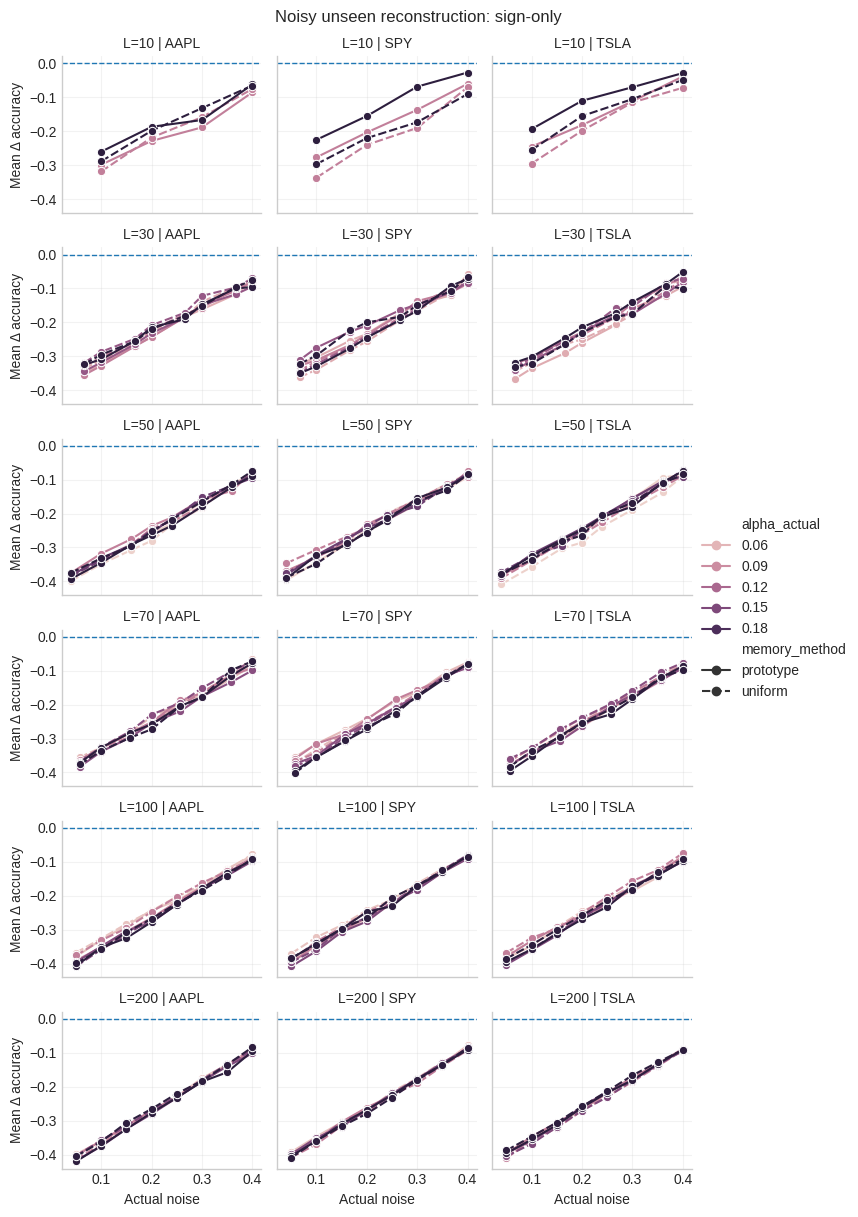

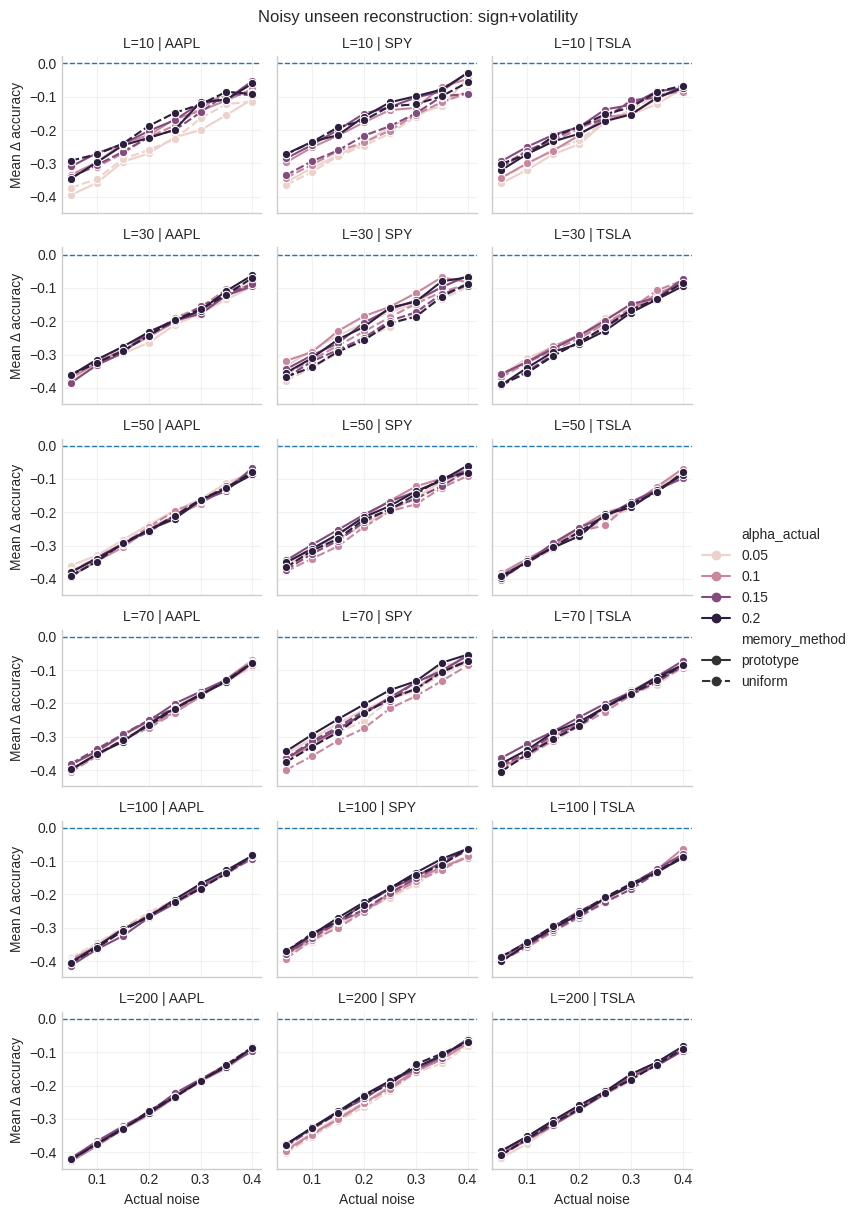

In [69]:
# =========================================================
# BLOCK 4.7.6: Delta accuracy by actual noise
# =========================================================

for representation in ["sign-only","sign+volatility"]:

    plot_data = (noisy_unseen_summary[noisy_unseen_summary["representation"] == representation])

    g = sns.relplot(
        data=plot_data,
        x="actual_noise",
        y="mean_delta_accuracy",
        hue="alpha_actual",
        style="memory_method",
        col="ticker",
        row="window",
        kind="line",
        marker="o",
        errorbar=None,
        height=2.0,
        aspect=1.2,
        facet_kws={"sharex": True,"sharey": True}
    )

    g.set_axis_labels("Actual noise","Mean Δ accuracy")
    g.set_titles("L={row_name} | {col_name}")

    for ax in g.axes.flat:
        ax.axhline(0,linestyle="--",linewidth=1)
        ax.grid(alpha=0.25)
    g.fig.suptitle(
        "Noisy unseen reconstruction: "
        f"{representation}",
        y=1.01)

    plt.show()


**Figure analysis.**

This is the central reconstruction result. Across both representations, most curves remain below the zero line:

$$
\Delta A < 0.
$$

Therefore, for previously unseen financial fragments, Hopfield dynamics generally moves the corrupted input **farther** from the true clean target rather than correcting it.

The effect is systematic across assets and most window lengths. As actual noise increases, the negative gap becomes smaller because the corrupted input itself becomes less accurate, but the restored state still usually fails to overtake it.

Differences between `uniform` and `prototype` memory are small relative to the overall negative reconstruction effect. The better historical coverage produced by prototypes is therefore insufficient to turn classical Hopfield dynamics into a successful unseen denoiser.


### Absolute noisy and restored accuracy


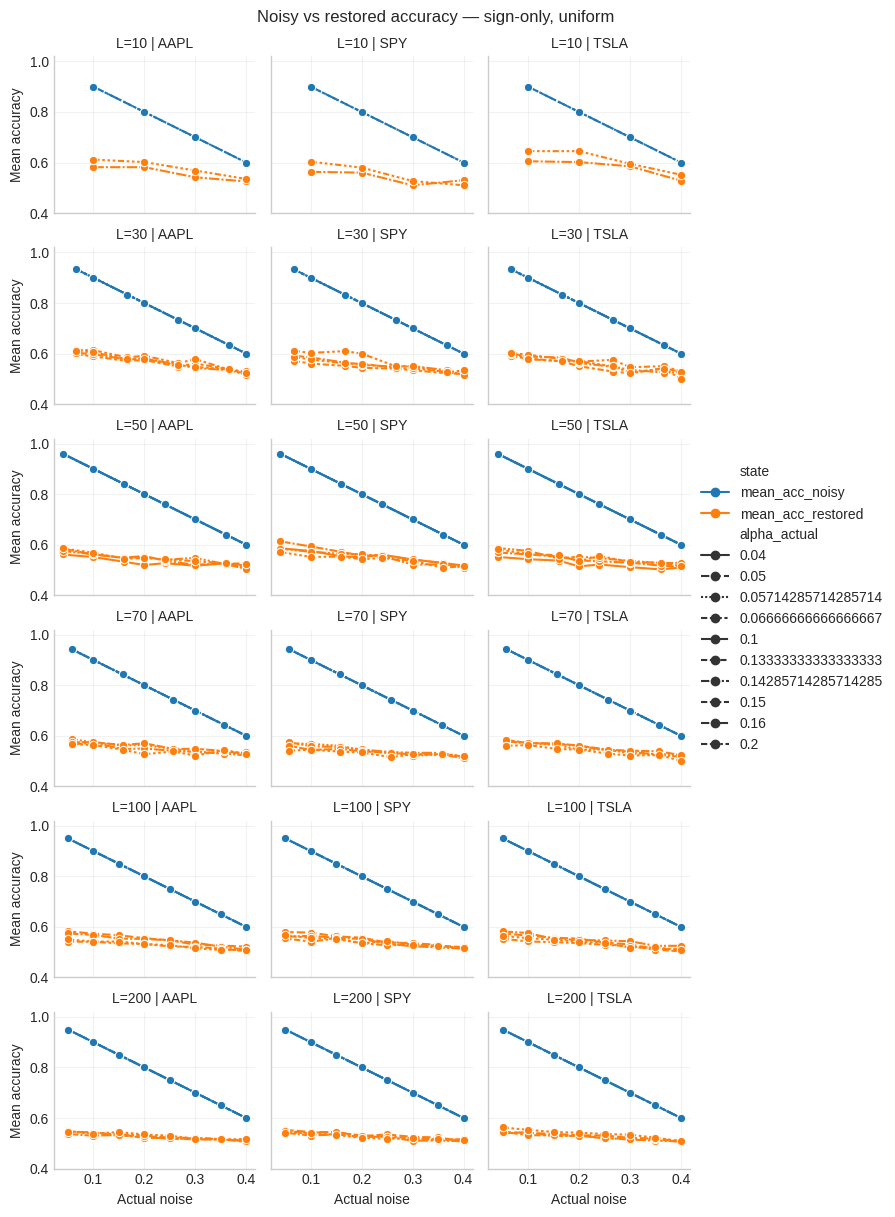

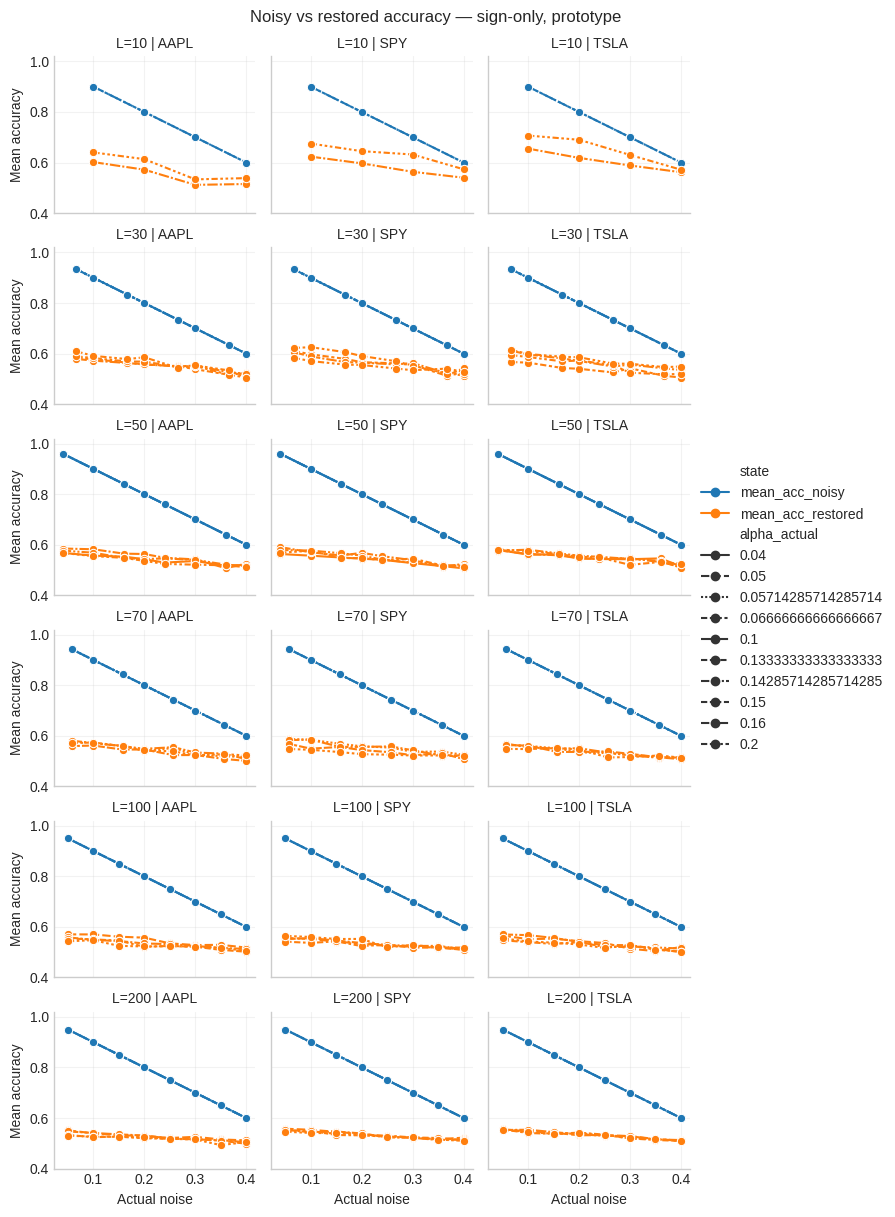

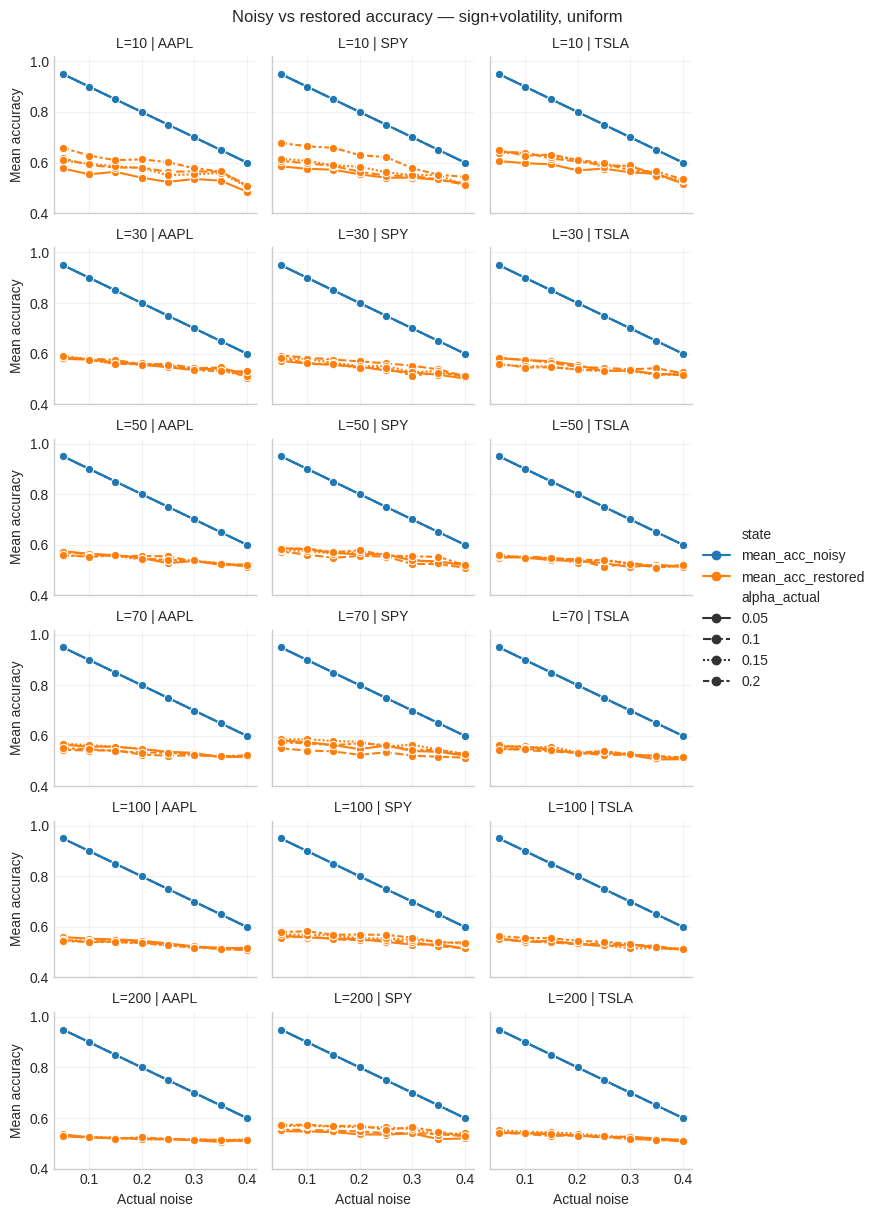

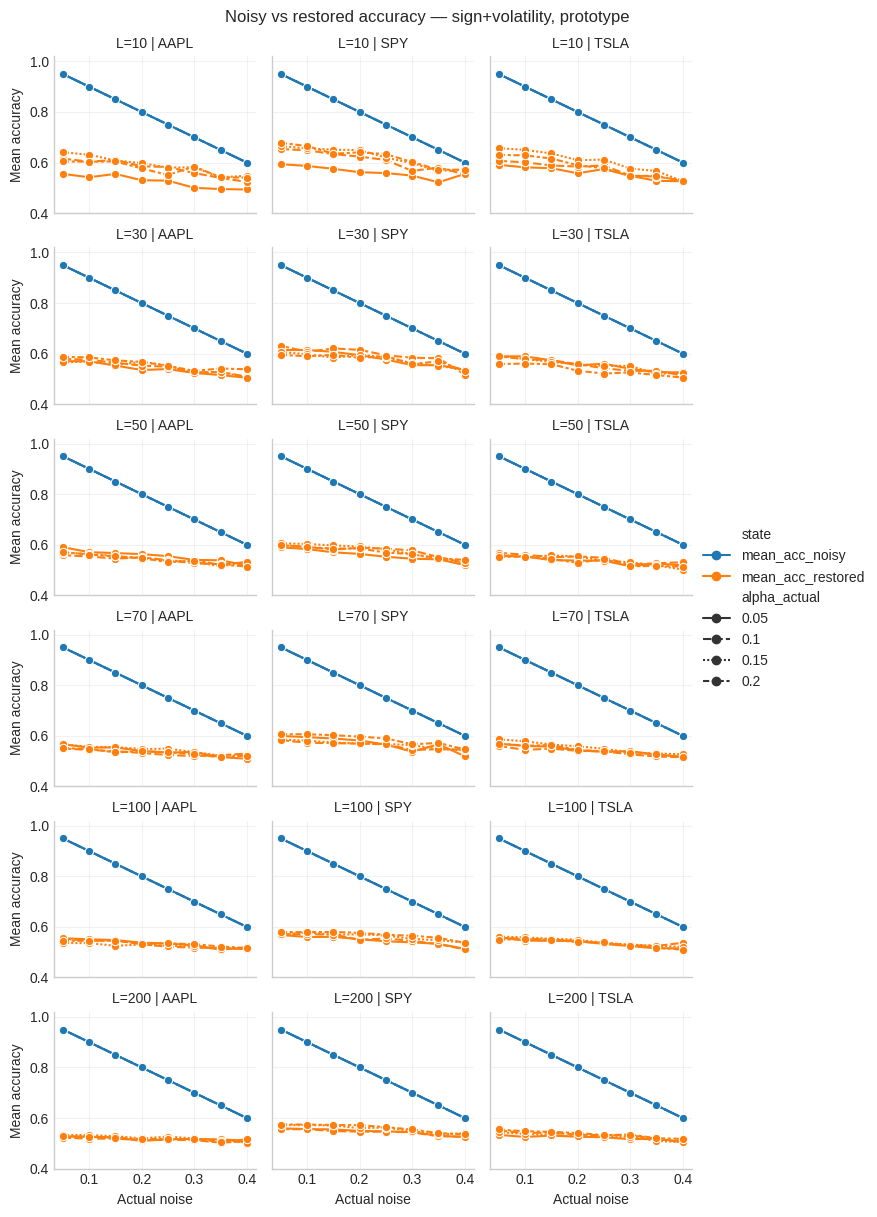

In [70]:
# =========================================================
# BLOCK 4.7.7: Noisy vs restored accuracy
# =========================================================

noisy_unseen_accuracy_long = (
    noisy_unseen_summary
    .melt(
        id_vars=[
            "representation",
            "ticker",
            "window",
            "alpha_actual",
            "memory_method",
            "actual_noise"
        ],
        value_vars=[
            "mean_acc_noisy",
            "mean_acc_restored"
        ],
        var_name="state",
        value_name="accuracy"
    )
)


for representation in [
    "sign-only",
    "sign+volatility"
]:

    for memory_method in [
        "uniform",
        "prototype"
    ]:

        plot_data = (
            noisy_unseen_accuracy_long[
                (
                    noisy_unseen_accuracy_long[
                        "representation"
                    ] == representation
                )
                &
                (
                    noisy_unseen_accuracy_long[
                        "memory_method"
                    ] == memory_method
                )
            ]
        )

        g = sns.relplot(
            data=plot_data,
            x="actual_noise",
            y="accuracy",
            hue="state",
            style="alpha_actual",
            col="ticker",
            row="window",
            kind="line",
            marker="o",
            errorbar=None,
            height=2.0,
            aspect=1.2,
            facet_kws={
                "sharex": True,
                "sharey": True
            }
        )

        g.set_axis_labels(
            "Actual noise",
            "Mean accuracy"
        )

        g.set_titles(
            "L={row_name} | {col_name}"
        )

        for ax in g.axes.flat:

            ax.set_ylim(
                0.4,
                1.02
            )

            ax.grid(
                alpha=0.25
            )

        g.fig.suptitle(
            "Noisy vs restored accuracy — "
            f"{representation}, "
            f"{memory_method}",
            y=1.01
        )

        plt.show()


**Figure analysis.**

The paired accuracy curves explain the behaviour of $\Delta A$.

At low corruption, the noisy input is still very close to the clean target, while Hopfield often pulls it toward a different memory-supported attractor. This can create a large loss in accuracy.

At stronger corruption, the noisy baseline becomes worse, so the difference between input and restored state narrows. However, this should not be mistaken for improved reconstruction: the final state generally remains no more accurate than the corrupted input.

This confirms that the negative $\Delta A$ is caused by the attractor dynamics changing the test pattern in the wrong direction relative to the true unseen target.


### Paired prototype-minus-uniform reconstruction


In [71]:

# =========================================================
# BLOCK 4.7.8: Prototype minus uniform reconstruction
# =========================================================

noisy_unseen_memory_comparison = (
    noisy_unseen_summary
    .pivot(
        index=[
            "representation",
            "ticker",
            "window",
            "n_neurons",
            "alpha_actual",
            "memory_size",
            "actual_noise",
            "n_flips"
        ],
        columns="memory_method",
        values=[
            "mean_acc_restored",
            "mean_delta_accuracy",
            "exact_recovery_rate"
        ]
    )
)

noisy_unseen_memory_comparison.columns = [
    f"{metric}_{method}"
    for metric, method
    in noisy_unseen_memory_comparison.columns
]

noisy_unseen_memory_comparison = (
    noisy_unseen_memory_comparison
    .reset_index()
)


noisy_unseen_memory_comparison[
    "prototype_minus_uniform_delta_accuracy"
] = (
    noisy_unseen_memory_comparison[
        "mean_delta_accuracy_prototype"
    ]
    -
    noisy_unseen_memory_comparison[
        "mean_delta_accuracy_uniform"
    ]
)


noisy_unseen_memory_comparison[
    "prototype_minus_uniform_restored_accuracy"
] = (
    noisy_unseen_memory_comparison[
        "mean_acc_restored_prototype"
    ]
    -
    noisy_unseen_memory_comparison[
        "mean_acc_restored_uniform"
    ]
)


noisy_unseen_memory_comparison[
    "prototype_minus_uniform_exact_recovery"
] = (
    noisy_unseen_memory_comparison[
        "exact_recovery_rate_prototype"
    ]
    -
    noisy_unseen_memory_comparison[
        "exact_recovery_rate_uniform"
    ]
)


noisy_unseen_memory_comparison

,representation,ticker,window,n_neurons,alpha_actual,memory_size,actual_noise,n_flips,mean_acc_restored_prototype,mean_acc_restored_uniform,mean_delta_accuracy_prototype,mean_delta_accuracy_uniform,exact_recovery_rate_prototype,exact_recovery_rate_uniform,prototype_minus_uniform_delta_accuracy,prototype_minus_uniform_restored_accuracy,prototype_minus_uniform_exact_recovery
0,sign+volatility,AAPL,10,20,0.05,1,0.05,1,0.555000,0.576667,-0.395000,-0.373333,0.0,0.0,-0.021667,-0.021667,0.0
1,sign+volatility,AAPL,10,20,0.05,1,0.10,2,0.541667,0.553333,-0.358333,-0.346667,0.0,0.0,-0.011667,-0.011667,0.0
2,sign+volatility,AAPL,10,20,0.05,1,0.15,3,0.555000,0.563333,-0.295000,-0.286667,0.0,0.0,-0.008333,-0.008333,0.0
3,sign+volatility,AAPL,10,20,0.05,1,0.20,4,0.530000,0.540000,-0.270000,-0.260000,0.0,0.0,-0.010000,-0.010000,0.0
4,sign+volatility,AAPL,10,20,0.05,1,0.25,5,0.528333,0.523333,-0.221667,-0.226667,0.0,0.0,0.005000,0.005000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,sign-only,TSLA,200,200,0.20,40,0.20,40,0.538833,0.542000,-0.261167,-0.258000,0.0,0.0,-0.003167,-0.003167,0.0
1076,sign-only,TSLA,200,200,0.20,40,0.25,50,0.532833,0.536917,-0.217167,-0.213083,0.0,0.0,-0.004083,-0.004083,0.0
1077,sign-only,TSLA,200,200,0.20,40,0.30,60,0.519333,0.533750,-0.180667,-0.166250,0.0,0.0,-0.014417,-0.014417,0.0
1078,sign-only,TSLA,200,200,0.20,40,0.35,70,0.516750,0.522417,-0.133250,-0.127583,0.0,0.0,-0.005667,-0.005667,0.0


**Table analysis.** Prototype and uniform memories are compared only within exactly matched experimental conditions. The paired differences alternate in sign across configurations, indicating that prototype selection does not produce a systematic reconstruction advantage even though it improved historical coverage in Section 4.6.


### Prototype advantage across noise levels


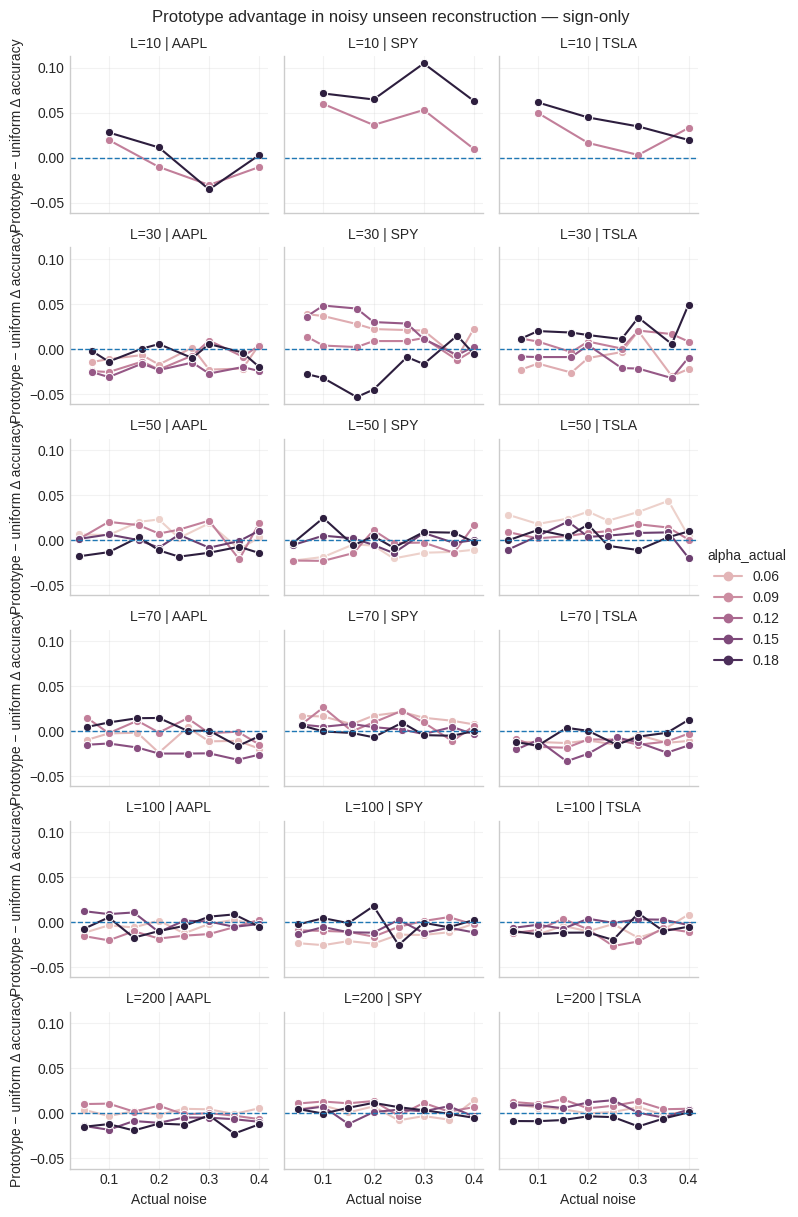

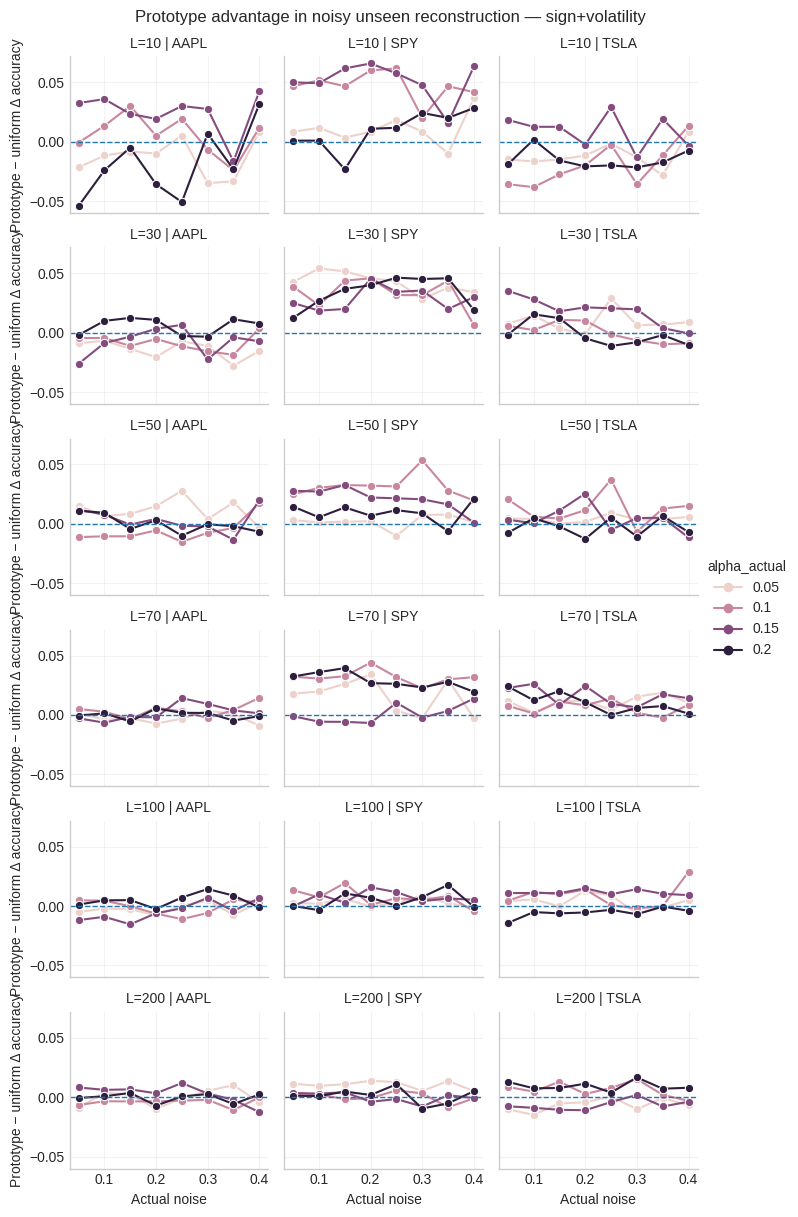

In [72]:
# =========================================================
# BLOCK 4.7.9: Prototype advantage by actual noise
# =========================================================

for representation in [
    "sign-only",
    "sign+volatility"
]:

    plot_data = (
        noisy_unseen_memory_comparison[
            noisy_unseen_memory_comparison[
                "representation"
            ] == representation
        ]
    )

    g = sns.relplot(
        data=plot_data,
        x="actual_noise",
        y="prototype_minus_uniform_delta_accuracy",
        hue="alpha_actual",
        col="ticker",
        row="window",
        kind="line",
        marker="o",
        errorbar=None,
        height=2.0,
        aspect=1.2
    )

    g.set_axis_labels(
        "Actual noise",
        "Prototype − uniform Δ accuracy"
    )

    g.set_titles(
        "L={row_name} | {col_name}"
    )

    for ax in g.axes.flat:

        ax.axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        ax.grid(
            alpha=0.25
        )

    g.fig.suptitle(
        "Prototype advantage in noisy unseen "
        f"reconstruction — {representation}",
        y=1.01
    )

    plt.show()

**Figure analysis.**

Values above zero favour prototype memory; values below zero favour uniform memory. The curves fluctuate around zero, and the sign of the advantage changes across window lengths, loads, assets, and noise levels.

The scale of these prototype-minus-uniform differences is small relative to the negative reconstruction gain shown earlier. Memory selection therefore changes details of the result but not the central conclusion.


### Movement toward memory during noisy reconstruction


In [73]:
# =========================================================
# BLOCK 4.7.10: Historical-association movement
# during noisy unseen reconstruction
# =========================================================

noisy_unseen_association_summary = (
    df_noisy_unseen
    .groupby(
        [
            "representation",
            "ticker",
            "window",
            "alpha_actual",
            "memory_size",
            "memory_method",
            "actual_noise",
            "n_flips"
        ],
        as_index=False
    )
    .agg(
        mean_distance_noisy_to_memory=(
            "normalized_distance_noisy_to_memory",
            "mean"
        ),

        mean_distance_restored_to_memory=(
            "normalized_distance_restored_to_memory",
            "mean"
        ),

        same_nearest_memory_rate=(
            "same_nearest_memory",
            "mean"
        ),

        mean_delta_accuracy=(
            "delta_accuracy",
            "mean"
        )
    )
)


noisy_unseen_association_summary[
    "mean_movement_toward_memory"
] = (
    noisy_unseen_association_summary[
        "mean_distance_noisy_to_memory"
    ]
    -
    noisy_unseen_association_summary[
        "mean_distance_restored_to_memory"
    ]
)


noisy_unseen_association_summary

,representation,ticker,window,alpha_actual,memory_size,memory_method,actual_noise,n_flips,mean_distance_noisy_to_memory,mean_distance_restored_to_memory,same_nearest_memory_rate,mean_delta_accuracy,mean_movement_toward_memory
0,sign+volatility,AAPL,10,0.05,1,prototype,0.05,1,0.501667,0.533333,1.000000,-0.395000,-0.031667
1,sign+volatility,AAPL,10,0.05,1,prototype,0.10,2,0.503333,0.516667,1.000000,-0.358333,-0.013333
2,sign+volatility,AAPL,10,0.05,1,prototype,0.15,3,0.500000,0.500000,1.000000,-0.295000,0.000000
3,sign+volatility,AAPL,10,0.05,1,prototype,0.20,4,0.511667,0.566667,1.000000,-0.270000,-0.055000
4,sign+volatility,AAPL,10,0.05,1,prototype,0.25,5,0.518333,0.600000,1.000000,-0.221667,-0.081667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,sign-only,TSLA,200,0.20,40,uniform,0.20,40,0.422583,0.305000,0.116667,-0.258000,0.117583
2156,sign-only,TSLA,200,0.20,40,uniform,0.25,50,0.422333,0.300167,0.150000,-0.213083,0.122167
2157,sign-only,TSLA,200,0.20,40,uniform,0.30,60,0.424083,0.300083,0.150000,-0.166250,0.124000
2158,sign-only,TSLA,200,0.20,40,uniform,0.35,70,0.424167,0.313083,0.216667,-0.127583,0.111083


**Table analysis.**

A key diagnostic is that movement toward stored memory can coexist with negative reconstruction gain. The network may become closer to one of its historical memories while simultaneously becoming farther from the true clean unseen test pattern.

This resolves an apparent contradiction between Sections 4.3 and 4.7: associative attraction is present, but the attractor selected by the classical network is usually not the unseen target that should be reconstructed.


### Compact reconstruction summary


In [74]:
# =========================================================
# BLOCK 4.7.11: Compact reconstruction summary
# =========================================================

noisy_unseen_compact_summary = (
    noisy_unseen_summary
    .groupby(
        [
            "representation",
            "window",
            "alpha_actual",
            "memory_size",
            "memory_method",
            "actual_noise"
        ],
        as_index=False
    )
    .agg(
        mean_acc_noisy=(
            "mean_acc_noisy",
            "mean"
        ),

        mean_acc_restored=(
            "mean_acc_restored",
            "mean"
        ),

        mean_delta_accuracy=(
            "mean_delta_accuracy",
            "mean"
        ),

        mean_exact_recovery_rate=(
            "exact_recovery_rate",
            "mean"
        )
    )
)

noisy_unseen_compact_summary

,representation,window,alpha_actual,memory_size,memory_method,actual_noise,mean_acc_noisy,mean_acc_restored,mean_delta_accuracy,mean_exact_recovery_rate
0,sign+volatility,10,0.05,1,prototype,0.05,0.95,0.579722,-0.370278,0.0
1,sign+volatility,10,0.05,1,prototype,0.10,0.90,0.569722,-0.330278,0.0
2,sign+volatility,10,0.05,1,prototype,0.15,0.85,0.569167,-0.280833,0.0
3,sign+volatility,10,0.05,1,prototype,0.20,0.80,0.549722,-0.250278,0.0
4,sign+volatility,10,0.05,1,prototype,0.25,0.75,0.553611,-0.196389,0.0
...,...,...,...,...,...,...,...,...,...,...
715,sign-only,200,0.20,40,uniform,0.20,0.80,0.532528,-0.267472,0.0
716,sign-only,200,0.20,40,uniform,0.25,0.75,0.528417,-0.221583,0.0
717,sign-only,200,0.20,40,uniform,0.30,0.70,0.523639,-0.176361,0.0
718,sign-only,200,0.20,40,uniform,0.35,0.65,0.517694,-0.132306,0.0


**Summary-table analysis.**

The compact table preserves representation, window length, realized memory load, memory method, and realized noise. Across this grid, positive mean reconstruction gain is not a stable feature. Prototype memory occasionally reduces the damage or produces a local improvement, but no representation, temporal scale, or low-load regime yields a robust positive unseen-reconstruction effect.

The negative result is therefore not driven by one asset or one isolated parameter setting.


### Diagnostic 1: can the same networks still recall stored patterns?

To distinguish a failure of unseen reconstruction from a broken or overloaded implementation, the exact memory configurations used above are tested again on the patterns they explicitly store.


In [75]:
# =========================================================
# DIAGNOSTIC 1:
# Stored-pattern stability and recall
# for the same memory configurations as Block 4.7
# =========================================================

stored_recall_diagnostic = []

diagnostic_data_stores = {
    "sign-only": unseen_data_store,
    "sign+volatility": combined_data_store
}

STORED_DIAGNOSTIC_NOISE = 0.10


for representation_id, (
    representation,
    data_store
) in enumerate(
    diagnostic_data_stores.items()
):

    for ticker_id, ticker in enumerate(TICKERS):

        for window_id, w in enumerate(WINDOWS):

            train_patterns = data_store[
                (ticker, w)
            ]["train_patterns"]

            n_neurons = train_patterns.shape[1]

            memory_configs = build_unique_level_configs(
                n_neurons,
                ALPHA_LEVELS_UNSEEN
            )

            n_flips = max(
                1,
                int(
                    np.round(
                        STORED_DIAGNOSTIC_NOISE
                        * n_neurons
                    )
                )
            )

            actual_noise = n_flips / n_neurons

            for memory_config in memory_configs:

                memory_size = memory_config["count"]
                alpha_actual = memory_config["actual_level"]

                uniform_memory_patterns = (
                    select_memory_patterns(
                        train_patterns,
                        memory_size
                    )
                )

                (
                    prototype_memory_patterns,
                    _
                ) = select_prototype_patterns(
                    train_patterns,
                    memory_size
                )

                memory_variants = {
                    "uniform":
                        uniform_memory_patterns,
                    "prototype":
                        prototype_memory_patterns
                }

                for (
                    memory_method,
                    memory_patterns
                ) in memory_variants.items():

                    net = HopfieldNetwork(
                        n_neurons=n_neurons
                    )

                    net.train(
                        memory_patterns
                    )

                    for memory_pattern_id, original_pattern in enumerate(
                        memory_patterns
                    ):


                        # 1. Clean stored pattern
                        clean_seed = int(
                            np.random.SeedSequence(
                                [
                                    42,
                                    representation_id,
                                    ticker_id,
                                    window_id,
                                    memory_size,
                                    memory_pattern_id,
                                    0
                                ]
                            ).generate_state(1)[0]
                        )

                        clean_rng = np.random.default_rng(
                            clean_seed
                        )

                        (
                            clean_after,
                            clean_converged,
                            _
                        ) = run_hopfield_with_diagnostics(
                            net,
                            original_pattern,
                            clean_rng,
                            max_sweeps=
                                MAX_SWEEPS_UNSEEN_NOISE
                        )

                        clean_accuracy = accuracy(
                            original_pattern,
                            clean_after
                        )

                        # 2. Noisy stored pattern
                        noise_seed = int(
                            np.random.SeedSequence(
                                [
                                    42,
                                    representation_id,
                                    ticker_id,
                                    window_id,
                                    memory_size,
                                    memory_pattern_id,
                                    1
                                ]
                            ).generate_state(1)[0]
                        )

                        noise_rng = np.random.default_rng(
                            noise_seed
                        )

                        (
                            noisy_pattern,
                            _
                        ) = inject_noise_by_flips(
                            original_pattern,
                            n_flips,
                            noise_rng
                        )

                        update_seed = int(
                            np.random.SeedSequence(
                                [
                                    42,
                                    representation_id,
                                    ticker_id,
                                    window_id,
                                    memory_size,
                                    memory_pattern_id,
                                    2
                                ]
                            ).generate_state(1)[0]
                        )

                        update_rng = np.random.default_rng(
                            update_seed
                        )

                        (
                            restored_pattern,
                            noisy_converged,
                            _
                        ) = run_hopfield_with_diagnostics(
                            net,
                            noisy_pattern,
                            update_rng,
                            max_sweeps=
                                MAX_SWEEPS_UNSEEN_NOISE
                        )

                        noisy_accuracy_before = accuracy(
                            original_pattern,
                            noisy_pattern
                        )

                        noisy_accuracy_after = accuracy(
                            original_pattern,
                            restored_pattern
                        )

                        stored_recall_diagnostic.append({
                            "representation":
                                representation,

                            "ticker":
                                ticker,

                            "window":
                                w,

                            "n_neurons":
                                n_neurons,

                            "alpha_actual":
                                alpha_actual,

                            "memory_size":
                                memory_size,

                            "memory_method":
                                memory_method,

                            "actual_noise":
                                actual_noise,

                            "clean_converged":
                                clean_converged,

                            "clean_accuracy":
                                clean_accuracy,

                            "clean_exact_stable":
                                clean_accuracy == 1.0,

                            "noisy_converged":
                                noisy_converged,

                            "noisy_accuracy_before":
                                noisy_accuracy_before,

                            "noisy_accuracy_after":
                                noisy_accuracy_after,

                            "noisy_delta_accuracy":
                                (
                                    noisy_accuracy_after
                                    -
                                    noisy_accuracy_before
                                ),

                            "exact_noisy_recovery":
                                noisy_accuracy_after == 1.0
                        })


df_stored_recall_diagnostic = pd.DataFrame(
    stored_recall_diagnostic
)


stored_recall_diagnostic_summary = (
    df_stored_recall_diagnostic
    .groupby(
        [
            "representation",
            "window",
            "alpha_actual",
            "memory_size",
            "memory_method"
        ],
        as_index=False
    )
    .agg(
        n_stored_patterns=(
            "clean_accuracy",
            "size"
        ),

        clean_stability_rate=(
            "clean_exact_stable",
            "mean"
        ),

        mean_clean_accuracy=(
            "clean_accuracy",
            "mean"
        ),

        mean_noisy_accuracy_before=(
            "noisy_accuracy_before",
            "mean"
        ),

        mean_noisy_accuracy_after=(
            "noisy_accuracy_after",
            "mean"
        ),

        mean_noisy_delta_accuracy=(
            "noisy_delta_accuracy",
            "mean"
        ),

        exact_noisy_recovery_rate=(
            "exact_noisy_recovery",
            "mean"
        )
    )
)

stored_recall_diagnostic_summary

,representation,window,alpha_actual,memory_size,memory_method,n_stored_patterns,clean_stability_rate,mean_clean_accuracy,mean_noisy_accuracy_before,mean_noisy_accuracy_after,mean_noisy_delta_accuracy,exact_noisy_recovery_rate
0,sign+volatility,10,0.05,1,prototype,3,1.000000,1.000000,0.9,1.000000,0.100000,1.000000
1,sign+volatility,10,0.05,1,uniform,3,1.000000,1.000000,0.9,1.000000,0.100000,1.000000
2,sign+volatility,10,0.10,2,prototype,6,1.000000,1.000000,0.9,1.000000,0.100000,1.000000
3,sign+volatility,10,0.10,2,uniform,6,1.000000,1.000000,0.9,1.000000,0.100000,1.000000
4,sign+volatility,10,0.15,3,prototype,9,0.777778,0.988889,0.9,0.911111,0.011111,0.444444
...,...,...,...,...,...,...,...,...,...,...,...,...
87,sign-only,200,0.10,20,uniform,60,0.900000,0.998750,0.9,0.998750,0.098750,0.900000
88,sign-only,200,0.15,30,prototype,90,0.466667,0.977444,0.9,0.949389,0.049389,0.388889
89,sign-only,200,0.15,30,uniform,90,0.422222,0.961222,0.9,0.918056,0.018056,0.300000
90,sign-only,200,0.20,40,prototype,120,0.133333,0.843875,0.9,0.788292,-0.111708,0.041667


**Diagnostic analysis.**

At low load, the same networks can keep stored patterns stable and can recover them after 10% corruption, often reaching perfect accuracy. At high load, stored recall deteriorates sharply, as expected from interference.

This demonstrates that the main unseen failure persists even in configurations where the network itself remains a competent associative memory.


### Diagnostic 2: is a sufficiently close historical analogue available?

The next diagnostic compares the best match available in the **entire training history** with the best match contained in the finite Hopfield memory.


In [77]:
# =========================================================
# DIAGNOSTIC 2:
# Best historical analogue ceiling
# =========================================================

historical_ceiling_results = []

diagnostic_data_stores = {
    "sign-only": unseen_data_store,
    "sign+volatility": combined_data_store
}


for representation, data_store in (
    diagnostic_data_stores.items()
):

    for ticker in TICKERS:

        for w in WINDOWS:

            train_patterns = data_store[
                (ticker, w)
            ]["train_patterns"]

            test_patterns = data_store[
                (ticker, w)
            ]["test_patterns"]

            n_neurons = train_patterns.shape[1]

            selected_test_indices = (
                select_evenly_spaced_test_indices(
                    len(test_patterns),
                    N_TEST_PATTERNS_UNSEEN_NOISE
                )
            )

            memory_configs = (
                build_unique_level_configs(
                    n_neurons,
                    ALPHA_LEVELS_UNSEEN
                )
            )

            for pattern_id in selected_test_indices:

                original_pattern = (
                    test_patterns[
                        pattern_id
                    ]
                )

                # -----------------------------------------
                # Best analogue in ALL training windows
                # -----------------------------------------

                full_train_distances = np.sum(
                    train_patterns
                    != original_pattern,
                    axis=1
                )

                best_full_train_distance = int(
                    np.min(
                        full_train_distances
                    )
                )

                best_full_train_accuracy = (
                    1
                    -
                    best_full_train_distance
                    / n_neurons
                )


                # Best analogue in the selected memories
                for memory_config in memory_configs:

                    memory_size = (
                        memory_config["count"]
                    )

                    alpha_actual = (
                        memory_config[
                            "actual_level"
                        ]
                    )

                    uniform_memory_patterns = (
                        select_memory_patterns(
                            train_patterns,
                            memory_size
                        )
                    )

                    (
                        prototype_memory_patterns,
                        _
                    ) = select_prototype_patterns(
                        train_patterns,
                        memory_size
                    )

                    memory_variants = {
                        "uniform":
                            uniform_memory_patterns,

                        "prototype":
                            prototype_memory_patterns
                    }

                    for (
                        memory_method,
                        memory_patterns
                    ) in memory_variants.items():

                        memory_distances = np.sum(
                            memory_patterns
                            != original_pattern,
                            axis=1
                        )

                        best_memory_distance = int(
                            np.min(
                                memory_distances
                            )
                        )

                        best_memory_accuracy = (
                            1
                            -
                            best_memory_distance
                            / n_neurons
                        )

                        historical_ceiling_results.append({
                            "representation":
                                representation,

                            "ticker":
                                ticker,

                            "window":
                                w,

                            "n_neurons":
                                n_neurons,

                            "pattern_id":
                                int(pattern_id),

                            "alpha_actual":
                                alpha_actual,

                            "memory_size":
                                memory_size,

                            "memory_method":
                                memory_method,

                            "best_memory_accuracy":
                                best_memory_accuracy,

                            "best_full_train_accuracy":
                                best_full_train_accuracy,

                            "memory_vs_full_train_gap":
                                (
                                    best_full_train_accuracy
                                    -
                                    best_memory_accuracy
                                )
                        })


df_historical_ceiling = pd.DataFrame(
    historical_ceiling_results
)


historical_ceiling_summary = (
    df_historical_ceiling
    .groupby(
        [
            "representation",
            "window",
            "alpha_actual",
            "memory_size",
            "memory_method"
        ],
        as_index=False
    )
    .agg(
        mean_best_memory_accuracy=(
            "best_memory_accuracy",
            "mean"
        ),

        mean_best_full_train_accuracy=(
            "best_full_train_accuracy",
            "mean"
        ),

        mean_memory_vs_full_train_gap=(
            "memory_vs_full_train_gap",
            "mean"
        ),

        min_best_memory_accuracy=(
            "best_memory_accuracy",
            "min"
        ),

        max_best_memory_accuracy=(
            "best_memory_accuracy",
            "max"
        )
    )
)

historical_ceiling_summary

,representation,window,alpha_actual,memory_size,memory_method,mean_best_memory_accuracy,mean_best_full_train_accuracy,mean_memory_vs_full_train_gap,min_best_memory_accuracy,max_best_memory_accuracy
0,sign+volatility,10,0.05,1,prototype,0.550833,0.858333,0.307500,0.350,0.850
1,sign+volatility,10,0.05,1,uniform,0.504167,0.858333,0.354167,0.250,0.800
2,sign+volatility,10,0.10,2,prototype,0.608333,0.858333,0.250000,0.350,0.800
3,sign+volatility,10,0.10,2,uniform,0.585833,0.858333,0.272500,0.400,0.800
4,sign+volatility,10,0.15,3,prototype,0.652500,0.858333,0.205833,0.400,0.850
...,...,...,...,...,...,...,...,...,...,...
87,sign-only,200,0.10,20,uniform,0.565000,0.616000,0.051000,0.525,0.615
88,sign-only,200,0.15,30,prototype,0.576417,0.616000,0.039583,0.545,0.625
89,sign-only,200,0.15,30,uniform,0.572750,0.616000,0.043250,0.540,0.635
90,sign-only,200,0.20,40,prototype,0.574083,0.616000,0.041917,0.545,0.610


**Diagnostic analysis.**

The result reveals two distinct limitations.

1. **Coverage limitation for short combined patterns.** For `sign+volatility`, $L=10$, the complete training set can contain a very close analogue of an unseen test state, with best full-train accuracy around 0.858. A small stable Hopfield memory contains substantially weaker analogues, roughly around the 0.50–0.65 range. Increasing $P$ would improve coverage, but it also increases interference.

2. **Intrinsic lack of close analogues for long sign patterns.** For `sign-only`, $L=200$, even the best pattern in the complete training set reaches only about 0.616 similarity. No clever selection of a small memory can reconstruct a target for which the historical data contain no sufficiently close example.

Together with the stored-recall diagnostic, this identifies a **coverage–interference trade-off**: small memories are stable but cover too little of historical diversity; larger memories cover more states but become less stable.


### Section 4 conclusion

The central reconstruction hypothesis is **not supported** in the investigated classical binary setting.

The network successfully recalls states that were explicitly stored, and it often moves unseen inputs toward historical memory. However, when a previously unseen test pattern is corrupted, Hopfield dynamics generally does not restore the true clean target and often decreases its accuracy.

The most important explanation is the coverage–interference trade-off:

- with few stored patterns, the memory is stable but does not contain enough of the historical state space;
- with more stored patterns, coverage improves but interference degrades the attractor structure;
- for long windows, sufficiently close historical analogues may not exist even in the full training set.

This is a negative result about direct unseen reconstruction with the **classical binary Hopfield network**, not a claim that associative memory or forecasting is impossible in general.


# 5. One-step directional forecasting

The reconstruction experiments show that direct denoising of unseen patterns is not successful. Forecasting asks a different question: even if the current state is not reconstructed exactly, can a retrieved historical analogue provide useful information about what happened next?

For every context

$$
X_t=[x_{t-L+1},\ldots,x_t],
$$

the target is the next return sign

$$
y_{t+1}=x_{t+1}.
$$

The forecasting experiments use the same leakage-safe chronological train/test split as the unseen reconstruction experiments.


## 5.1. Historical-analogue forecasting helpers

These helpers implement majority voting, persistence, first-order Markov prediction, nearest historical analogue retrieval, and continuation-based forecasting.


In [78]:
# =========================================================
# BLOCK 5.1: Historical-analogue forecasting helpers
# =========================================================

FORECAST_RANDOM_STATE = 42


def select_uniform_pattern_indices(n_patterns, memory_size):
    """Returns the same evenly spaced indices used by uniform memory selection."""
    if memory_size > n_patterns:
        raise ValueError("memory_size exceeds number of training patterns.")

    if memory_size == 1:
        return np.array([0], dtype=int)

    return np.linspace(0, n_patterns - 1, memory_size, dtype=int)


def binary_majority(values):
    """Returns the majority sign. Exact ties are resolved as +1."""
    return 1 if np.sum(values) >= 0 else -1


def predict_from_nearest_analogue(query_pattern, historical_patterns, continuation_targets, fallback_prediction):
    """
    Finds the minimum Hamming distance to historical patterns.

    If several historical patterns are equally close, their continuation
    signs vote. An exact vote tie falls back to fallback_prediction.
    """
    distances = np.sum(historical_patterns != query_pattern, axis=1)
    min_distance = int(np.min(distances))
    nearest_mask = distances == min_distance

    nearest_targets = continuation_targets[nearest_mask]
    vote = np.sum(nearest_targets)

    if vote > 0:
        prediction = 1
    elif vote < 0:
        prediction = -1
    else:
        prediction = fallback_prediction

    return prediction, min_distance, int(np.sum(nearest_mask))

## 5.2. Forecasting dataset

Training contexts are paired with their observed next-step sign. Test contexts are constructed independently inside the later test segment, so no context crosses the temporal train/test boundary.


In [79]:
# =========================================================
# BLOCK 5.2: Forecasting dataset
# =========================================================

forecast_data_store = {}

for ticker in TICKERS:
    sign_series = binary_df[ticker].values
    returns_series = log_returns_df[ticker].values

    split_idx = int(len(sign_series) * TRAIN_RATIO_UNSEEN)

    train_sign = sign_series[:split_idx]
    test_sign = sign_series[split_idx:]

    train_returns = returns_series[:split_idx]
    test_returns = returns_series[split_idx:]

    volatility_threshold = np.median(np.abs(train_returns))
    train_volatility = np.where(np.abs(train_returns) > volatility_threshold, 1, -1)
    test_volatility = np.where(np.abs(test_returns) > volatility_threshold, 1, -1)

    for w in WINDOWS:
        train_sign_windows = extract_sliding_windows(train_sign, window_length=w)
        test_sign_windows = extract_sliding_windows(test_sign, window_length=w)

        train_volatility_windows = extract_sliding_windows(train_volatility, window_length=w)
        test_volatility_windows = extract_sliding_windows(test_volatility, window_length=w)

        # The last window has no next-step target inside the same split.
        train_sign_contexts = train_sign_windows[:-1]
        test_sign_contexts = test_sign_windows[:-1]

        train_volatility_contexts = train_volatility_windows[:-1]
        test_volatility_contexts = test_volatility_windows[:-1]

        train_targets = train_sign[w:]
        test_targets = test_sign[w:]

        combined_train_contexts = np.concatenate([train_sign_contexts, train_volatility_contexts], axis=1)
        combined_test_contexts = np.concatenate([test_sign_contexts, test_volatility_contexts], axis=1)

        if len(train_sign_contexts) != len(train_targets):
            raise RuntimeError(f"Train forecasting alignment error: {ticker}, window={w}")

        if len(test_sign_contexts) != len(test_targets):
            raise RuntimeError(f"Test forecasting alignment error: {ticker}, window={w}")

        forecast_data_store[(ticker, w)] = {
            "sign_train_contexts": train_sign_contexts,
            "sign_test_contexts": test_sign_contexts,
            "combined_train_contexts": combined_train_contexts,
            "combined_test_contexts": combined_test_contexts,
            "train_targets": train_targets,
            "test_targets": test_targets
        }

print("Forecasting datasets prepared.")

Forecasting datasets prepared.


**Dataset check.** The alignment checks confirm that every context has exactly one next-step target and that the final window without an in-split continuation is excluded.


## 5.3. Baselines and conventional forecasting models

The first forecasting stage establishes how much predictive signal can be extracted **without** Hopfield dynamics.

The baselines are:

- `majority`: always predict the majority training class;
- `persistence`: repeat the latest observed sign;
- `markov-1`: use the empirical next-sign distribution conditional on the current sign;
- `full-train-nearest`: use the continuation of the closest historical training context.


In [80]:
# =========================================================
# BLOCK 5.3: Forecasting baselines
# =========================================================

forecast_baseline_results = []

for representation in ["sign-only", "sign+volatility"]:
    for ticker in TICKERS:
        for w in WINDOWS:
            data = forecast_data_store[(ticker, w)]

            train_sign_contexts = data["sign_train_contexts"]
            train_contexts = data["sign_train_contexts"] if representation == "sign-only" else data["combined_train_contexts"]
            test_contexts = data["sign_test_contexts"] if representation == "sign-only" else data["combined_test_contexts"]

            train_targets = data["train_targets"]
            test_targets = data["test_targets"]

            majority_prediction = binary_majority(train_targets)

            markov_predictions = {}
            for last_sign in [-1, 1]:
                mask = train_sign_contexts[:, -1] == last_sign
                markov_predictions[last_sign] = binary_majority(train_targets[mask]) if np.any(mask) else majority_prediction

            for pattern_id, (test_context, true_target) in enumerate(zip(test_contexts, test_targets)):
                current_sign = int(data["sign_test_contexts"][pattern_id, -1])
                persistence_prediction = current_sign
                markov_prediction = int(markov_predictions[current_sign])

                nearest_prediction, nearest_distance, nearest_ties = predict_from_nearest_analogue(
                    test_context, train_contexts, train_targets, majority_prediction
                )

                predictions = {
                    "majority": majority_prediction,
                    "persistence": persistence_prediction,
                    "markov-1": markov_prediction,
                    "full-train-nearest": nearest_prediction
                }

                for method, prediction in predictions.items():
                    forecast_baseline_results.append({
                        "representation": representation,
                        "ticker": ticker,
                        "window": w,
                        "pattern_id": pattern_id,
                        "method": method,
                        "true_target": int(true_target),
                        "prediction": int(prediction),
                        "correct": int(prediction == true_target),
                        "nearest_distance": nearest_distance if method == "full-train-nearest" else np.nan,
                        "nearest_ties": nearest_ties if method == "full-train-nearest" else np.nan
                    })


df_forecast_baselines = pd.DataFrame(forecast_baseline_results)

forecast_baseline_summary = (
    df_forecast_baselines
    .groupby(["representation", "ticker", "window", "method"], as_index=False)
    .agg(
        n_predictions=("correct", "size"),
        accuracy=("correct", "mean")
    )
)

forecast_baseline_summary

,representation,ticker,window,method,n_predictions,accuracy
0,sign+volatility,AAPL,10,full-train-nearest,292,0.513699
1,sign+volatility,AAPL,10,majority,292,0.541096
2,sign+volatility,AAPL,10,markov-1,292,0.541096
3,sign+volatility,AAPL,10,persistence,292,0.523973
4,sign+volatility,AAPL,30,full-train-nearest,272,0.466912
...,...,...,...,...,...,...
139,sign-only,TSLA,100,persistence,202,0.480198
140,sign-only,TSLA,200,full-train-nearest,102,0.588235
141,sign-only,TSLA,200,majority,102,0.558824
142,sign-only,TSLA,200,markov-1,102,0.558824


**Table analysis.**

Nearest historical analogues occasionally outperform simple rules for individual assets and window lengths, but the advantage is not stable across the experiment grid. Historical similarity alone therefore does not imply that the next return sign will repeat the continuation of the closest past context.


### Balanced accuracy for the baseline methods

Balanced accuracy is used alongside ordinary accuracy because it gives equal weight to both sign classes.


In [81]:
# =========================================================
# BLOCK 5.3.1: Balanced accuracy for forecasting baselines
# =========================================================

from sklearn.metrics import balanced_accuracy_score

forecast_baseline_balanced = (
    df_forecast_baselines
    .groupby(["representation", "ticker", "window", "method"])
    .apply(
        lambda group: pd.Series({
            "accuracy": group["correct"].mean(),
            "balanced_accuracy": balanced_accuracy_score(group["true_target"], group["prediction"])
        }),
        include_groups=False
    )
    .reset_index()
)

forecast_baseline_balanced

,representation,ticker,window,method,accuracy,balanced_accuracy
0,sign+volatility,AAPL,10,full-train-nearest,0.513699,0.504723
1,sign+volatility,AAPL,10,majority,0.541096,0.500000
2,sign+volatility,AAPL,10,markov-1,0.541096,0.500000
3,sign+volatility,AAPL,10,persistence,0.523973,0.520452
4,sign+volatility,AAPL,30,full-train-nearest,0.466912,0.454122
...,...,...,...,...,...,...
139,sign-only,TSLA,100,persistence,0.480198,0.476522
140,sign-only,TSLA,200,full-train-nearest,0.588235,0.582456
141,sign-only,TSLA,200,majority,0.558824,0.500000
142,sign-only,TSLA,200,markov-1,0.558824,0.500000


**Table analysis.**

Majority-type rules can achieve ordinary accuracy above 0.5 when positive returns are slightly more common, but their balanced accuracy remains 0.5 because they do not distinguish both classes. The nearest-analogue and simple temporal rules fluctuate around the same reference level, with asset- and window-specific deviations but no stable cross-asset advantage.


### k-nearest neighbours and logistic regression on continuous returns

Unlike classical Hopfield, these methods do not require bipolar inputs. They are therefore trained on continuous log-return windows, with standardization fitted only on the training split.

`kNN` uses a fixed $k=5$; the value is not selected using test performance.


In [82]:
# =========================================================
# BLOCK 5.3.2: Standard forecasting models
# kNN and Logistic Regression on continuous log returns
# =========================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score

KNN_K = 5

forecast_standard_results = []

for ticker in TICKERS:
    sign_series = binary_df[ticker].values
    returns_series = log_returns_df[ticker].values

    split_idx = int(len(returns_series) * TRAIN_RATIO_UNSEEN)

    train_returns = returns_series[:split_idx]
    test_returns = returns_series[split_idx:]

    for w in WINDOWS:
        train_return_windows = extract_sliding_windows(train_returns, window_length=w)[:-1]
        test_return_windows = extract_sliding_windows(test_returns, window_length=w)[:-1]

        train_targets = sign_series[:split_idx][w:]
        test_targets = sign_series[split_idx:][w:]

        if len(train_return_windows) != len(train_targets):
            raise RuntimeError(f"Train alignment error: {ticker}, window={w}")

        if len(test_return_windows) != len(test_targets):
            raise RuntimeError(f"Test alignment error: {ticker}, window={w}")

        # Scaling is fitted ONLY on train.
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_return_windows)
        test_scaled = scaler.transform(test_return_windows)

        models = {
            "kNN": KNeighborsClassifier(n_neighbors=KNN_K),
            "Logistic Regression": LogisticRegression(
                max_iter=1000,
                random_state=FORECAST_RANDOM_STATE
            )
        }

        for method, model in models.items():
            model.fit(train_scaled, train_targets)
            predictions = model.predict(test_scaled)

            forecast_standard_results.append({
                "ticker": ticker,
                "window": w,
                "method": method,
                "n_predictions": len(test_targets),
                "accuracy": np.mean(predictions == test_targets),
                "balanced_accuracy": balanced_accuracy_score(
                    test_targets,
                    predictions
                )
            })

forecast_standard_summary = pd.DataFrame(forecast_standard_results)
forecast_standard_summary

,ticker,window,method,n_predictions,accuracy,balanced_accuracy
0,SPY,10,kNN,292,0.510274,0.492031
1,SPY,10,Logistic Regression,292,0.551370,0.490783
2,SPY,30,kNN,272,0.529412,0.506163
3,SPY,30,Logistic Regression,272,0.492647,0.467753
4,SPY,50,kNN,252,0.496032,0.481780
5,SPY,50,Logistic Regression,252,0.511905,0.480497
6,SPY,70,kNN,232,0.495690,0.479242
7,SPY,70,Logistic Regression,232,0.543103,0.512424
8,SPY,100,kNN,202,0.539604,0.521893
9,SPY,100,Logistic Regression,202,0.549505,0.520077


**Table analysis.**

Both kNN and logistic regression produce mixed results across assets and temporal scales. Some configurations rise above 0.5 balanced accuracy, while others fall below it. The absence of a stable improvement even with continuous inputs suggests that information loss from Hopfield binarization is not the only reason that next-day directional forecasting is difficult in this dataset.


## 5.4. Forecasting through limited Hopfield memory

For each representation and memory configuration, two retrieval procedures are compared.

**Direct retrieval**

$$
X_t \rightarrow X_i \rightarrow y_i.
$$

The current test context is matched directly to the nearest stored historical pattern, and that pattern's known historical continuation is used as the forecast.

**Hopfield retrieval**

$$
X_t \rightarrow H(X_t) \rightarrow X_i \rightarrow y_i.
$$

The current context first passes through Hopfield dynamics. The nearest stored pattern to the resulting state is then retrieved, and its continuation becomes the forecast.

Because both procedures use the **same finite memory**, their difference isolates the contribution of Hopfield dynamics.


In [89]:
# =========================================================
# BLOCK 5.4: Historical-analogue forecasting
# Direct retrieval vs Hopfield retrieval
# =========================================================

forecast_hopfield_results = []

representation_context_keys = {
    "sign-only": ("sign_train_contexts", "sign_test_contexts"),
    "sign+volatility": ("combined_train_contexts", "combined_test_contexts")
}

for representation_id, (representation, context_keys) in enumerate(representation_context_keys.items()):
    train_key, test_key = context_keys

    for ticker_id, ticker in enumerate(TICKERS):
        for window_id, w in enumerate(WINDOWS):
            data = forecast_data_store[(ticker, w)]

            train_contexts = data[train_key]
            test_contexts = data[test_key]
            train_targets = data["train_targets"]
            test_targets = data["test_targets"]

            n_neurons = train_contexts.shape[1]
            majority_prediction = binary_majority(train_targets)
            memory_configs = build_unique_level_configs(n_neurons, ALPHA_LEVELS_UNSEEN)

            for memory_config in memory_configs:
                memory_size = memory_config["count"]
                alpha_actual = memory_config["actual_level"]

                if memory_size > len(train_contexts):
                    continue

                uniform_indices = select_uniform_pattern_indices(len(train_contexts), memory_size)
                uniform_patterns = train_contexts[uniform_indices]

                prototype_patterns, prototype_indices = select_prototype_patterns(train_contexts, memory_size)

                memory_variants = {
                    "uniform": (uniform_patterns, uniform_indices),
                    "prototype": (prototype_patterns, prototype_indices)
                }

                networks = {}
                for memory_method, (memory_patterns, _) in memory_variants.items():
                    net = HopfieldNetwork(n_neurons=n_neurons)
                    net.train(memory_patterns)
                    networks[memory_method] = net

                for pattern_id, (test_context, true_target) in enumerate(zip(test_contexts, test_targets)):
                    for memory_method, (memory_patterns, memory_indices) in memory_variants.items():
                        memory_targets = train_targets[memory_indices]

                        direct_prediction, direct_distance, direct_ties = predict_from_nearest_analogue(
                            test_context, memory_patterns, memory_targets, majority_prediction
                        )

                        update_seed = int(np.random.SeedSequence([
                            FORECAST_RANDOM_STATE,
                            representation_id,
                            ticker_id,
                            window_id,
                            pattern_id
                        ]).generate_state(1)[0])

                        update_rng = np.random.default_rng(update_seed)

                        restored_context, converged, sweeps_used = run_hopfield_with_diagnostics(
                            networks[memory_method],
                            test_context,
                            update_rng,
                            max_sweeps=MAX_SWEEPS_UNSEEN_NOISE
                        )

                        hopfield_prediction, hopfield_distance, hopfield_ties = predict_from_nearest_analogue(
                            restored_context, memory_patterns, memory_targets, majority_prediction
                        )

                        forecast_hopfield_results.append({
                            "representation": representation,
                            "ticker": ticker,
                            "window": w,
                            "n_neurons": n_neurons,
                            "pattern_id": pattern_id,
                            "alpha_actual": alpha_actual,
                            "memory_size": memory_size,
                            "memory_method": memory_method,
                            "true_target": int(true_target),

                            "direct_prediction": int(direct_prediction),
                            "direct_correct": int(direct_prediction == true_target),
                            "direct_distance": direct_distance,
                            "direct_ties": direct_ties,

                            "hopfield_prediction": int(hopfield_prediction),
                            "hopfield_correct": int(hopfield_prediction == true_target),
                            "hopfield_distance": hopfield_distance,
                            "hopfield_ties": hopfield_ties,

                            "converged": converged,
                            "sweeps_used": sweeps_used
                        })


df_forecast_hopfield = pd.DataFrame(forecast_hopfield_results)

print("Rows:", len(df_forecast_hopfield))
print("Non-converged runs:", int((~df_forecast_hopfield["converged"]).sum()))

df_forecast_hopfield

Rows: 61392
Non-converged runs: 0


,representation,ticker,window,n_neurons,pattern_id,alpha_actual,memory_size,memory_method,true_target,direct_prediction,direct_correct,direct_distance,direct_ties,hopfield_prediction,hopfield_correct,hopfield_distance,hopfield_ties,converged,sweeps_used
0,sign-only,SPY,10,10,0,0.1,1,uniform,-1,1,0,4,1,1,0,0,1,True,2
1,sign-only,SPY,10,10,0,0.1,1,prototype,-1,-1,1,4,1,-1,1,0,1,True,2
2,sign-only,SPY,10,10,1,0.1,1,uniform,-1,1,0,7,1,1,0,10,1,True,2
3,sign-only,SPY,10,10,1,0.1,1,prototype,-1,-1,1,5,1,-1,1,10,1,True,2
4,sign-only,SPY,10,10,2,0.1,1,uniform,1,1,1,6,1,1,1,10,1,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61387,sign+volatility,TSLA,200,400,99,0.2,80,prototype,-1,-1,1,174,1,-1,1,138,1,True,17
61388,sign+volatility,TSLA,200,400,100,0.2,80,uniform,-1,-1,1,178,3,-1,1,145,1,True,9
61389,sign+volatility,TSLA,200,400,100,0.2,80,prototype,-1,-1,1,170,1,1,0,133,1,True,19
61390,sign+volatility,TSLA,200,400,101,0.2,80,uniform,-1,1,0,183,2,-1,1,129,1,True,14


**Execution analysis.** The experiment contains 61,392 trial-level forecasts. All Hopfield runs converge under the configured sweep limit, so forecasting differences are not caused by non-converged network states.


### Configuration-level direct-versus-Hopfield summary


In [90]:
# =========================================================
# BLOCK 5.5: Forecasting summary
# =========================================================

forecast_hopfield_summary = (
    df_forecast_hopfield
    .groupby(
        ["representation", "ticker", "window", "alpha_actual", "memory_size", "memory_method"],
        as_index=False
    )
    .agg(
        n_predictions=("true_target", "size"),
        direct_accuracy=("direct_correct", "mean"),
        hopfield_accuracy=("hopfield_correct", "mean"),
        convergence_rate=("converged", "mean"),
        mean_sweeps=("sweeps_used", "mean")
    )
)

forecast_hopfield_summary["hopfield_minus_direct_accuracy"] = (
    forecast_hopfield_summary["hopfield_accuracy"] - forecast_hopfield_summary["direct_accuracy"]
)

forecast_hopfield_summary

,representation,ticker,window,alpha_actual,memory_size,memory_method,n_predictions,direct_accuracy,hopfield_accuracy,convergence_rate,mean_sweeps,hopfield_minus_direct_accuracy
0,sign+volatility,AAPL,10,0.05,1,prototype,292,0.458904,0.458904,1.0,2.000000,0.000000
1,sign+volatility,AAPL,10,0.05,1,uniform,292,0.541096,0.541096,1.0,2.000000,0.000000
2,sign+volatility,AAPL,10,0.10,2,prototype,292,0.448630,0.448630,1.0,2.000000,0.000000
3,sign+volatility,AAPL,10,0.10,2,uniform,292,0.541096,0.541096,1.0,2.000000,0.000000
4,sign+volatility,AAPL,10,0.15,3,prototype,292,0.482877,0.462329,1.0,2.150685,-0.020548
...,...,...,...,...,...,...,...,...,...,...,...,...
271,sign-only,TSLA,200,0.10,20,uniform,102,0.539216,0.490196,1.0,7.676471,-0.049020
272,sign-only,TSLA,200,0.15,30,prototype,102,0.529412,0.509804,1.0,8.892157,-0.019608
273,sign-only,TSLA,200,0.15,30,uniform,102,0.549020,0.441176,1.0,9.333333,-0.107843
274,sign-only,TSLA,200,0.20,40,prototype,102,0.480392,0.480392,1.0,8.529412,0.000000


In [91]:
# =========================================================
# BLOCK 5.5.1: Balanced accuracy for direct and Hopfield retrieval
# =========================================================

forecast_hopfield_balanced = (
    df_forecast_hopfield
    .groupby(["representation", "ticker", "window", "alpha_actual", "memory_size", "memory_method"])
    .apply(
        lambda group: pd.Series({
            "direct_accuracy": group["direct_correct"].mean(),
            "hopfield_accuracy": group["hopfield_correct"].mean(),
            "direct_balanced_accuracy": balanced_accuracy_score(group["true_target"], group["direct_prediction"]),
            "hopfield_balanced_accuracy": balanced_accuracy_score(group["true_target"], group["hopfield_prediction"])
        }),
        include_groups=False
    )
    .reset_index()
)

forecast_hopfield_balanced["hopfield_minus_direct_balanced_accuracy"] = (
    forecast_hopfield_balanced["hopfield_balanced_accuracy"] -
    forecast_hopfield_balanced["direct_balanced_accuracy"]
)

forecast_hopfield_balanced

,representation,ticker,window,alpha_actual,memory_size,memory_method,direct_accuracy,hopfield_accuracy,direct_balanced_accuracy,hopfield_balanced_accuracy,hopfield_minus_direct_balanced_accuracy
0,sign+volatility,AAPL,10,0.05,1,prototype,0.458904,0.458904,0.500000,0.500000,0.000000
1,sign+volatility,AAPL,10,0.05,1,uniform,0.541096,0.541096,0.500000,0.500000,0.000000
2,sign+volatility,AAPL,10,0.10,2,prototype,0.448630,0.448630,0.436662,0.436662,0.000000
3,sign+volatility,AAPL,10,0.10,2,uniform,0.541096,0.541096,0.500000,0.500000,0.000000
4,sign+volatility,AAPL,10,0.15,3,prototype,0.482877,0.462329,0.483610,0.463490,-0.020121
...,...,...,...,...,...,...,...,...,...,...,...
271,sign-only,TSLA,200,0.10,20,uniform,0.539216,0.490196,0.512865,0.476023,-0.036842
272,sign-only,TSLA,200,0.15,30,prototype,0.529412,0.509804,0.529825,0.526316,-0.003509
273,sign-only,TSLA,200,0.15,30,uniform,0.549020,0.441176,0.545029,0.450877,-0.094152
274,sign-only,TSLA,200,0.20,40,prototype,0.480392,0.480392,0.483626,0.490643,0.007018


**Table analysis.**

For each configuration, the key comparison is

$$
\Delta A_{\mathrm{Hopfield}}
=
A_{\mathrm{Hopfield}}
-
A_{\mathrm{direct}}.
$$

Positive and negative values both occur. Hopfield dynamics therefore genuinely changes which historical association is selected, but the change is not consistently useful for the next return sign.

Balanced accuracy leads to the same qualitative conclusion: there is no stable improvement over direct retrieval from the same memory.


### Aggregated numerical comparison of forecasting methods

The previous experiments evaluated forecasting methods in two stages.

First, simple and conventional baselines were tested independently of Hopfield memory: majority prediction, persistence, first-order Markov prediction, full-history nearest analogue, k-nearest neighbours, and logistic regression.

Second, historical-analogue forecasting was evaluated using the limited Hopfield memory, both with and without Hopfield dynamics.

The following comparison combines these results into a common table using balanced accuracy. This makes it possible to compare the overall forecasting performance of classical baselines, conventional machine-learning methods, historical analogue retrieval, and Hopfield-based retrieval under the same chronological test split.

For Hopfield-based methods, results are averaged across the investigated memory loads and memory-selection strategies for each asset and window length. No best test configuration is selected, which avoids choosing a favourable Hopfield setting retrospectively.

In [92]:
# =========================================================
# BLOCK 5.5.2: Unified forecasting comparison
# =========================================================

# Simple baselines and full-history analogue search.
baseline_comparison = (
    forecast_baseline_balanced[
        (forecast_baseline_balanced["representation"] == "sign-only")
        & forecast_baseline_balanced["method"].isin([
            "majority",
            "persistence",
            "markov-1",
            "full-train-nearest"
        ])
    ]
    [["ticker", "window", "method", "balanced_accuracy"]]
    .copy()
)

baseline_comparison["method"] = baseline_comparison["method"].replace({
    "majority": "Majority",
    "persistence": "Persistence",
    "markov-1": "Markov-1",
    "full-train-nearest": "Nearest analogue"
})

# kNN and Logistic Regression on continuous returns.
standard_comparison = forecast_standard_summary[
    ["ticker", "window", "method", "balanced_accuracy"]
].copy()

# Hopfield: average over investigated memory loads and
# memory-selection methods for each ticker/window.
hopfield_comparison = (
    forecast_hopfield_balanced
    .groupby(["representation", "ticker", "window"], as_index=False)
    .agg(balanced_accuracy=("hopfield_balanced_accuracy", "mean"))
)

hopfield_comparison["method"] = hopfield_comparison["representation"].replace({
    "sign-only": "Hopfield: sign",
    "sign+volatility": "Hopfield: sign+volatility"
})

hopfield_comparison = hopfield_comparison[
    ["ticker", "window", "method", "balanced_accuracy"]
]

forecast_final_comparison = pd.concat(
    [
        baseline_comparison,
        standard_comparison,
        hopfield_comparison
    ],
    ignore_index=True
)

forecast_final_summary = (
    forecast_final_comparison
    .groupby("method", as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        min_balanced_accuracy=("balanced_accuracy", "min"),
        max_balanced_accuracy=("balanced_accuracy", "max")
    )
    .sort_values("mean_balanced_accuracy", ascending=False)
)

forecast_final_summary

,method,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,max_balanced_accuracy
6,Persistence,0.503258,0.020376,0.476522,0.544643
1,Hopfield: sign+volatility,0.500431,0.010823,0.480239,0.527480
4,Markov-1,0.500000,0.000000,0.500000,0.500000
3,Majority,0.500000,0.000000,0.500000,0.500000
0,Hopfield: sign,0.499688,0.008818,0.480336,0.513293
5,Nearest analogue,0.497892,0.032423,0.452640,0.582456
2,Logistic Regression,0.497087,0.024007,0.467753,0.558731
7,kNN,0.485287,0.029954,0.412281,0.532407


**Result analysis.**

The unified comparison shows that the investigated forecasting methods remain concentrated near the balanced-accuracy reference level of 0.5 when results are considered across assets and temporal window lengths.

The simple majority and first-order Markov rules provide no balanced discrimination when they collapse to a dominant-class prediction. Persistence performs slightly above or below this reference depending on the asset and window length, but no stable advantage is observed.

The full-history nearest-analogue method occasionally performs better for individual configurations, showing that similar historical contexts can sometimes share the same continuation. However, this effect is not consistent across assets or temporal scales.

kNN and logistic regression, which receive continuous return windows rather than the bipolar representation required by classical Hopfield, also fail to show a stable improvement across the complete experiment. This indicates that the weak forecasting result cannot be attributed solely to the binary Hopfield representation.

The Hopfield-based methods remain in the same general performance range. Their average performance does not establish a systematic advantage over direct historical retrieval or conventional baselines. Therefore, in this dataset and evaluation setting, neither associative retrieval nor the tested conventional methods extract a stable next-day directional signal from the investigated historical contexts.

**Section conclusion.**  
The forecasting comparison does not identify a universally superior method. Local improvements occur for particular assets and window lengths, but they are not reproduced consistently across the experiment. This motivates the following analysis of whether the limitation is related to the static nature of classical Hopfield memory and whether a directional temporal association can provide additional information.

### Detailed forecasting diagnostics

The next plots retain the detailed diagnostic views used during analysis. They show how historical-analogue forecasting and Hopfield contribution vary across scale, representation, asset, and memory-selection method.


### Baseline accuracy by window length


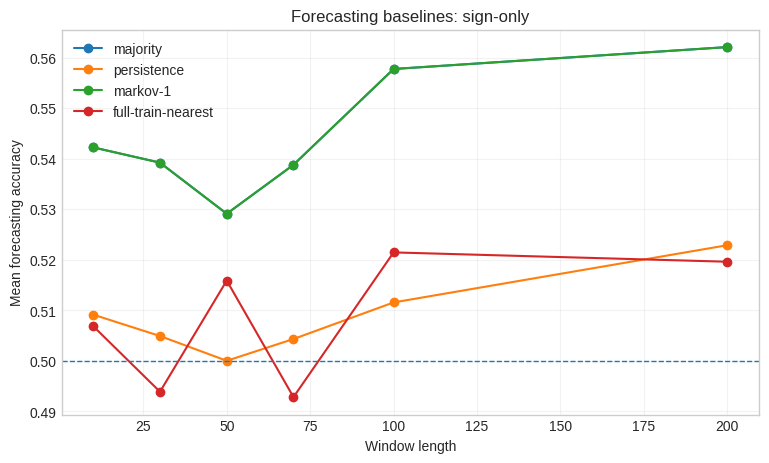

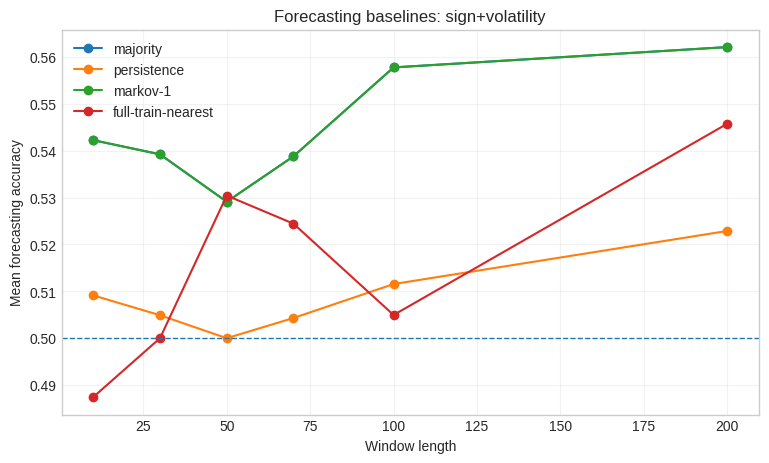

In [93]:
# =========================================================
# BLOCK 5.6.1: Baseline accuracy by window
# =========================================================

baseline_by_window = (
    forecast_baseline_summary
    .groupby(["representation", "window", "method"], as_index=False)
    .agg(mean_accuracy=("accuracy", "mean"))
)

for representation in ["sign-only", "sign+volatility"]:
    plot_data = baseline_by_window[baseline_by_window["representation"] == representation]

    plt.figure(figsize=(9, 5))

    for method in ["majority", "persistence", "markov-1", "full-train-nearest"]:
        method_data = plot_data[plot_data["method"] == method]
        plt.plot(method_data["window"], method_data["mean_accuracy"], marker="o", label=method)

    plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.xlabel("Window length")
    plt.ylabel("Mean forecasting accuracy")
    plt.title(f"Forecasting baselines: {representation}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

**Figure analysis.**

Historical nearest-neighbour retrieval does not dominate simple rules across window lengths. Its relative position changes with scale and representation, indicating that local similarity in the chosen feature space is not a reliable universal predictor of the next return sign.

The result is consistent with the baseline tables: some windows show local improvement, but there is no stable ordering of the forecasting rules.


### Full-training nearest analogue relative to the majority baseline


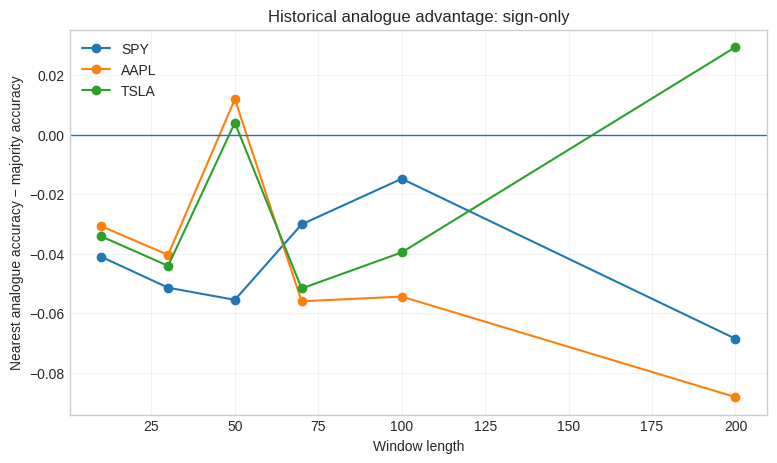

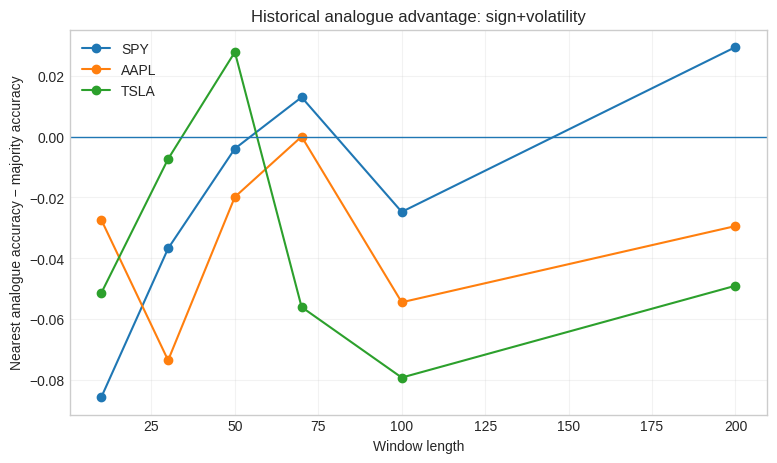

In [94]:
# =========================================================
# BLOCK 5.6.2: Full-train nearest vs majority
# =========================================================

baseline_pivot = (
    forecast_baseline_summary
    .pivot_table(
        index=["representation", "ticker", "window"],
        columns="method",
        values="accuracy"
    )
    .reset_index()
)

baseline_pivot["nearest_minus_majority"] = (
    baseline_pivot["full-train-nearest"] - baseline_pivot["majority"]
)

for representation in ["sign-only", "sign+volatility"]:
    plot_data = baseline_pivot[baseline_pivot["representation"] == representation]

    plt.figure(figsize=(9, 5))

    for ticker in TICKERS:
        ticker_data = plot_data[plot_data["ticker"] == ticker]
        plt.plot(
            ticker_data["window"],
            ticker_data["nearest_minus_majority"],
            marker="o",
            label=ticker
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("Window length")
    plt.ylabel("Nearest analogue accuracy − majority accuracy")
    plt.title(f"Historical analogue advantage: {representation}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

**Figure analysis.**

The difference between nearest-analogue accuracy and majority accuracy repeatedly changes sign across assets and windows. Positive cases therefore exist, but they are not reproduced consistently.

This is important for the associative-memory hypothesis: even an oracle-like search over the **entire training history** does not provide a universally useful continuation rule.


### Direct retrieval versus Hopfield-assisted retrieval


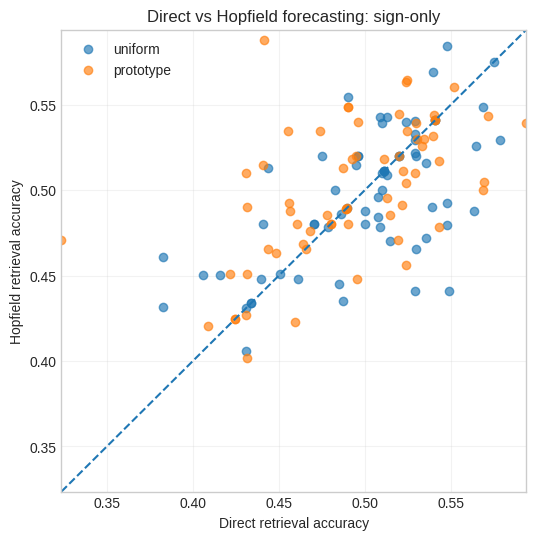

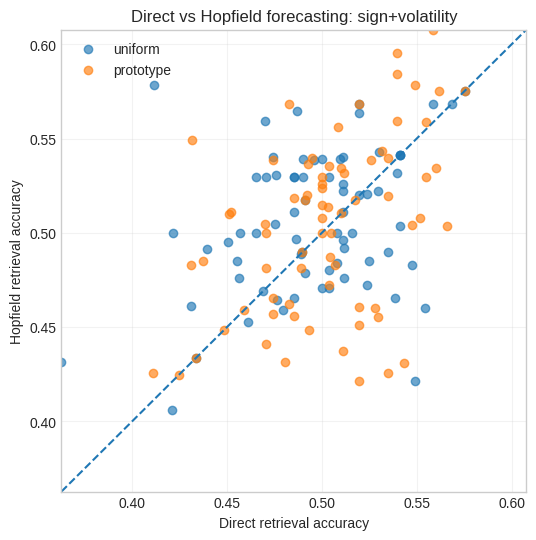

In [95]:
# =========================================================
# BLOCK 5.6.3: Direct retrieval vs Hopfield retrieval
# =========================================================

for representation in ["sign-only", "sign+volatility"]:
    plot_data = forecast_hopfield_summary[
        forecast_hopfield_summary["representation"] == representation
    ]

    plt.figure(figsize=(6, 6))

    for memory_method in ["uniform", "prototype"]:
        method_data = plot_data[plot_data["memory_method"] == memory_method]

        plt.scatter(
            method_data["direct_accuracy"],
            method_data["hopfield_accuracy"],
            alpha=0.65,
            label=memory_method
        )

    limits = [
        min(plot_data["direct_accuracy"].min(), plot_data["hopfield_accuracy"].min()),
        max(plot_data["direct_accuracy"].max(), plot_data["hopfield_accuracy"].max())
    ]

    plt.plot(limits, limits, linestyle="--")
    plt.xlim(limits)
    plt.ylim(limits)
    plt.xlabel("Direct retrieval accuracy")
    plt.ylabel("Hopfield retrieval accuracy")
    plt.title(f"Direct vs Hopfield forecasting: {representation}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

**Figure analysis.**

Each point is one complete experimental configuration. Points above the equality line favour Hopfield-assisted retrieval; points below favour direct retrieval.

The cloud occupies both sides of the diagonal. Thus Hopfield dynamics can alter the historical association, sometimes improving and sometimes worsening the forecast, but there is no systematic forecasting advantage.

This is the most direct visualization of the incremental value of classical Hopfield dynamics because the underlying finite memory is held fixed.


### Hopfield contribution by temporal window


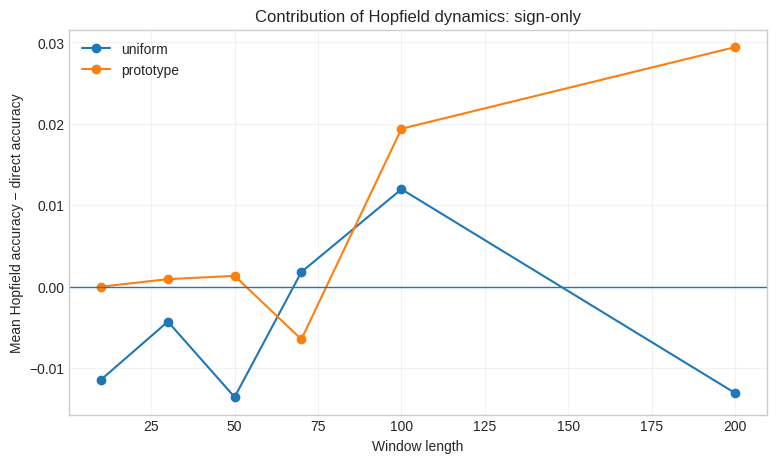

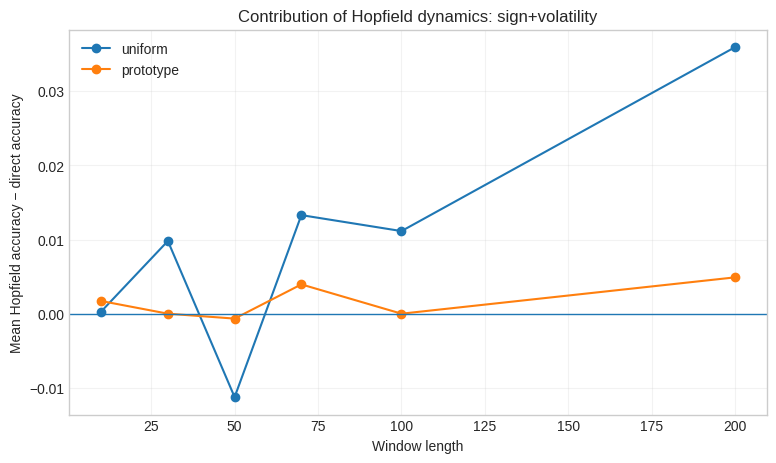

In [96]:
# =========================================================
# BLOCK 5.6.4: Hopfield contribution by window
# =========================================================

hopfield_delta_by_window = (
    forecast_hopfield_summary
    .groupby(["representation", "window", "memory_method"], as_index=False)
    .agg(
        mean_delta=("hopfield_minus_direct_accuracy", "mean"),
        median_delta=("hopfield_minus_direct_accuracy", "median")
    )
)

for representation in ["sign-only", "sign+volatility"]:
    plot_data = hopfield_delta_by_window[
        hopfield_delta_by_window["representation"] == representation
    ]

    plt.figure(figsize=(9, 5))

    for memory_method in ["uniform", "prototype"]:
        method_data = plot_data[plot_data["memory_method"] == memory_method]

        plt.plot(
            method_data["window"],
            method_data["mean_delta"],
            marker="o",
            label=memory_method
        )

    plt.axhline(0, linewidth=1)
    plt.xlabel("Window length")
    plt.ylabel("Mean Hopfield accuracy − direct accuracy")
    plt.title(f"Contribution of Hopfield dynamics: {representation}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

**Figure analysis.**

The mean Hopfield-minus-direct contribution changes sign across window lengths, representations, and memory-selection strategies. No temporal scale produces a consistently positive region.

The result rules out a simple explanation in which classical Hopfield becomes useful only at one particular short, medium, or long window length.


### Compact numerical summary


In [97]:
# =========================================================
# BLOCK 5.6.5: Compact numerical summary
# =========================================================

hopfield_compact_summary = (
    forecast_hopfield_summary
    .groupby(["representation", "memory_method"], as_index=False)
    .agg(
        mean_direct_accuracy=("direct_accuracy", "mean"),
        mean_hopfield_accuracy=("hopfield_accuracy", "mean"),
        mean_delta=("hopfield_minus_direct_accuracy", "mean"),
        median_delta=("hopfield_minus_direct_accuracy", "median"),
        min_delta=("hopfield_minus_direct_accuracy", "min"),
        max_delta=("hopfield_minus_direct_accuracy", "max")
    )
)

hopfield_compact_summary

,representation,memory_method,mean_direct_accuracy,mean_hopfield_accuracy,mean_delta,median_delta,min_delta,max_delta
0,sign+volatility,prototype,0.502513,0.504164,0.001651,0.004313,-0.112069,0.117647
1,sign+volatility,uniform,0.496248,0.506118,0.009870,0.000000,-0.127451,0.166667
2,sign-only,prototype,0.491810,0.499915,0.008105,0.000000,-0.068627,0.147059
3,sign-only,uniform,0.500561,0.496403,-0.004158,0.000000,-0.107843,0.078431


**Summary analysis.**

Mean direct and Hopfield accuracies differ only by small amounts after aggregation. Median deltas remain close to zero. Local improvements therefore do not accumulate into a stable overall gain.

Prototype and uniform memories show slightly different average behaviour, but neither produces a general advantage from Hopfield dynamics.


### Frequency of improvement


In [98]:
hopfield_win_rate_summary = (
    forecast_hopfield_summary
    .assign(
        hopfield_better=forecast_hopfield_summary["hopfield_minus_direct_accuracy"] > 0,
        hopfield_equal=forecast_hopfield_summary["hopfield_minus_direct_accuracy"] == 0,
        hopfield_worse=forecast_hopfield_summary["hopfield_minus_direct_accuracy"] < 0
    )
    .groupby(["representation", "memory_method"], as_index=False)
    .agg(
        n_configs=("hopfield_better", "size"),
        better_rate=("hopfield_better", "mean"),
        equal_rate=("hopfield_equal", "mean"),
        worse_rate=("hopfield_worse", "mean")
    )
)

hopfield_win_rate_summary

,representation,memory_method,n_configs,better_rate,equal_rate,worse_rate
0,sign+volatility,prototype,72,0.513889,0.125000,0.361111
1,sign+volatility,uniform,72,0.486111,0.152778,0.361111
2,sign-only,prototype,66,0.484848,0.181818,0.333333
3,sign-only,uniform,66,0.348485,0.257576,0.393939


**Diagnostic analysis.**

The win/equal/loss rates confirm the mixed picture. Depending on representation and memory-selection method, Hopfield improves a meaningful subset of configurations, but comparable fractions show no change or deterioration. The improvement frequency is therefore not sufficiently consistent to support a claim of systematic forecasting benefit.


## 5.6. Visual comparison of forecasting methods

The following two plots provide the compact views most useful for comparing all methods.

Balanced accuracy is the primary comparison metric because it is not inflated by a mild class imbalance.


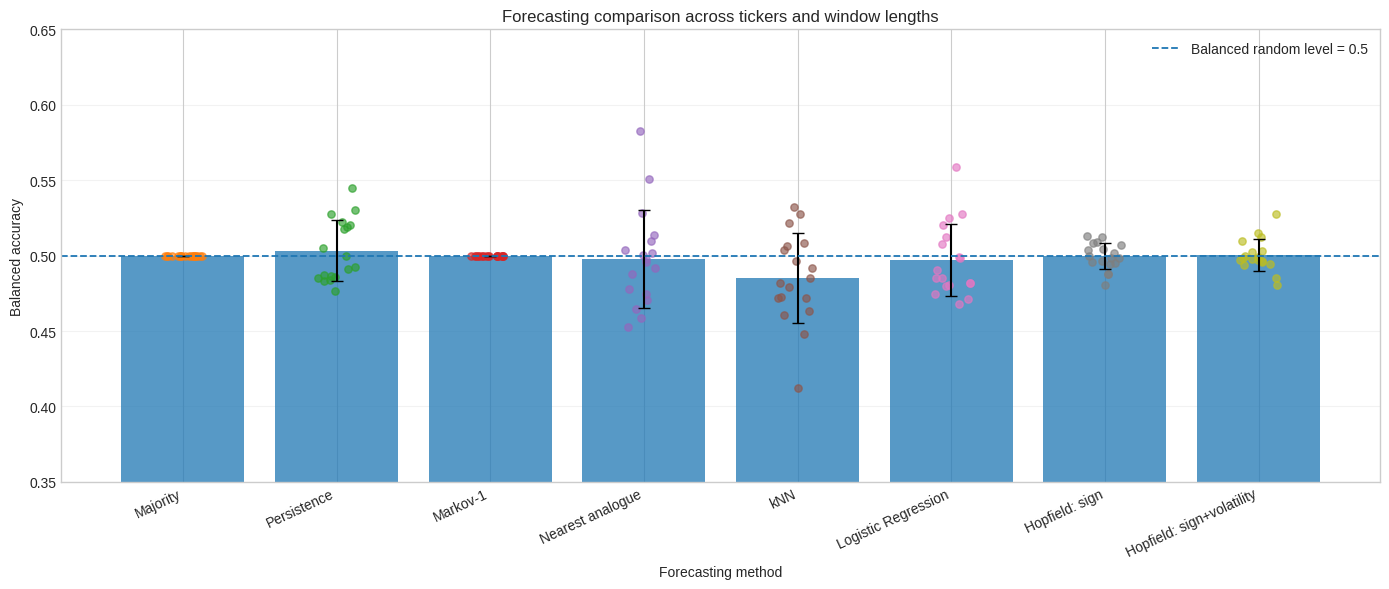

In [99]:
# =========================================================
# BLOCK 5.6.1: Main forecasting comparison
# =========================================================

method_order = [
    "Majority",
    "Persistence",
    "Markov-1",
    "Nearest analogue",
    "kNN",
    "Logistic Regression",
    "Hopfield: sign",
    "Hopfield: sign+volatility"
]

plot_data = forecast_final_comparison.copy()

summary_plot = (
    plot_data
    .groupby("method", as_index=False)
    .agg(
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std")
    )
    .set_index("method")
    .reindex(method_order)
    .reset_index()
)

x = np.arange(len(method_order))

plt.figure(figsize=(14, 6))

plt.bar(
    x,
    summary_plot["mean_balanced_accuracy"],
    yerr=summary_plot["std_balanced_accuracy"],
    capsize=4,
    alpha=0.75
)

# Individual ticker/window results.
rng = np.random.default_rng(FORECAST_RANDOM_STATE)

for method_id, method in enumerate(method_order):
    values = plot_data.loc[
        plot_data["method"] == method,
        "balanced_accuracy"
    ].values

    jitter = rng.uniform(-0.13, 0.13, size=len(values))

    plt.scatter(
        np.full(len(values), method_id) + jitter,
        values,
        s=28,
        alpha=0.65
    )

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1.3,
    label="Balanced random level = 0.5"
)

plt.xticks(x, method_order, rotation=25, ha="right")
plt.ylabel("Balanced accuracy")
plt.xlabel("Forecasting method")
plt.title("Forecasting comparison across tickers and window lengths")
plt.ylim(
    min(0.35, plot_data["balanced_accuracy"].min() - 0.03),
    max(0.65, plot_data["balanced_accuracy"].max() + 0.03)
)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

**Figure analysis.**

The method-level bars cluster around the 0.5 balanced-accuracy reference, while the overlaid configuration points show substantial dispersion.

Persistence, nearest analogue, kNN, logistic regression, and both Hopfield representations all have isolated stronger cases, but no method produces a stable cross-asset advantage. The classical Hopfield bars do not separate clearly from the non-associative baselines.

The main conclusion is therefore not that every configuration is exactly random, but that the forecasting signal is weak and unstable across the tested assets and temporal scales.


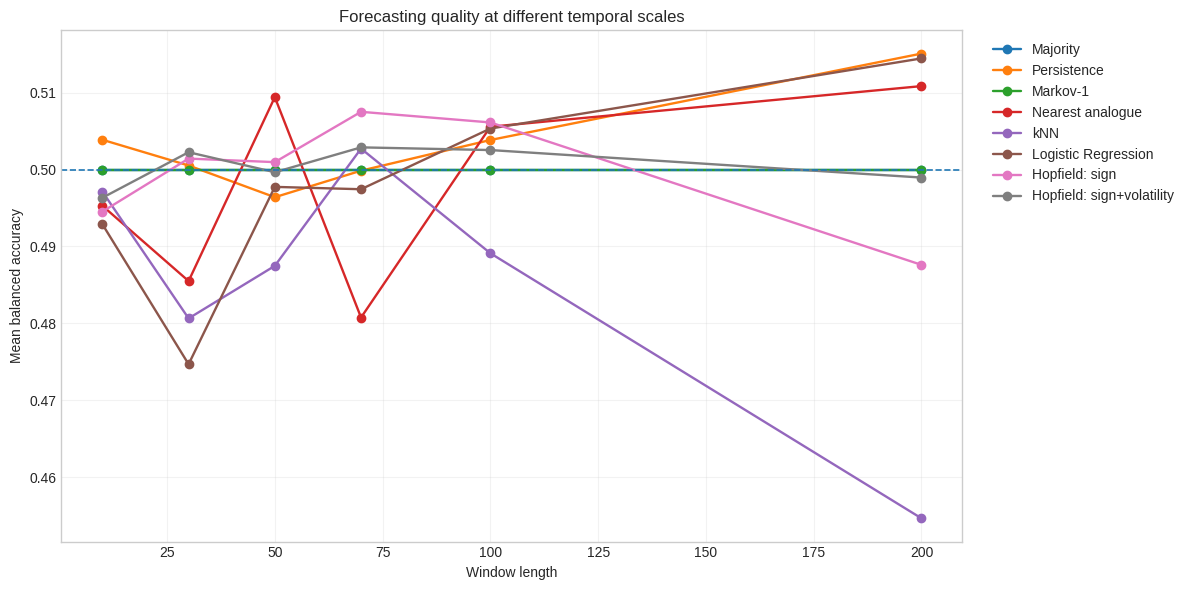

In [100]:
# =========================================================
# BLOCK 5.6.2: Forecasting quality by window length
# =========================================================

window_comparison = (
    forecast_final_comparison
    .groupby(["method", "window"], as_index=False)
    .agg(mean_balanced_accuracy=("balanced_accuracy", "mean"))
)

plt.figure(figsize=(12, 6))

for method in method_order:
    method_data = window_comparison[
        window_comparison["method"] == method
    ]

    plt.plot(
        method_data["window"],
        method_data["mean_balanced_accuracy"],
        marker="o",
        linewidth=1.7,
        label=method
    )

plt.axhline(0.5, linestyle="--", linewidth=1.2)

plt.xlabel("Window length")
plt.ylabel("Mean balanced accuracy")
plt.title("Forecasting quality at different temporal scales")
plt.grid(alpha=0.25)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

**Figure analysis.**

Plotting mean balanced accuracy against window length shows that the ranking of methods changes with temporal scale. No single window makes all methods improve, and no forecasting family has a monotonic advantage as context length increases.

This reinforces the decision to treat scale as an experimental dimension rather than to report one selectively chosen 'best' window.


## 5.7. Asymmetric temporal associative model

The classical Hopfield network is symmetric and naturally encodes static associations of the form

$$
X \rightarrow X.
$$

Forecasting is directional. The additional temporal model therefore learns transitions between consecutive states:

$$
X_t \rightarrow X_{t+1}.
$$

This is an asymmetric associative model and is reported separately from the classical energy-minimizing Hopfield network.


In [101]:
# =========================================================
# BLOCK 5.7.1: Temporal asymmetric Hopfield network
# =========================================================

class TemporalHopfieldNetwork:
    def __init__(self, n_neurons):
        self.n = n_neurons
        self.W = np.zeros((n_neurons, n_neurons))

    def train(self, current_patterns, next_patterns):
        if current_patterns.shape != next_patterns.shape:
            raise ValueError("Current and next patterns must have the same shape.")

        self.W = next_patterns.T @ current_patterns

    def predict_state(self, current_state):
        local_fields = self.W @ current_state

        predicted_state = current_state.copy().astype(float)

        predicted_state[local_fields > 0] = 1.0
        predicted_state[local_fields < 0] = -1.0

        return predicted_state

### One-step temporal forecasting

The model is trained on consecutive windows from the training split. For a test context, one asymmetric matrix transformation predicts the next state; the final element of that state is interpreted as the next return sign.


In [102]:
# =========================================================
# BLOCK 5.7.2: Temporal Hopfield forecasting
# =========================================================

temporal_hopfield_results = []

for ticker in TICKERS:
    sign_series = binary_df[ticker].values

    split_idx = int(len(sign_series) * TRAIN_RATIO_UNSEEN)

    train_sign = sign_series[:split_idx]
    test_sign = sign_series[split_idx:]

    for w in WINDOWS:
        train_windows = extract_sliding_windows(train_sign, window_length=w)
        test_windows = extract_sliding_windows(test_sign, window_length=w)

        current_train_patterns = train_windows[:-1]
        next_train_patterns = train_windows[1:]

        test_contexts = test_windows[:-1]
        test_targets = test_sign[w:]

        if len(test_contexts) != len(test_targets):
            raise RuntimeError(
                f"Temporal Hopfield alignment error: {ticker}, window={w}"
            )

        net = TemporalHopfieldNetwork(n_neurons=w)
        net.train(current_train_patterns, next_train_patterns)

        for pattern_id, (test_context, true_target) in enumerate(
            zip(test_contexts, test_targets)
        ):
            predicted_state = net.predict_state(test_context)

            predicted_target = int(predicted_state[-1])

            temporal_hopfield_results.append({
                "ticker": ticker,
                "window": w,
                "pattern_id": pattern_id,
                "true_target": int(true_target),
                "prediction": predicted_target,
                "correct": int(predicted_target == true_target)
            })

df_temporal_hopfield = pd.DataFrame(temporal_hopfield_results)

temporal_hopfield_summary = (
    df_temporal_hopfield
    .groupby(["ticker", "window"])
    .apply(
        lambda group: pd.Series({
            "n_predictions": len(group),
            "accuracy": group["correct"].mean(),
            "balanced_accuracy": balanced_accuracy_score(
                group["true_target"],
                group["prediction"]
            )
        }),
        include_groups=False
    )
    .reset_index()
)

temporal_hopfield_summary

,ticker,window,n_predictions,accuracy,balanced_accuracy
0,AAPL,10,292.0,0.489726,0.487106
1,AAPL,30,272.0,0.466912,0.458912
2,AAPL,50,252.0,0.452381,0.448994
3,AAPL,70,232.0,0.495690,0.490591
4,AAPL,100,202.0,0.475248,0.476982
5,AAPL,200,102.0,0.450980,0.445652
6,SPY,10,292.0,0.493151,0.479263
7,SPY,30,272.0,0.522059,0.505613
8,SPY,50,252.0,0.571429,0.550395
9,SPY,70,232.0,0.543103,0.517273


**Result analysis.**

The temporal model produces more heterogeneous results than classical static-memory forecasting.

- **AAPL:** balanced accuracy remains below 0.5 for every tested window, approximately 0.45–0.49.
- **SPY:** performance is scale-dependent; values near 0.55 appear at $L=50$ and around 0.54 at $L=200$.
- **TSLA:** most windows exceed 0.5, with the highest result around 0.59 at $L=200$ and another local gain around 0.55 at $L=70$.

The directional association therefore changes the behaviour substantially, but the effect is asset-specific and should not be interpreted as universal predictive ability. Because all windows are evaluated on the same holdout period, the best individual window is not treated as proof of generalizable forecasting skill.


### Temporal-model performance by window length


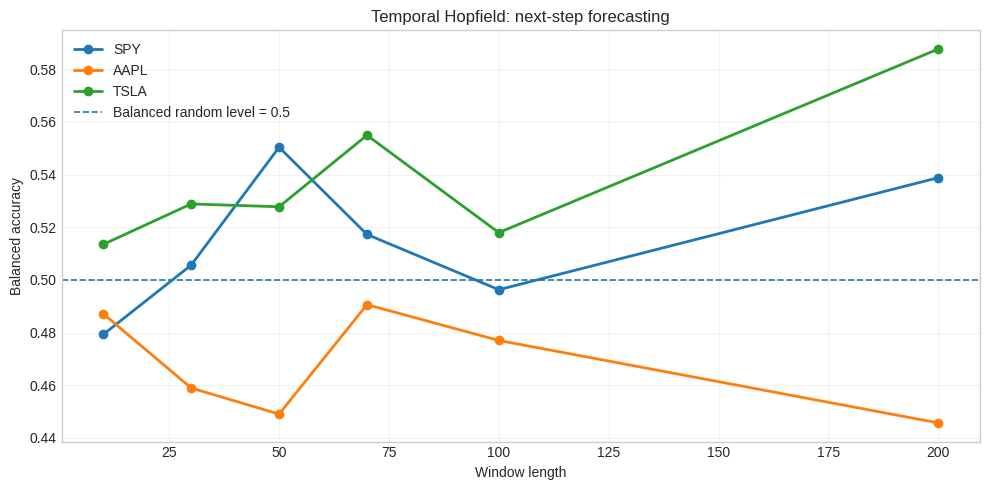

In [103]:
# =========================================================
# BLOCK 5.7.3: Temporal Hopfield results by window
# =========================================================

plt.figure(figsize=(10, 5))

for ticker in TICKERS:
    ticker_data = temporal_hopfield_summary[
        temporal_hopfield_summary["ticker"] == ticker
    ]

    plt.plot(
        ticker_data["window"],
        ticker_data["balanced_accuracy"],
        marker="o",
        linewidth=2,
        label=ticker
    )

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label="Balanced random level = 0.5"
)

plt.xlabel("Window length")
plt.ylabel("Balanced accuracy")
plt.title("Temporal Hopfield: next-step forecasting")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

**Figure analysis.**

The window-length curves make the lack of a universal scale explicit.

AAPL remains below the 0.5 reference across the grid. SPY shows a local peak at an intermediate scale and a smaller increase at the longest scale. TSLA is more often above 0.5 and reaches its highest value at $L=200$.

Increasing temporal context is therefore neither uniformly beneficial nor uniformly harmful. The useful scale, when one appears, depends on the asset and the test period.


## 5.8. Cross-scale agreement

The final forecasting diagnostic asks whether agreement among short, medium, and long contexts can act as a confidence signal.

Predictions are aligned to the same test dates for

$$
L \in \{10,50,200\}.
$$

A date is labelled `agreement=True` only when all three temporal models predict the same sign.


In [104]:
# =========================================================
# BLOCK 5.8: Multi-scale agreement analysis
# =========================================================

MULTISCALE_WINDOWS = [10, 50, 200]

multiscale_results = []

for ticker in TICKERS:
    ticker_predictions = {}

    for w in MULTISCALE_WINDOWS:
        current = (
            df_temporal_hopfield[
                (df_temporal_hopfield["ticker"] == ticker)
                & (df_temporal_hopfield["window"] == w)
            ]
            [["pattern_id", "true_target", "prediction"]]
            .copy()
        )

        ticker_predictions[w] = current

    min_length = min(len(ticker_predictions[w]) for w in MULTISCALE_WINDOWS)

    aligned = {}

    for w in MULTISCALE_WINDOWS:
        # Keep the latest common timestamps in the test period
        # so predictions from different windows refer to the same dates.
        aligned[w] = ticker_predictions[w].iloc[-min_length:].reset_index(drop=True)

    for i in range(min_length):
        predictions = [int(aligned[w].iloc[i]["prediction"]) for w in MULTISCALE_WINDOWS]
        true_target = int(aligned[MULTISCALE_WINDOWS[0]].iloc[i]["true_target"])

        if not all(
            int(aligned[w].iloc[i]["true_target"]) == true_target
            for w in MULTISCALE_WINDOWS
        ):
            raise RuntimeError(
                f"Multiscale target alignment error: {ticker}, row={i}"
            )

        agreement = len(set(predictions)) == 1

        if agreement:
            combined_prediction = predictions[0]
        else:
            combined_prediction = 1 if sum(predictions) > 0 else -1

        multiscale_results.append({
            "ticker": ticker,
            "pattern_id": i,
            "agreement": agreement,
            "true_target": true_target,
            "prediction": combined_prediction,
            "correct": int(combined_prediction == true_target)
        })

df_multiscale = pd.DataFrame(multiscale_results)

multiscale_summary = (
    df_multiscale
    .groupby(["ticker", "agreement"])
    .apply(
        lambda group: pd.Series({
            "n_predictions": len(group),
            "accuracy": group["correct"].mean(),
            "balanced_accuracy": balanced_accuracy_score(
                group["true_target"],
                group["prediction"]
            )
        }),
        include_groups=False
    )
    .reset_index()
)

multiscale_summary

,ticker,agreement,n_predictions,accuracy,balanced_accuracy
0,AAPL,False,61.0,0.459016,0.456989
1,AAPL,True,41.0,0.390244,0.376250
2,SPY,False,55.0,0.545455,0.543103
3,SPY,True,47.0,0.595745,0.517647
4,TSLA,False,60.0,0.650000,0.650167
5,TSLA,True,42.0,0.476190,0.456731


**Table analysis.**

Cross-scale agreement does not improve balanced accuracy.

- AAPL: 0.376 under agreement versus 0.457 under disagreement.
- SPY: 0.518 versus 0.543.
- TSLA: 0.457 versus 0.650.

Thus, agreement among the three temporal scales is not a useful confidence criterion in this experiment. The result does **not** test or reject financial multifractality; it shows only that this specific multi-scale agreement rule does not extract additional stable information about the next return sign.

### Section 5 summary

One-step directional forecasting remains weak across simple baselines, nearest historical analogues, kNN, logistic regression, and classical Hopfield retrieval. Classical Hopfield dynamics does not systematically improve direct retrieval from the same memory.

The asymmetric temporal model produces asset- and scale-specific local gains, especially for SPY and TSLA, but no consistent advantage across all assets. Cross-scale agreement does not improve reliability.


# 6. Final conclusions

The complete experimental pipeline supports the following conclusions.

1. **The classical Hopfield implementation performs valid associative recall.** Stored financial patterns can be recovered after corruption in low-load regimes, and the synthetic validation confirms the expected energy and convergence behaviour.

2. **Memory load is a major limiting factor.** Increasing $\alpha=P/N$ rapidly degrades stored-pattern recall through interference. Long patterns are not inherently unrecoverable; they can be recalled well when memory load is sufficiently low.

3. **Stored recall does not generalize to unseen financial fragments.** Clean unseen windows are almost never fixed points, and noisy unseen reconstruction produces predominantly negative reconstruction gain.

4. **The network still performs genuine association.** Unseen inputs often move closer to stored historical patterns. The failure is therefore not the absence of attractor dynamics, but the mismatch between memory-supported attractors and the true unseen target.

5. **The reconstruction limitation is best described as a coverage–interference trade-off.** Small memories are stable but cover too little of the historical state space; larger memories improve coverage but increase interference. For long windows, the full historical record may not contain a sufficiently close analogue at all.

6. **Alternative binary representations and prototype selection do not remove the limitation.** Volatility can be more stable than sign in some configurations, and prototype memory can improve historical coverage, but neither produces systematic unseen reconstruction.

7. **Historical similarity provides weak one-step forecasting information.** Nearest analogues, kNN, logistic regression, and simple baselines all fluctuate around weak balanced-accuracy performance across the experiment grid.

8. **Classical Hopfield dynamics adds no systematic forecasting advantage over direct retrieval from the same memory.** Improvements and degradations both occur, with aggregate effects close to zero.

9. **Directional temporal association is more promising but not universal.** The asymmetric model produces local gains for SPY and TSLA at selected scales, while AAPL remains below the 0.5 reference. No single window length is consistently superior.

10. **Cross-scale agreement is not a useful confidence signal in the tested setting.** Agreement among $L=10$, $50$, and $200$ predictions does not improve balanced accuracy.

Overall, the experiments show a clear distinction between **associative recall of stored financial patterns** and **generalization to new market states**. The classical binary Hopfield network is effective as a finite associative memory, but its direct use for unseen reconstruction and next-step directional forecasting is limited by memory coverage, interference, compressed binary representation, and weakly stable temporal predictive structure.
